In [1]:
from pathlib import Path
from PIL import Image

folder = Path("/workspace/private/unzippedarchive_backup/balanced_30k_images")

images = [
    p for p in folder.rglob("*")
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
]

corrupt = []

for i, path in enumerate(images, 1):
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception as e:
        corrupt.append((path, str(e)))

print(f"Total images : {len(images)}")
print(f"Corrupt      : {len(corrupt)}")
print(f"Healthy      : {len(images) - len(corrupt)}")

if corrupt:
    print("\nCORRUPTED FILES:")
    for path, error in corrupt:
        print(path)


Total images : 20541
Corrupt      : 6355
Healthy      : 14186

CORRUPTED FILES:
/workspace/private/unzippedarchive_backup/balanced_30k_images/balanced_30k_images/a2c2c57a-67646b16-f3843818-95fe4885-267774a7.jpg
/workspace/private/unzippedarchive_backup/balanced_30k_images/balanced_30k_images/a2e6611d-4d81c14f-ea55913f-4166a5e9-523fc343.jpg
/workspace/private/unzippedarchive_backup/balanced_30k_images/balanced_30k_images/a2e95e27-01522c7d-23dd2c8d-feea7692-637c27f6.jpg
/workspace/private/unzippedarchive_backup/balanced_30k_images/balanced_30k_images/a2edb56e-b2dec99b-be13503e-13ea93ee-68cadfec.jpg
/workspace/private/unzippedarchive_backup/balanced_30k_images/balanced_30k_images/a2ef1156-4301fe95-79acc1c5-e26ee8cf-63cca4a8.jpg
/workspace/private/unzippedarchive_backup/balanced_30k_images/balanced_30k_images/a2f7dcee-62d5db37-5643d40c-b4368bae-5147dad5.jpg
/workspace/private/unzippedarchive_backup/balanced_30k_images/balanced_30k_images/a2fe1279-055e8e39-ebad5605-b8568bbc-4ec27a80.jpg
/wo

In [4]:
from pathlib import Path
from PIL import Image
import pandas as pd

BASE = Path("/workspace/private/unzippedarchive_backup")

# ============================================================
# 1. CSV HEADS + BASIC INFORMATION
# ============================================================

csv_dir = BASE / "csvs"

print("=" * 80)
print("CSV FILES")
print("=" * 80)

for csv_file in sorted(csv_dir.glob("*.csv")):
    print(f"\n{'=' * 80}")
    print(f"FILE: {csv_file.name}")
    print(f"{'=' * 80}")

    try:
        df = pd.read_csv(csv_file)

        print(f"Rows    : {len(df):,}")
        print(f"Columns : {len(df.columns)}")

        print("\nColumns:")
        print(list(df.columns))

        print("\nFirst 5 rows:")
        print(df.head().to_string(index=False))

    except Exception as e:
        print(f"ERROR READING CSV: {e}")


# ============================================================
# 2. IMAGE FILE INVENTORY
# ============================================================

IMAGE_EXTS = {
    ".jpg", ".jpeg", ".png", ".webp",
    ".bmp", ".tif", ".tiff"
}

def inspect_folder(folder):
    print(f"\n{'=' * 80}")
    print(f"FOLDER: {folder}")
    print(f"{'=' * 80}")

    all_files = [p for p in folder.rglob("*") if p.is_file()]

    images = [
        p for p in all_files
        if p.suffix.lower() in IMAGE_EXTS
    ]

    non_images = [
        p for p in all_files
        if p.suffix.lower() not in IMAGE_EXTS
    ]

    print(f"Total files       : {len(all_files):,}")
    print(f"Image files       : {len(images):,}")
    print(f"Non-image files   : {len(non_images):,}")

    # Extension breakdown
    extensions = {}

    for p in all_files:
        ext = p.suffix.lower() or "[NO EXTENSION]"
        extensions[ext] = extensions.get(ext, 0) + 1

    print("\nExtension breakdown:")
    for ext, count in sorted(
        extensions.items(),
        key=lambda x: x[1],
        reverse=True
    ):
        print(f"  {ext:15} {count:,}")

    return all_files, images


balanced = BASE / "balanced_30k_images"
xray = BASE / "xray_images"

balanced_files, balanced_images = inspect_folder(balanced)
xray_files, xray_images = inspect_folder(xray)


# ============================================================
# 3. SHOW DIRECTORY STRUCTURE
# ============================================================

print(f"\n{'=' * 80}")
print("DIRECTORY STRUCTURE")
print(f"{'=' * 80}")

for root in [balanced, xray]:

    print(f"\n{root}")

    dirs = sorted([
        p for p in root.rglob("*")
        if p.is_dir()
    ])

    for d in dirs:
        print("  ", d.relative_to(root))


# ============================================================
# 4. CHECK IMAGE CORRUPTION
# ============================================================

def check_images(images, name):

    print(f"\n{'=' * 80}")
    print(f"IMAGE INTEGRITY CHECK: {name}")
    print(f"{'=' * 80}")

    corrupt = []
    valid = 0

    for i, path in enumerate(images, 1):

        try:
            with Image.open(path) as img:
                img.verify()

            valid += 1

        except Exception as e:
            corrupt.append((path, str(e)))

        if i % 1000 == 0:
            print(f"Checked {i:,}/{len(images):,}")

    print("\nRESULT")
    print("-" * 40)
    print(f"Total images : {len(images):,}")
    print(f"Valid        : {valid:,}")
    print(f"Corrupt      : {len(corrupt):,}")

    if corrupt:
        print("\nFirst 30 corrupt files:")

        for path, error in corrupt[:30]:
            print(f"\n{path}")
            print(f"  ERROR: {error}")

    return corrupt


balanced_corrupt = check_images(
    balanced_images,
    "balanced_30k_images"
)

xray_corrupt = check_images(
    xray_images,
    "xray_images"
)

CSV FILES

FILE: mimic-cxr-2.0.0-chexpert.csv
Rows    : 227,827
Columns : 16

Columns:
['subject_id', 'study_id', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']

First 5 rows:
 subject_id  study_id  Atelectasis  Cardiomegaly  Consolidation  Edema  Enlarged Cardiomediastinum  Fracture  Lung Lesion  Lung Opacity  No Finding  Pleural Effusion  Pleural Other  Pneumonia  Pneumothorax  Support Devices
   10000032  50414267          NaN           NaN            NaN    NaN                         NaN       NaN          NaN           NaN         1.0               NaN            NaN        NaN           NaN              NaN
   10000032  53189527          NaN           NaN            NaN    NaN                         NaN       NaN          NaN           NaN         1.0               NaN            NaN        NaN     

In [5]:
from pathlib import Path

root = Path("/workspace/private/unzippedarchive_backup/xray_images")

for p in sorted(root.rglob("*")):
    if p.is_file():
        print(p)
        if len(str(p)) > 500:
            break

/workspace/private/unzippedarchive_backup/xray_images/x-ray images/0006ffca-fee7bc9c-bb4e3942-4e61b867-7e77af78.jpg
/workspace/private/unzippedarchive_backup/xray_images/x-ray images/0009a9fb-eb905e90-824cad7c-16d40468-007f0038.jpg
/workspace/private/unzippedarchive_backup/xray_images/x-ray images/0019f2f1-07de92b4-2ff17fb3-9a4650e6-53de2858.jpg
/workspace/private/unzippedarchive_backup/xray_images/x-ray images/001b2887-6deb195e-fb87db5a-747e09da-065fdbf8.jpg
/workspace/private/unzippedarchive_backup/xray_images/x-ray images/001c3589-7aed3964-f06ba8d5-03882592-d77f222c.jpg
/workspace/private/unzippedarchive_backup/xray_images/x-ray images/0020344f-46eb803e-d96b4540-dc468da5-7c907bfb.jpg
/workspace/private/unzippedarchive_backup/xray_images/x-ray images/00258b8f-48b301d2-0cdf26b5-240d3e63-5a92e789.jpg
/workspace/private/unzippedarchive_backup/xray_images/x-ray images/002abe21-04982fed-2312b22a-141f4f1d-a026ab04.jpg
/workspace/private/unzippedarchive_backup/xray_images/x-ray images/00381

In [6]:
from pathlib import Path
from collections import Counter

root = Path("/workspace/private/unzippedarchive_backup/xray_images")

counts = Counter()

for p in root.rglob("*"):
    if p.is_file():
        rel = p.relative_to(root)
        top = rel.parts[0] if rel.parts else "."
        counts[top] += 1

print("Files by top-level directory:")
for k, v in counts.most_common():
    print(f"{k}: {v:,}")

Files by top-level directory:
x-ray images: 11,290


In [7]:
from pathlib import Path
from collections import Counter
import hashlib

BASE = Path("/workspace/private/unzippedarchive_backup")

balanced = BASE / "balanced_30k_images" / "balanced_30k_images"

# First 100 files that Pillow rejected
from PIL import Image

bad = []
good = []

for p in balanced.glob("*.jpg"):
    try:
        with Image.open(p) as img:
            img.verify()
        good.append(p)
    except:
        bad.append(p)

print("GOOD:", len(good))
print("BAD :", len(bad))

def inspect_file(p):
    data = p.read_bytes()[:32]

    print("\nFILE:", p.name)
    print("SIZE:", p.stat().st_size, "bytes")
    print("HEADER HEX:", data.hex(" "))
    print("HEADER TEXT:", repr(data[:32]))

    # Common file signatures
    if data.startswith(b"\xff\xd8\xff"):
        print("TYPE: JPEG")
    elif data.startswith(b"\x89PNG"):
        print("TYPE: PNG")
    elif data.startswith(b"<"):
        print("TYPE: HTML/XML-looking")
    elif data.startswith(b"PK"):
        print("TYPE: ZIP")
    else:
        print("TYPE: UNKNOWN")

print("\n================ GOOD SAMPLE ================")
for p in good[:5]:
    inspect_file(p)

print("\n================ BAD SAMPLE ================")
for p in bad[:10]:
    inspect_file(p)

GOOD: 14186
BAD : 6355

================ GOOD SAMPLE ================

FILE: a2bb9030-a703049d-fe613c42-319a7971-c047fc45.jpg
SIZE: 1480121 bytes
HEADER HEX: ff d8 ff e0 00 10 4a 46 49 46 00 01 01 00 00 01 00 01 00 00 ff db 00 43 00 02 01 01 01 01 01 02
HEADER TEXT: b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x01\x01\x01\x01\x02'
TYPE: JPEG

FILE: a2d0dac6-75fca1ae-18d12e71-3543bb41-b72746b5.jpg
SIZE: 918095 bytes
HEADER HEX: ff d8 ff e0 00 10 4a 46 49 46 00 01 01 00 00 01 00 01 00 00 ff db 00 43 00 02 01 01 01 01 01 02
HEADER TEXT: b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x01\x01\x01\x01\x02'
TYPE: JPEG

FILE: a2d0e946-d00d2a2d-bd17d58e-a71efcb6-b265853f.jpg
SIZE: 2040097 bytes
HEADER HEX: ff d8 ff e0 00 10 4a 46 49 46 00 01 01 00 00 01 00 01 00 00 ff db 00 43 00 02 01 01 01 01 01 02
HEADER TEXT: b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\

In [8]:
from collections import Counter

print("\nGOOD SIZE RANGE")
print("min:", min(p.stat().st_size for p in good))
print("max:", max(p.stat().st_size for p in good))
print("avg:", sum(p.stat().st_size for p in good) / len(good))

print("\nBAD SIZE RANGE")
print("min:", min(p.stat().st_size for p in bad))
print("max:", max(p.stat().st_size for p in bad))
print("avg:", sum(p.stat().st_size for p in bad) / len(bad))

print("\nSMALLEST BAD FILES:")
for p in sorted(bad, key=lambda x: x.stat().st_size)[:20]:
    print(p.stat().st_size, p.name)


GOOD SIZE RANGE
min: 4096
max: 7700563
avg: 1619009.844353588

BAD SIZE RANGE
min: 0
max: 0
avg: 0.0

SMALLEST BAD FILES:
0 a2c2c57a-67646b16-f3843818-95fe4885-267774a7.jpg
0 a2e6611d-4d81c14f-ea55913f-4166a5e9-523fc343.jpg
0 a2e95e27-01522c7d-23dd2c8d-feea7692-637c27f6.jpg
0 a2edb56e-b2dec99b-be13503e-13ea93ee-68cadfec.jpg
0 a2ef1156-4301fe95-79acc1c5-e26ee8cf-63cca4a8.jpg
0 a2f7dcee-62d5db37-5643d40c-b4368bae-5147dad5.jpg
0 a2fe1279-055e8e39-ebad5605-b8568bbc-4ec27a80.jpg
0 a3090e66-bda01917-deb398a0-5a5550cf-f3e115eb.jpg
0 a3166705-99b16258-247f9b1b-75a813d4-1f0a3d74.jpg
0 a31bad1f-1cd5c1db-63594f08-351f1be6-eeab7b67.jpg
0 a31c05e0-de1a28df-0dd48c73-9993565f-a95b5368.jpg
0 a324add7-3b375256-7a69fcd7-85d92590-b76c22af.jpg
0 a3252880-73530401-191bfc33-ac8c07cd-06b2bab0.jpg
0 a327576e-1c9f49a7-62b5d004-f1846a91-a557f9c3.jpg
0 a32943f1-bf0c55c2-2badbec5-c8d97aa2-597ca901.jpg
0 a344016f-ecae124e-0bdc0d9e-08b441a8-ea912940.jpg
0 a344a9a9-9daadd71-1c21c400-7c38dfef-c45d4ea7.jpg
0 a34a677c

In [14]:
from pathlib import Path
import pandas as pd

BASE = Path("/workspace/private/unzippedarchive")

IMG_DIR = BASE / "xray_images" / "x-ray images"
CSV_DIR = BASE / "csvs"

# ============================================================
# 1. LOAD FILES
# ============================================================

images = list(IMG_DIR.glob("*.jpg"))

print("=" * 70)
print("IMAGE DATASET")
print("=" * 70)
print(f"Images found: {len(images):,}")

# Filename format:
# 0006ffca-fee7bc9c-bb4e3942-4e61b867-7e77af78.jpg
#
# In MIMIC-CXR-JPG, this filename corresponds to dicom_id.

image_df = pd.DataFrame({
    "image_path": [str(p) for p in images],
    "dicom_id": [p.stem for p in images]
})

# ============================================================
# 2. LOAD METADATA
# ============================================================

metadata = pd.read_csv(
    CSV_DIR / "mimic-cxr-2.0.0-metadata.csv"
)

print("\nMetadata rows:", len(metadata))

# ============================================================
# 3. LOAD CHEXPERT LABELS
# ============================================================

labels = pd.read_csv(
    CSV_DIR / "mimic-cxr-2.0.0-chexpert.csv"
)

print("Label rows:", len(labels))

# ============================================================
# 4. MATCH IMAGE -> METADATA
# ============================================================

merged = image_df.merge(
    metadata,
    on="dicom_id",
    how="left",
    indicator=True
)

matched_metadata = (merged["_merge"] == "both").sum()
unmatched_metadata = (merged["_merge"] == "left_only").sum()

print("\n" + "=" * 70)
print("IMAGE -> METADATA MATCH")
print("=" * 70)
print(f"Matched metadata  : {matched_metadata:,}")
print(f"Unmatched         : {unmatched_metadata:,}")

# Remove merge indicator
merged = merged.drop(columns="_merge")

# ============================================================
# 5. MATCH -> CHEXPERT LABELS
# ============================================================

merged = merged.merge(
    labels,
    on=["subject_id", "study_id"],
    how="left",
    indicator=True,
    suffixes=("", "_label")
)

matched_labels = (merged["_merge"] == "both").sum()
unmatched_labels = (merged["_merge"] == "left_only").sum()

print("\n" + "=" * 70)
print("IMAGE -> LABEL MATCH")
print("=" * 70)
print(f"Matched labels    : {matched_labels:,}")
print(f"Unmatched labels  : {unmatched_labels:,}")

merged = merged.drop(columns="_merge")

# ============================================================
# 6. LABEL COVERAGE
# ============================================================

label_columns = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Enlarged Cardiomediastinum",
    "Fracture",
    "Lung Lesion",
    "Lung Opacity",
    "No Finding",
    "Pleural Effusion",
    "Pleural Other",
    "Pneumonia",
    "Pneumothorax",
    "Support Devices"
]

print("\n" + "=" * 70)
print("LABEL COVERAGE")
print("=" * 70)

for col in label_columns:
    if col in merged.columns:
        available = merged[col].notna().sum()
        print(f"{col:30} {available:,}")

# ============================================================
# 7. LABEL DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("LABEL DISTRIBUTION")
print("=" * 70)

for col in label_columns:
    if col in merged.columns:
        print(f"\n--- {col} ---")
        print(merged[col].value_counts(dropna=False).to_string())

# ============================================================
# 8. SAVE MATCHED DATASET INDEX
# ============================================================

output = BASE / "xray_image_label_index.csv"

merged.to_csv(output, index=False)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)
print(output)

IMAGE DATASET
Images found: 10,451

Metadata rows: 377110
Label rows: 227827

IMAGE -> METADATA MATCH
Matched metadata  : 10,451
Unmatched         : 0

IMAGE -> LABEL MATCH
Matched labels    : 10,451
Unmatched labels  : 0

LABEL COVERAGE
Atelectasis                    2,250
Cardiomegaly                   2,764
Consolidation                  973
Edema                          2,555
Enlarged Cardiomediastinum     913
Fracture                       328
Lung Lesion                    398
Lung Opacity                   2,431
No Finding                     3,907
Pleural Effusion               3,631
Pleural Other                  177
Pneumonia                      2,658
Pneumothorax                   2,119
Support Devices                2,547

LABEL DISTRIBUTION

--- Atelectasis ---
Atelectasis
 NaN    8201
 1.0    1819
-1.0     389
 0.0      42

--- Cardiomegaly ---
Cardiomegaly
 NaN    7687
 1.0    1850
 0.0     662
-1.0     252

--- Consolidation ---
Consolidation
 NaN    9478
 1.0     436

In [10]:
from pathlib import Path
import pandas as pd

BASE = Path("/workspace/private/unzippedarchive_backup")

IMG_DIR = BASE / "xray_images" / "x-ray images"
CSV_DIR = BASE / "csvs"

images = list(IMG_DIR.rglob("*.jpg"))

metadata = pd.read_csv(
    CSV_DIR / "mimic-cxr-2.0.0-metadata.csv"
)

labels = pd.read_csv(
    CSV_DIR / "mimic-cxr-2.0.0-chexpert.csv"
)

image_df = pd.DataFrame({
    "path": [str(p) for p in images],
    "dicom_id": [p.stem for p in images]
})

print("Total recursive JPGs:", len(image_df))

# Image -> metadata
m = image_df.merge(
    metadata,
    on="dicom_id",
    how="left",
    indicator=True
)

print("Metadata matched:", (m["_merge"] == "both").sum())
print("Metadata missing:", (m["_merge"] == "left_only").sum())

# Image -> labels
m = m.drop(columns="_merge")

m = m.merge(
    labels,
    on=["subject_id", "study_id"],
    how="left",
    indicator=True
)

print("Labels matched:", (m["_merge"] == "both").sum())
print("Labels missing:", (m["_merge"] == "left_only").sum())

print("\nUnmatched images:")
print(m.loc[m["_merge"] == "left_only", ["path", "dicom_id"]].to_string(index=False))

Total recursive JPGs: 10750
Metadata matched: 10750
Metadata missing: 0
Labels matched: 10750
Labels missing: 0

Unmatched images:
Empty DataFrame
Columns: [path, dicom_id]
Index: []


In [15]:
import pandas as pd

path = "/workspace/private/unzippedarchive/xray_image_label_index.csv"

df = pd.read_csv(path)

labels = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Enlarged Cardiomediastinum",
    "Fracture",
    "Lung Lesion",
    "Lung Opacity",
    "No Finding",
    "Pleural Effusion",
    "Pleural Other",
    "Pneumonia",
    "Pneumothorax",
    "Support Devices",
]

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

for label in labels:
    print(f"\n=== {label} ===")
    print(df[label].value_counts(dropna=False))

Rows: 10451
Columns: ['image_path', 'dicom_id', 'subject_id', 'study_id', 'PerformedProcedureStepDescription', 'ViewPosition', 'Rows', 'Columns', 'StudyDate', 'StudyTime', 'ProcedureCodeSequence_CodeMeaning', 'ViewCodeSequence_CodeMeaning', 'PatientOrientationCodeSequence_CodeMeaning', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']

=== Atelectasis ===
Atelectasis
 NaN    8201
 1.0    1819
-1.0     389
 0.0      42
Name: count, dtype: int64

=== Cardiomegaly ===
Cardiomegaly
 NaN    7687
 1.0    1850
 0.0     662
-1.0     252
Name: count, dtype: int64

=== Consolidation ===
Consolidation
 NaN    9478
 1.0     436
 0.0     362
-1.0     175
Name: count, dtype: int64

=== Edema ===
Edema
 NaN    7896
 0.0    1105
 1.0     961
-1.0     489
Name: count, dtype: int64

=== Enlarged Cardiomediastinum ===
Enlarged C

In [16]:
import pandas as pd

path = "/workspace/private/unzippedarchive/xray_image_label_index.csv"
df = pd.read_csv(path)

LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Enlarged Cardiomediastinum",
    "Fracture",
    "Lung Lesion",
    "Lung Opacity",
    "No Finding",
    "Pleural Effusion",
    "Pleural Other",
    "Pneumonia",
    "Pneumothorax",
    "Support Devices",
]

FINDINGS = [x for x in LABELS if x != "No Finding"]

# -------------------------
# 1. Positive findings/image
# -------------------------
positive_counts = (df[FINDINGS] == 1).sum(axis=1)

print("\n=== POSITIVE FINDINGS PER IMAGE ===")
print(positive_counts.value_counts().sort_index())

# -------------------------
# 2. No Finding conflicts
# -------------------------
conflict = (
    (df["No Finding"] == 1) &
    (df[FINDINGS] == 1).any(axis=1)
)

print("\n=== NO FINDING + OTHER POSITIVE ===")
print("Conflicting images:", conflict.sum())

if conflict.sum() > 0:
    print(df.loc[conflict, ["image_path", "No Finding"] + FINDINGS].head(20))

# -------------------------
# 3. No positive findings
# -------------------------
no_positive = positive_counts == 0

print("\n=== NO POSITIVE FINDINGS ===")
print("Images:", no_positive.sum())

print("\nAmong these:")
print("No Finding = 1 :", ((df["No Finding"] == 1) & no_positive).sum())
print("No Finding = NaN:", (df["No Finding"].isna() & no_positive).sum())

# -------------------------
# 4. Usable binary counts
# -------------------------
print("\n=== USABLE LABEL COUNTS ===")

for label in LABELS:
    usable = df[label].isin([0, 1])

    pos = (df[label] == 1).sum()
    neg = (df[label] == 0).sum()
    uncertain = (df[label] == -1).sum()
    missing = df[label].isna().sum()

    print(
        f"{label:30s} "
        f"pos={pos:5d} "
        f"neg={neg:5d} "
        f"uncertain={uncertain:5d} "
        f"missing={missing:5d} "
        f"usable={usable.sum():5d}"
    )


=== POSITIVE FINDINGS PER IMAGE ===
0    4106
1    2380
2    1760
3    1230
4     655
5     241
6      68
7      10
8       1
Name: count, dtype: int64

=== NO FINDING + OTHER POSITIVE ===
Conflicting images: 346
                                            image_path  No Finding  \
1    /workspace/private/unzippedarchive/xray_images...         1.0   
11   /workspace/private/unzippedarchive/xray_images...         1.0   
37   /workspace/private/unzippedarchive/xray_images...         1.0   
40   /workspace/private/unzippedarchive/xray_images...         1.0   
118  /workspace/private/unzippedarchive/xray_images...         1.0   
122  /workspace/private/unzippedarchive/xray_images...         1.0   
126  /workspace/private/unzippedarchive/xray_images...         1.0   
157  /workspace/private/unzippedarchive/xray_images...         1.0   
169  /workspace/private/unzippedarchive/xray_images...         1.0   
179  /workspace/private/unzippedarchive/xray_images...         1.0   
183  /workspace/

In [17]:
import pandas as pd

path = "/workspace/private/unzippedarchive/xray_image_label_index.csv"
df = pd.read_csv(path)

print("=== BASIC STRUCTURE ===")
print("Images:", len(df))
print("Unique patients:", df["subject_id"].nunique())
print("Unique studies:", df["study_id"].nunique())
print("Images/study:", len(df) / df["study_id"].nunique())
print("Images/patient:", len(df) / df["subject_id"].nunique())

print("\n=== IMAGES PER STUDY ===")
print(df.groupby("study_id").size().value_counts().sort_index())

print("\n=== IMAGES PER PATIENT ===")
print(df.groupby("subject_id").size().value_counts().sort_index())

print("\n=== VIEW POSITION ===")
print(df["ViewPosition"].value_counts(dropna=False))

print("\n=== PATIENTS WITH MULTIPLE STUDIES ===")
studies_per_patient = df.groupby("subject_id")["study_id"].nunique()
print(studies_per_patient.value_counts().sort_index())

=== BASIC STRUCTURE ===
Images: 10451
Unique patients: 1804
Unique studies: 6368
Images/study: 1.641174623115578
Images/patient: 5.7932372505543235

=== IMAGES PER STUDY ===
1    2945
2    2823
3     546
4      49
5       4
6       1
Name: count, dtype: int64

=== IMAGES PER PATIENT ===
1     133
2     680
3     176
4     200
5      96
6      90
7      59
8      58
9      31
10     39
11     21
12     23
13     21
14     17
15     17
16     21
17     14
18     10
19      6
20      7
21      5
22      7
23     10
24      3
25      6
26      5
27      2
28      6
29      3
30      2
32      4
33      3
34      1
35      5
36      3
39      2
40      2
41      3
42      1
47      1
48      2
50      1
53      1
55      2
56      1
71      1
72      2
79      1
Name: count, dtype: int64

=== VIEW POSITION ===
ViewPosition
AP         4104
PA         2619
LATERAL    2234
LL         1025
NaN         469
Name: count, dtype: int64

=== PATIENTS WITH MULTIPLE STUDIES ===
study_id
1     894
2    

In [18]:
import pandas as pd

path = "/workspace/private/unzippedarchive/xray_image_label_index.csv"
df = pd.read_csv(path)

LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Enlarged Cardiomediastinum",
    "Fracture",
    "Lung Lesion",
    "Lung Opacity",
    "No Finding",
    "Pleural Effusion",
    "Pleural Other",
    "Pneumonia",
    "Pneumothorax",
    "Support Devices",
]

print("=== LABEL CONSISTENCY WITHIN STUDIES ===")

inconsistent = []

for study_id, group in df.groupby("study_id"):
    for label in LABELS:
        # Ignore NaN when determining whether explicitly recorded
        vals = group[label].dropna().unique()

        if len(vals) > 1:
            inconsistent.append(
                (study_id, label, vals.tolist(), len(group))
            )

print("Inconsistent study-label combinations:", len(inconsistent))

if inconsistent:
    print("\nFirst 30:")
    for x in inconsistent[:30]:
        print(x)

=== LABEL CONSISTENCY WITHIN STUDIES ===
Inconsistent study-label combinations: 0


In [19]:
import pandas as pd

p = "/workspace/private/unzippedarchive/xray_image_label_index.csv"

df = pd.read_csv(p)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head().to_string())

print("\nDtypes:")
print(df.dtypes)

print("\nView counts:")
if "ViewPosition" in df.columns:
    print(df["ViewPosition"].value_counts(dropna=False))

Shape: (10451, 27)

Columns:
['image_path', 'dicom_id', 'subject_id', 'study_id', 'PerformedProcedureStepDescription', 'ViewPosition', 'Rows', 'Columns', 'StudyDate', 'StudyTime', 'ProcedureCodeSequence_CodeMeaning', 'ViewCodeSequence_CodeMeaning', 'PatientOrientationCodeSequence_CodeMeaning', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']

First 5 rows:
                                                                                                     image_path                                      dicom_id  subject_id  study_id PerformedProcedureStepDescription ViewPosition  Rows  Columns  StudyDate   StudyTime     ProcedureCodeSequence_CodeMeaning ViewCodeSequence_CodeMeaning PatientOrientationCodeSequence_CodeMeaning  Atelectasis  Cardiomegaly  Consolidation  Edema  Enlarged Cardiomediastinum  Fracture

In [20]:
from pathlib import Path
from collections import Counter

root = Path("/workspace/private/unzippedarchive/xray_images")

imgs = list(root.rglob("*.jpg"))

print("Total JPG paths:", len(imgs))

names = [p.name for p in imgs]
counts = Counter(names)

duplicates = {k:v for k,v in counts.items() if v > 1}

print("Unique filenames:", len(set(names)))
print("Duplicate filenames:", len(duplicates))
print("Extra duplicate copies:", sum(v - 1 for v in duplicates.values()))

print("\nExample duplicates:")
for name, n in list(duplicates.items())[:20]:
    print(n, name)

Total JPG paths: 10750
Unique filenames: 10451
Duplicate filenames: 299
Extra duplicate copies: 299

Example duplicates:
2 0009a9fb-eb905e90-824cad7c-16d40468-007f0038.jpg
2 00dccb6d-d0c6f3d3-96277b9f-0ee6d7aa-08abfc1f.jpg
2 01275cbe-a2f95d71-0374e495-68b16452-ebdcb789.jpg
2 027b8cb9-29af1bce-48a57329-6cf1fcdf-de453e37.jpg
2 02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg
2 02e759a5-72ab444e-581216c8-af8fea64-8b1a744b.jpg
2 051b7911-cb00aec9-0b309188-89803662-303ec278.jpg
2 0580e01f-2d3d20e1-50889949-d6d14236-0bc532e3.jpg
2 060b1fcc-5f90c680-8ce2e1f5-40d3ac27-2dced2d6.jpg
2 06c9ad0d-eba8bb4c-7f1216e8-3164684d-4a4b228d.jpg
2 06e3e705-7d20dcc5-21be668e-587b1be1-158ba455.jpg
2 0780573c-30edcc44-42f1084d-e77f7ebf-8a7dd236.jpg
2 07b9ddda-9a4a1e1a-4495463d-4c77d947-ed368713.jpg
2 08ee3bce-a3ed7087-0af8769d-de0d3535-1318d234.jpg
2 096052b7-d256dc40-453a102b-fa7d01c6-1b22c6b4.jpg
2 0c27f551-2cc6bf3e-a2e2cabd-97973771-40f1e6ce.jpg
2 0c4eb1e1-b801903c-bcebe8a4-3da9cd3c-3b94a27c.jpg
2 0d24804d-1

In [22]:
!nvidia-smi

Mon Sep 28 13:08:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 Ti     On  |   00000000:3B:00.0 Off |                  N/A |
| 34%   51C    P8              8W /  275W |       0MiB /  16303MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

CONFIG
Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM: 15.47 GB
PyTorch: 2.14.0+cu130
Torchvision: 0.29.0+cu130
Image size: 320
Batch size: 24
Workers: 4

RAW INDEX
Rows: 10451
Patients: 1804
Studies: 6368
DICOM IDs: 10451

IMAGE VALIDATION


Validating JPEGs:   0%|          | 0/10451 [00:00<?, ?it/s]


Missing files: 0
Unreadable files: 0
All indexed images exist and decode successfully.

Remaining dataset rows: 10451

FRONTAL DATASET
Images: 6723
Patients: 1759
Studies: 6078

ViewPosition
AP    4104
PA    2619
Name: count, dtype: int64

LABEL DISTRIBUTION — FRONTAL ONLY
Atelectasis                    pos=1377 explicit_neg=  30 uncertain= 286 unmentioned=5030
Cardiomegaly                   pos=1351 explicit_neg= 430 uncertain= 191 unmentioned=4751
Consolidation                  pos= 342 explicit_neg= 211 uncertain= 120 unmentioned=6050
Edema                          pos= 777 explicit_neg= 692 uncertain= 366 unmentioned=4888
Enlarged Cardiomediastinum     pos= 211 explicit_neg= 153 uncertain= 299 unmentioned=6060
Fracture                       pos= 170 explicit_neg=  26 uncertain=  14 unmentioned=6513
Lung Lesion                    pos= 179 explicit_neg=  23 uncertain=  25 unmentioned=6496
Lung Opacity                   pos=1513 explicit_neg=  78 uncertain= 117 unmentioned=5015
Pleur

  0%|          | 0/1000 [00:00<?, ?it/s]


PATIENT SPLIT
TRAIN  images= 4830 patients=1231 studies=4367
VAL    images=  970 patients= 264 studies= 872
TEST   images=  923 patients= 264 studies= 839

Patient leakage check: PASSED
Saved: /workspace/private/unzippedarchive/xray_training_output/patient_level_splits.csv

LABEL COUNTS PER SPLIT
Atelectasis                    train: +992/-3637/u201 | val: +193/-721/u56 | test: +192/-702/u29
Cardiomegaly                   train: +955/-3731/u144 | val: +216/-733/u21 | test: +180/-717/u26
Consolidation                  train: +240/-4502/u88 | val: +52/-899/u19 | test: +50/-860/u13
Edema                          train: +530/-4023/u277 | val: +127/-798/u45 | test: +120/-759/u44
Enlarged Cardiomediastinum     train: +147/-4459/u224 | val: +31/-901/u38 | test: +33/-853/u37
Fracture                       train: +120/-4698/u12 | val: +30/-939/u1 | test: +20/-902/u1
Lung Lesion                    train: +135/-4674/u21 | val: +21/-948/u1 | test: +23/-897/u3
Lung Opacity                   train:

...

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

Train loss : 0.31417
Val loss   : 1.02667
Macro AUROC: 0.74292
Macro AUPRC: 0.28543
LR         : 5.00e-05
No improvement (4/5)

Epoch 9/25
--------------------------------------------------------------------------------


Training:   0%|          | 0/202 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

Train loss : 0.26651
Val loss   : 1.12654
Macro AUROC: 0.72883
Macro AUPRC: 0.28392
LR         : 5.00e-05
No improvement (5/5)

Early stopping triggered.


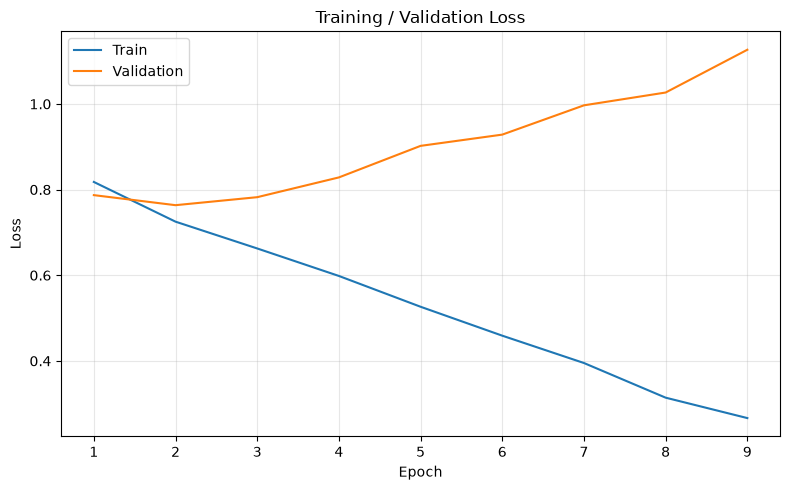

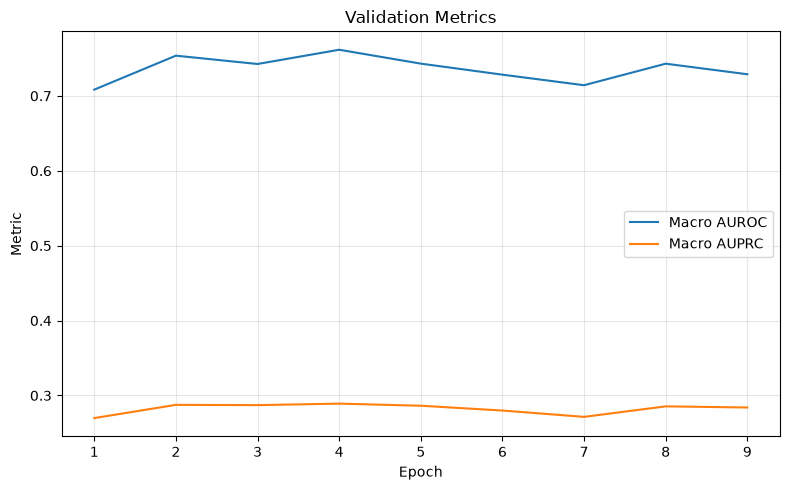


Loaded best checkpoint from epoch: 4
Best validation macro AUROC: 0.7615454401131664


Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]


VALIDATION THRESHOLD OPTIMIZATION
Atelectasis                    threshold=0.455 val_F1=0.536
Cardiomegaly                   threshold=0.385 val_F1=0.533
Consolidation                  threshold=0.595 val_F1=0.235
Edema                          threshold=0.635 val_F1=0.540
Enlarged Cardiomediastinum     threshold=0.485 val_F1=0.156
Fracture                       threshold=0.120 val_F1=0.118
Lung Lesion                    threshold=0.375 val_F1=0.120
Lung Opacity                   threshold=0.460 val_F1=0.480
Pleural Effusion               threshold=0.485 val_F1=0.629
Pleural Other                  threshold=0.260 val_F1=0.069
Pneumonia                      threshold=0.660 val_F1=0.277
Pneumothorax                   threshold=0.185 val_F1=0.254
Support Devices                threshold=0.390 val_F1=0.707

FINAL TEST EVALUATION


Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

Test loss: 0.82478
Test macro AUROC: 0.75371
Test macro AUPRC: 0.31379

                     label  AUROC  AUPRC  threshold  precision  sensitivity_recall  specificity     F1  TP  FP  TN  FN  n_valid
               Atelectasis 0.7899 0.4737      0.455     0.4151              0.6875       0.7350 0.5176 132 186 516  60      894
              Cardiomegaly 0.7849 0.4588      0.385     0.3526              0.7778       0.6416 0.4853 140 257 460  40      897
             Consolidation 0.7850 0.2762      0.595     0.1917              0.4600       0.8872 0.2706  23  97 763  27      910
                     Edema 0.8514 0.4586      0.635     0.3933              0.4917       0.8801 0.4370  59  91 668  61      879
Enlarged Cardiomediastinum 0.6709 0.0913      0.485     0.1176              0.0606       0.9824 0.0800   2  15 838  31      886
                  Fracture 0.6685 0.0717      0.120     0.0483              0.3500       0.8470 0.0848   7 138 764  13      922
               Lung Lesion 0.637

In [26]:
# ============================================================
# MIMIC-CXR MULTILABEL TRAINING — SINGLE NOTEBOOK CELL
# ============================================================
# Baseline:
# - AP + PA frontal X-rays only
# - 13 labels (No Finding excluded)
# - patient-level 70/15/15 split
# - NaN -> 0 (unmentioned treated as negative)
# - -1 -> ignored
# - DenseNet121, ImageNet pretrained
# - mixed precision
# - BCEWithLogitsLoss with masked uncertain labels
# - per-class AUROC / AUPRC
# - early stopping
# - threshold tuning on validation set
# - final untouched test evaluation
# - truncated JPEG handling
# - full image decode validation before split/training
# - saves checkpoint, splits, predictions, metrics, plots
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import gc
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import densenet121, DenseNet121_Weights

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


# ============================================================
# 0.1 PIL JPEG SAFETY
# ============================================================

# Allows slightly truncated JPEG files to load.
# Example fixed error:
# OSError: image file is truncated (14 bytes not processed)
ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 1. CONFIG
# ============================================================

INDEX_CSV = "/workspace/private/unzippedarchive/xray_image_label_index.csv"

OUTPUT_DIR = Path(
    "/workspace/private/unzippedarchive/xray_training_output"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SEED = 42

IMAGE_SIZE = 320

BATCH_SIZE = 24

NUM_WORKERS = 4

EPOCHS = 25

PATIENCE = 5

LR = 1e-4

WEIGHT_DECAY = 1e-4

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15

SEARCH_SPLITS = 1000

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Enlarged Cardiomediastinum",
    "Fracture",
    "Lung Lesion",
    "Lung Opacity",
    "Pleural Effusion",
    "Pleural Other",
    "Pneumonia",
    "Pneumothorax",
    "Support Devices",
]


print("=" * 80)
print("CONFIG")
print("=" * 80)

print("Device:", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2,
        ),
        "GB",
    )

print(
    "PyTorch:",
    torch.__version__,
)

print(
    "Torchvision:",
    torchvision.__version__,
)

print(
    "Image size:",
    IMAGE_SIZE,
)

print(
    "Batch size:",
    BATCH_SIZE,
)

print(
    "Workers:",
    NUM_WORKERS,
)

print()


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)

        torch.cuda.manual_seed_all(seed)

    # Faster convolution selection.
    torch.backends.cudnn.benchmark = True

    if hasattr(
        torch,
        "set_float32_matmul_precision",
    ):

        torch.set_float32_matmul_precision(
            "high"
        )


seed_everything(SEED)


# ============================================================
# 3. LOAD INDEX
# ============================================================

df = pd.read_csv(
    INDEX_CSV
)

print("=" * 80)
print("RAW INDEX")
print("=" * 80)

print(
    "Rows:",
    len(df),
)

print(
    "Patients:",
    df["subject_id"].nunique(),
)

print(
    "Studies:",
    df["study_id"].nunique(),
)

print(
    "DICOM IDs:",
    df["dicom_id"].nunique(),
)

print()


# ============================================================
# 4. BASIC INDEX VALIDATION
# ============================================================

required_cols = [
    "image_path",
    "dicom_id",
    "subject_id",
    "study_id",
    "ViewPosition",
] + LABELS

missing_cols = [
    c
    for c in required_cols
    if c not in df.columns
]

if missing_cols:

    raise RuntimeError(
        f"Missing required columns: {missing_cols}"
    )


# ----------------------------
# DICOM ID duplicate check
# ----------------------------

if df["dicom_id"].duplicated().any():

    dupes = df[
        df["dicom_id"].duplicated(
            keep=False
        )
    ]

    raise RuntimeError(
        "Duplicate dicom_id values exist "
        f"in index CSV: {len(dupes)} rows"
    )


# ============================================================
# 5. IMAGE VALIDATION
# ============================================================
#
# We do two checks:
#
# 1. File exists
# 2. PIL can fully decode it
#
# Slightly truncated JPEGs should load because
# LOAD_TRUNCATED_IMAGES=True.
#
# Images that still cannot decode are removed BEFORE
# patient splitting so all later counts remain consistent.
# ============================================================

print("=" * 80)
print("IMAGE VALIDATION")
print("=" * 80)

missing_files = []

bad_images = []

for p in tqdm(
    df["image_path"],
    desc="Validating JPEGs",
):

    # -------------------------------------
    # File existence
    # -------------------------------------

    if not os.path.exists(p):

        missing_files.append(
            p
        )

        continue

    # -------------------------------------
    # Full PIL decode
    # -------------------------------------

    try:

        with Image.open(p) as img:

            img.load()

    except Exception as e:

        bad_images.append(
            (
                p,
                repr(e),
            )
        )


print()

print(
    "Missing files:",
    len(missing_files),
)

print(
    "Unreadable files:",
    len(bad_images),
)


problem_paths = set(
    missing_files
)

problem_paths.update(
    p
    for p, _ in bad_images
)


if missing_files:

    print()
    print("Example missing files:")

    for p in missing_files[:10]:

        print(
            " -",
            p,
        )


if bad_images:

    print()
    print("Example unreadable files:")

    for p, error in bad_images[:20]:

        print(
            " -",
            p,
        )

        print(
            "   ",
            error,
        )


if problem_paths:

    original_count = len(df)

    df = df[
        ~df["image_path"].isin(
            problem_paths
        )
    ].copy()

    df.reset_index(
        drop=True,
        inplace=True,
    )

    removed = (
        original_count
        - len(df)
    )

    print()
    print(
        f"Removed {removed} unusable images."
    )

else:

    print(
        "All indexed images exist and decode successfully."
    )


print()

print(
    "Remaining dataset rows:",
    len(df),
)

print()


# ============================================================
# 6. FILTER TO FRONTAL IMAGES
# ============================================================

df = df[
    df["ViewPosition"].isin(
        [
            "AP",
            "PA",
        ]
    )
].copy()

df.reset_index(
    drop=True,
    inplace=True,
)


print("=" * 80)
print("FRONTAL DATASET")
print("=" * 80)

print(
    "Images:",
    len(df),
)

print(
    "Patients:",
    df["subject_id"].nunique(),
)

print(
    "Studies:",
    df["study_id"].nunique(),
)

print()

print(
    df["ViewPosition"].value_counts(
        dropna=False
    )
)

print()


if len(df) == 0:

    raise RuntimeError(
        "No AP/PA frontal images remain after filtering."
    )


# ============================================================
# 7. LABEL SANITY CHECK
# ============================================================

print("=" * 80)
print("LABEL DISTRIBUTION — FRONTAL ONLY")
print("=" * 80)

for label in LABELS:

    s = df[label]

    pos = int(
        (s == 1).sum()
    )

    neg = int(
        (s == 0).sum()
    )

    unc = int(
        (s == -1).sum()
    )

    missing = int(
        s.isna().sum()
    )

    print(
        f"{label:30s} "
        f"pos={pos:4d} "
        f"explicit_neg={neg:4d} "
        f"uncertain={unc:4d} "
        f"unmentioned={missing:4d}"
    )


# ============================================================
# 8. PATIENT-LEVEL SPLIT
# ============================================================
#
# Searches many random patient-level splits and chooses
# one whose per-label prevalence best resembles the full
# frontal dataset.
#
# No image-level random splitting is performed.
# ============================================================

patients = df[
    "subject_id"
].unique()

n_patients = len(
    patients
)

n_train = round(
    n_patients
    * TRAIN_FRACTION
)

n_val = round(
    n_patients
    * VAL_FRACTION
)


target_prevalence = {}


for label in LABELS:

    vals = df[
        label
    ].copy()

    # NaN = unmentioned -> negative
    vals = vals.fillna(
        0
    )

    # -1 = uncertain -> excluded
    valid = (
        vals != -1
    )

    if valid.sum() > 0:

        target_prevalence[
            label
        ] = float(
            (
                vals[
                    valid
                ] == 1
            ).mean()
        )

    else:

        target_prevalence[
            label
        ] = 0.0


def score_split(
    train_ids,
    val_ids,
    test_ids,
):

    score = 0.0

    for split_ids in [
        train_ids,
        val_ids,
        test_ids,
    ]:

        part = df[
            df["subject_id"].isin(
                split_ids
            )
        ]

        for label in LABELS:

            vals = part[
                label
            ].fillna(
                0
            )

            valid = (
                vals != -1
            )

            if valid.sum() == 0:

                score += 100.0

                continue

            pos_count = int(
                (
                    vals[
                        valid
                    ] == 1
                ).sum()
            )

            neg_count = int(
                (
                    vals[
                        valid
                    ] == 0
                ).sum()
            )

            prevalence = float(
                (
                    vals[
                        valid
                    ] == 1
                ).mean()
            )

            target = target_prevalence[
                label
            ]

            score += abs(
                prevalence
                - target
            )

            # --------------------------------
            # Penalize complete loss of class
            # --------------------------------

            if pos_count == 0:

                score += 10.0

            if neg_count == 0:

                score += 10.0

    return score


best_score = float(
    "inf"
)

best_split = None

rng = np.random.default_rng(
    SEED
)


print()

print(
    "Searching for balanced patient-level split..."
)


for _ in tqdm(
    range(
        SEARCH_SPLITS
    )
):

    shuffled = rng.permutation(
        patients
    )

    train_ids = shuffled[
        :n_train
    ]

    val_ids = shuffled[
        n_train:
        n_train + n_val
    ]

    test_ids = shuffled[
        n_train + n_val:
    ]

    score = score_split(
        train_ids,
        val_ids,
        test_ids,
    )

    if score < best_score:

        best_score = score

        best_split = (
            set(
                train_ids
            ),
            set(
                val_ids
            ),
            set(
                test_ids
            ),
        )


if best_split is None:

    raise RuntimeError(
        "Could not construct patient-level split."
    )


train_ids, val_ids, test_ids = (
    best_split
)


train_df = df[
    df["subject_id"].isin(
        train_ids
    )
].copy()

val_df = df[
    df["subject_id"].isin(
        val_ids
    )
].copy()

test_df = df[
    df["subject_id"].isin(
        test_ids
    )
].copy()


# ============================================================
# 9. LEAKAGE ASSERTIONS
# ============================================================

assert train_ids.isdisjoint(
    val_ids
)

assert train_ids.isdisjoint(
    test_ids
)

assert val_ids.isdisjoint(
    test_ids
)


assert set(
    train_df["dicom_id"]
).isdisjoint(
    set(
        val_df["dicom_id"]
    )
)

assert set(
    train_df["dicom_id"]
).isdisjoint(
    set(
        test_df["dicom_id"]
    )
)

assert set(
    val_df["dicom_id"]
).isdisjoint(
    set(
        test_df["dicom_id"]
    )
)


print()

print("=" * 80)
print("PATIENT SPLIT")
print("=" * 80)


for name, part in [
    (
        "TRAIN",
        train_df,
    ),
    (
        "VAL",
        val_df,
    ),
    (
        "TEST",
        test_df,
    ),
]:

    print(
        f"{name:6s} "
        f"images={len(part):5d} "
        f"patients="
        f"{part['subject_id'].nunique():4d} "
        f"studies="
        f"{part['study_id'].nunique():4d}"
    )


print()

print(
    "Patient leakage check: PASSED"
)


# ============================================================
# 10. SAVE SPLITS
# ============================================================

train_df[
    "split"
] = "train"

val_df[
    "split"
] = "val"

test_df[
    "split"
] = "test"


split_df = pd.concat(
    [
        train_df,
        val_df,
        test_df,
    ],
    ignore_index=True,
)


split_csv_path = (
    OUTPUT_DIR
    / "patient_level_splits.csv"
)

split_df.to_csv(
    split_csv_path,
    index=False,
)


print(
    "Saved:",
    split_csv_path,
)


# ============================================================
# 11. PRINT SPLIT LABEL COUNTS
# ============================================================

print()

print("=" * 80)
print("LABEL COUNTS PER SPLIT")
print("=" * 80)


for label in LABELS:

    row = []

    for name, part in [
        (
            "train",
            train_df,
        ),
        (
            "val",
            val_df,
        ),
        (
            "test",
            test_df,
        ),
    ]:

        vals = part[
            label
        ].fillna(
            0
        )

        pos = int(
            (
                vals == 1
            ).sum()
        )

        neg = int(
            (
                vals == 0
            ).sum()
        )

        unc = int(
            (
                vals == -1
            ).sum()
        )

        row.append(
            f"{name}: "
            f"+{pos}/"
            f"-{neg}/"
            f"u{unc}"
        )

    print(
        f"{label:30s} "
        f"{' | '.join(row)}"
    )


# ============================================================
# 12. TRANSFORMS
# ============================================================

train_transform = transforms.Compose(
    [
        transforms.Resize(
            (
                IMAGE_SIZE,
                IMAGE_SIZE,
            ),
            interpolation=(
                transforms
                .InterpolationMode
                .BILINEAR
            ),
        ),

        transforms.RandomAffine(
            degrees=5,
            translate=(
                0.02,
                0.02,
            ),
            scale=(
                0.95,
                1.05,
            ),
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[
                0.485,
                0.456,
                0.406,
            ],
            std=[
                0.229,
                0.224,
                0.225,
            ],
        ),
    ]
)


eval_transform = transforms.Compose(
    [
        transforms.Resize(
            (
                IMAGE_SIZE,
                IMAGE_SIZE,
            ),
            interpolation=(
                transforms
                .InterpolationMode
                .BILINEAR
            ),
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[
                0.485,
                0.456,
                0.406,
            ],
            std=[
                0.229,
                0.224,
                0.225,
            ],
        ),
    ]
)


# ============================================================
# 13. DATASET CLASS
# ============================================================

class XRayDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform=None,
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx,
    ):

        row = self.df.iloc[
            idx
        ]

        path = row[
            "image_path"
        ]

        # -------------------------------------
        # Safe PIL load
        # -------------------------------------

        try:

            with Image.open(
                path
            ) as im:

                img = im.convert(
                    "RGB"
                )

        except Exception as e:

            raise RuntimeError(
                "Failed to load image:\n"
                f"{path}\n"
                f"Error: {repr(e)}"
            ) from e


        if self.transform is not None:

            img = self.transform(
                img
            )


        raw_labels = row[
            LABELS
        ].values.astype(
            np.float32
        )


        # -------------------------------------
        # LABEL POLICY
        #
        #  1   -> positive
        #  0   -> negative
        #  NaN -> negative / unmentioned
        # -1   -> ignored using mask
        # -------------------------------------

        uncertain_mask = (
            raw_labels
            == -1
        )


        labels = np.nan_to_num(
            raw_labels,
            nan=0.0,
        )


        labels[
            uncertain_mask
        ] = 0.0


        mask = (
            ~uncertain_mask
        ).astype(
            np.float32
        )


        return (
            img,
            torch.tensor(
                labels,
                dtype=torch.float32,
            ),
            torch.tensor(
                mask,
                dtype=torch.float32,
            ),
            row[
                "dicom_id"
            ],
        )


# ============================================================
# 14. DATA LOADERS
# ============================================================

train_dataset = XRayDataset(
    train_df,
    transform=train_transform,
)

val_dataset = XRayDataset(
    val_df,
    transform=eval_transform,
)

test_dataset = XRayDataset(
    test_df,
    transform=eval_transform,
)


loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(
        NUM_WORKERS
        > 0
    ),
)


train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=False,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)


print()

print(
    "Train batches:",
    len(
        train_loader
    ),
)

print(
    "Val batches:",
    len(
        val_loader
    ),
)

print(
    "Test batches:",
    len(
        test_loader
    ),
)


# ============================================================
# 15. CLASS WEIGHTS
# ============================================================

pos_weights = []


for label in LABELS:

    vals = train_df[
        label
    ].fillna(
        0
    )

    vals = vals[
        vals != -1
    ]

    pos = int(
        (
            vals == 1
        ).sum()
    )

    neg = int(
        (
            vals == 0
        ).sum()
    )


    if pos == 0:

        weight = 1.0

    else:

        weight = (
            neg / pos
        )


    # Prevent extreme rare-class weighting
    weight = np.clip(
        weight,
        1.0,
        10.0,
    )


    pos_weights.append(
        weight
    )


    print(
        f"{label:30s} "
        f"train pos={pos:4d} "
        f"neg={neg:4d} "
        f"pos_weight="
        f"{weight:.3f}"
    )


pos_weights = torch.tensor(
    pos_weights,
    dtype=torch.float32,
    device=DEVICE,
)


# ============================================================
# 16. MODEL
# ============================================================

weights = (
    DenseNet121_Weights
    .IMAGENET1K_V1
)


model = densenet121(
    weights=weights
)


in_features = (
    model
    .classifier
    .in_features
)


model.classifier = nn.Linear(
    in_features,
    len(
        LABELS
    ),
)


model = model.to(
    DEVICE
)


print()

print("=" * 80)
print("MODEL")
print("=" * 80)

print(
    model.__class__.__name__
)

print(
    "Output classes:",
    len(
        LABELS
    ),
)


# ============================================================
# 17. LOSS
# ============================================================

criterion = nn.BCEWithLogitsLoss(
    reduction="none",
    pos_weight=pos_weights,
)


def masked_bce_loss(
    logits,
    targets,
    mask,
):

    raw_loss = criterion(
        logits,
        targets,
    )

    masked_loss = (
        raw_loss
        * mask
    )

    denom = mask.sum().clamp(
        min=1.0
    )

    return (
        masked_loss.sum()
        / denom
    )


# ============================================================
# 18. OPTIMIZER + SCHEDULER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)


scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
    )
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(
        torch.cuda.is_available()
    ),
)


# ============================================================
# 19. METRIC FUNCTIONS
# ============================================================

def calculate_metrics(
    targets,
    probs,
    masks,
):

    results = {}

    aurocs = []

    auprcs = []


    for i, label in enumerate(
        LABELS
    ):

        valid = (
            masks[
                :,
                i
            ]
            == 1
        )


        y_true = targets[
            valid,
            i
        ]


        y_prob = probs[
            valid,
            i
        ]


        if len(
            np.unique(
                y_true
            )
        ) < 2:

            auc = np.nan

            ap = np.nan

        else:

            auc = roc_auc_score(
                y_true,
                y_prob,
            )

            ap = average_precision_score(
                y_true,
                y_prob,
            )


        results[
            label
        ] = {
            "AUROC": auc,
            "AUPRC": ap,
        }


        if not np.isnan(
            auc
        ):

            aurocs.append(
                auc
            )


        if not np.isnan(
            ap
        ):

            auprcs.append(
                ap
            )


    results[
        "macro_AUROC"
    ] = (
        float(
            np.mean(
                aurocs
            )
        )
        if aurocs
        else np.nan
    )


    results[
        "macro_AUPRC"
    ] = (
        float(
            np.mean(
                auprcs
            )
        )
        if auprcs
        else np.nan
    )


    return results


# ============================================================
# 20. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
):

    model.train()

    running_loss = 0.0

    samples = 0


    progress = tqdm(
        loader,
        desc="Training",
        leave=False,
    )


    for (
        images,
        targets,
        masks,
        _,
    ) in progress:


        images = images.to(
            DEVICE,
            non_blocking=True,
        )


        targets = targets.to(
            DEVICE,
            non_blocking=True,
        )


        masks = masks.to(
            DEVICE,
            non_blocking=True,
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.autocast(
            device_type=(
                DEVICE.type
            ),
            dtype=torch.float16,
            enabled=(
                torch.cuda.is_available()
            ),
        ):

            logits = model(
                images
            )

            loss = masked_bce_loss(
                logits,
                targets,
                masks,
            )


        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )


        scaler.step(
            optimizer
        )

        scaler.update()


        bs = images.size(
            0
        )


        running_loss += (
            loss.item()
            * bs
        )

        samples += bs


        progress.set_postfix(
            loss=(
                f"{loss.item():.4f}"
            ),
            lr=(
                f"{optimizer.param_groups[0]['lr']:.2e}"
            ),
        )


    return (
        running_loss
        / max(
            samples,
            1,
        )
    )


# ============================================================
# 21. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(
    model,
    loader,
):

    model.eval()

    running_loss = 0.0

    samples = 0

    all_targets = []

    all_probs = []

    all_masks = []

    all_ids = []


    progress = tqdm(
        loader,
        desc="Evaluating",
        leave=False,
    )


    for (
        images,
        targets,
        masks,
        dicom_ids,
    ) in progress:


        images = images.to(
            DEVICE,
            non_blocking=True,
        )


        targets = targets.to(
            DEVICE,
            non_blocking=True,
        )


        masks = masks.to(
            DEVICE,
            non_blocking=True,
        )


        with torch.autocast(
            device_type=(
                DEVICE.type
            ),
            dtype=torch.float16,
            enabled=(
                torch.cuda.is_available()
            ),
        ):

            logits = model(
                images
            )

            loss = masked_bce_loss(
                logits,
                targets,
                masks,
            )


        probs = torch.sigmoid(
            logits
        )


        bs = images.size(
            0
        )


        running_loss += (
            loss.item()
            * bs
        )

        samples += bs


        all_targets.append(
            targets
            .detach()
            .cpu()
            .numpy()
        )


        all_probs.append(
            probs
            .detach()
            .cpu()
            .numpy()
        )


        all_masks.append(
            masks
            .detach()
            .cpu()
            .numpy()
        )


        all_ids.extend(
            list(
                dicom_ids
            )
        )


    targets = np.concatenate(
        all_targets,
        axis=0,
    )


    probs = np.concatenate(
        all_probs,
        axis=0,
    )


    masks = np.concatenate(
        all_masks,
        axis=0,
    )


    metrics = calculate_metrics(
        targets,
        probs,
        masks,
    )


    return (
        running_loss
        / max(
            samples,
            1,
        ),
        metrics,
        targets,
        probs,
        masks,
        all_ids,
    )


# ============================================================
# 22. TRAINING LOOP
# ============================================================

history = []

best_metric = -np.inf

epochs_without_improvement = 0

best_checkpoint = (
    OUTPUT_DIR
    / "best_model.pt"
)


print()

print("=" * 80)
print("TRAINING")
print("=" * 80)


for epoch in range(
    1,
    EPOCHS + 1,
):


    print()

    print(
        f"Epoch {epoch}/{EPOCHS}"
    )

    print(
        "-" * 80
    )


    train_loss = train_one_epoch(
        model,
        train_loader,
    )


    (
        val_loss,
        val_metrics,
        _,
        _,
        _,
        _,
    ) = evaluate(
        model,
        val_loader,
    )


    macro_auc = val_metrics[
        "macro_AUROC"
    ]

    macro_ap = val_metrics[
        "macro_AUPRC"
    ]


    scheduler.step(
        macro_auc
    )


    current_lr = optimizer.param_groups[
        0
    ][
        "lr"
    ]


    print(
        f"Train loss : "
        f"{train_loss:.5f}"
    )

    print(
        f"Val loss   : "
        f"{val_loss:.5f}"
    )

    print(
        f"Macro AUROC: "
        f"{macro_auc:.5f}"
    )

    print(
        f"Macro AUPRC: "
        f"{macro_ap:.5f}"
    )

    print(
        f"LR         : "
        f"{current_lr:.2e}"
    )


    history.append(
        {
            "epoch": epoch,
            "train_loss": (
                train_loss
            ),
            "val_loss": (
                val_loss
            ),
            "macro_AUROC": (
                macro_auc
            ),
            "macro_AUPRC": (
                macro_ap
            ),
            "lr": (
                current_lr
            ),
        }
    )


    # -----------------------------------------
    # Save best validation AUROC checkpoint
    # -----------------------------------------

    if macro_auc > best_metric:

        best_metric = (
            macro_auc
        )

        epochs_without_improvement = 0


        torch.save(
            {
                "epoch": (
                    epoch
                ),
                "model_state_dict": (
                    model.state_dict()
                ),
                "optimizer_state_dict": (
                    optimizer.state_dict()
                ),
                "macro_AUROC": (
                    macro_auc
                ),
                "macro_AUPRC": (
                    macro_ap
                ),
                "labels": (
                    LABELS
                ),
                "image_size": (
                    IMAGE_SIZE
                ),
            },
            best_checkpoint,
        )


        print(
            "✓ Saved new best model: "
            f"{macro_auc:.5f}"
        )


    else:

        epochs_without_improvement += 1


        print(
            "No improvement "
            f"({epochs_without_improvement}/"
            f"{PATIENCE})"
        )


        if (
            epochs_without_improvement
            >= PATIENCE
        ):

            print()

            print(
                "Early stopping triggered."
            )

            break


# ============================================================
# 23. SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)


history_path = (
    OUTPUT_DIR
    / "training_history.csv"
)


history_df.to_csv(
    history_path,
    index=False,
)


# ============================================================
# 24. TRAINING CURVES
# ============================================================

plt.figure(
    figsize=(
        8,
        5,
    )
)

plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "train_loss"
    ],
    label="Train",
)

plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "val_loss"
    ],
    label="Validation",
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Training / Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "loss_curve.png",
    dpi=150,
)


plt.show()


plt.figure(
    figsize=(
        8,
        5,
    )
)

plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "macro_AUROC"
    ],
    label="Macro AUROC",
)

plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "macro_AUPRC"
    ],
    label="Macro AUPRC",
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Metric"
)

plt.title(
    "Validation Metrics"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "validation_metrics.png",
    dpi=150,
)


plt.show()


# ============================================================
# 25. LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(
    best_checkpoint,
    map_location=DEVICE,
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


print()

print(
    "Loaded best checkpoint from epoch:",
    checkpoint[
        "epoch"
    ],
)


print(
    "Best validation macro AUROC:",
    checkpoint[
        "macro_AUROC"
    ],
)


# ============================================================
# 26. RUN VALIDATION AGAIN
# ============================================================

(
    val_loss,
    val_metrics,
    val_targets,
    val_probs,
    val_masks,
    val_ids,
) = evaluate(
    model,
    val_loader,
)


# ============================================================
# 27. OPTIMIZE THRESHOLDS ON VALIDATION SET
# ============================================================

thresholds = {}


print()

print("=" * 80)
print("VALIDATION THRESHOLD OPTIMIZATION")
print("=" * 80)


for i, label in enumerate(
    LABELS
):


    valid = (
        val_masks[
            :,
            i
        ]
        == 1
    )


    y_true = val_targets[
        valid,
        i
    ]


    y_prob = val_probs[
        valid,
        i
    ]


    if len(
        np.unique(
            y_true
        )
    ) < 2:

        threshold = 0.5

        best_f1 = np.nan


    else:

        best_f1 = -1.0

        threshold = 0.5


        for t in np.linspace(
            0.05,
            0.95,
            181,
        ):


            pred = (
                y_prob
                >= t
            ).astype(
                int
            )


            score = f1_score(
                y_true,
                pred,
                zero_division=0,
            )


            if score > best_f1:

                best_f1 = (
                    score
                )

                threshold = float(
                    t
                )


    thresholds[
        label
    ] = threshold


    print(
        f"{label:30s} "
        f"threshold="
        f"{threshold:.3f} "
        f"val_F1="
        f"{best_f1:.3f}"
    )


with open(
    OUTPUT_DIR
    / "thresholds.json",
    "w",
) as f:

    json.dump(
        thresholds,
        f,
        indent=2,
    )


# ============================================================
# 28. FINAL TEST
# ============================================================

print()

print("=" * 80)
print("FINAL TEST EVALUATION")
print("=" * 80)


(
    test_loss,
    test_metrics,
    test_targets,
    test_probs,
    test_masks,
    test_ids,
) = evaluate(
    model,
    test_loader,
)


print(
    "Test loss:",
    round(
        test_loss,
        5,
    ),
)


print(
    "Test macro AUROC:",
    round(
        test_metrics[
            "macro_AUROC"
        ],
        5,
    ),
)


print(
    "Test macro AUPRC:",
    round(
        test_metrics[
            "macro_AUPRC"
        ],
        5,
    ),
)


# ============================================================
# 29. PER-CLASS FINAL METRICS
# ============================================================

metric_rows = []


for i, label in enumerate(
    LABELS
):


    valid = (
        test_masks[
            :,
            i
        ]
        == 1
    )


    y_true = test_targets[
        valid,
        i
    ]


    y_prob = test_probs[
        valid,
        i
    ]


    threshold = thresholds[
        label
    ]


    y_pred = (
        y_prob
        >= threshold
    ).astype(
        int
    )


    if len(
        np.unique(
            y_true
        )
    ) >= 2:

        auc = roc_auc_score(
            y_true,
            y_prob,
        )

        ap = average_precision_score(
            y_true,
            y_prob,
        )

    else:

        auc = np.nan

        ap = np.nan


    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0,
    )


    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0,
    )


    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0,
    )


    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[
            0,
            1,
        ],
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    specificity = (
        tn
        / (
            tn
            + fp
        )
        if (
            tn
            + fp
        ) > 0
        else np.nan
    )


    metric_rows.append(
        {
            "label": (
                label
            ),
            "AUROC": (
                auc
            ),
            "AUPRC": (
                ap
            ),
            "threshold": (
                threshold
            ),
            "precision": (
                precision
            ),
            "sensitivity_recall": (
                recall
            ),
            "specificity": (
                specificity
            ),
            "F1": (
                f1
            ),
            "TP": (
                int(
                    tp
                )
            ),
            "FP": (
                int(
                    fp
                )
            ),
            "TN": (
                int(
                    tn
                )
            ),
            "FN": (
                int(
                    fn
                )
            ),
            "n_valid": (
                len(
                    y_true
                )
            ),
        }
    )


metrics_df = pd.DataFrame(
    metric_rows
)


metrics_df.to_csv(
    OUTPUT_DIR
    / "test_metrics.csv",
    index=False,
)


print()

print(
    metrics_df
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ============================================================
# 30. SAVE TEST PREDICTIONS
# ============================================================

pred_df = pd.DataFrame(
    {
        "dicom_id": (
            test_ids
        )
    }
)


for i, label in enumerate(
    LABELS
):


    pred_df[
        f"{label}_prob"
    ] = (
        test_probs[
            :,
            i
        ]
    )


    pred_df[
        f"{label}_target"
    ] = (
        test_targets[
            :,
            i
        ]
    )


    pred_df[
        f"{label}_mask"
    ] = (
        test_masks[
            :,
            i
        ]
    )


    pred_df[
        f"{label}_prediction"
    ] = (
        test_probs[
            :,
            i
        ]
        >= thresholds[
            label
        ]
    ).astype(
        int
    )


pred_df.to_csv(
    OUTPUT_DIR
    / "test_predictions.csv",
    index=False,
)


# ============================================================
# 31. SAVE SUMMARY
# ============================================================

summary = {

    "index_csv": (
        INDEX_CSV
    ),

    "image_size": (
        IMAGE_SIZE
    ),

    "batch_size": (
        BATCH_SIZE
    ),

    "num_workers": (
        NUM_WORKERS
    ),

    "epochs_requested": (
        EPOCHS
    ),

    "epochs_completed": (
        len(
            history_df
        )
    ),

    "best_epoch": (
        int(
            checkpoint[
                "epoch"
            ]
        )
    ),

    "best_validation_macro_AUROC": (
        float(
            checkpoint[
                "macro_AUROC"
            ]
        )
    ),

    "test_macro_AUROC": (
        float(
            test_metrics[
                "macro_AUROC"
            ]
        )
    ),

    "test_macro_AUPRC": (
        float(
            test_metrics[
                "macro_AUPRC"
            ]
        )
    ),

    "train_images": (
        len(
            train_df
        )
    ),

    "val_images": (
        len(
            val_df
        )
    ),

    "test_images": (
        len(
            test_df
        )
    ),

    "train_patients": (
        int(
            train_df[
                "subject_id"
            ].nunique()
        )
    ),

    "val_patients": (
        int(
            val_df[
                "subject_id"
            ].nunique()
        )
    ),

    "test_patients": (
        int(
            test_df[
                "subject_id"
            ].nunique()
        )
    ),

    "removed_missing_or_bad_images": (
        int(
            len(
                problem_paths
            )
        )
    ),

    "labels": (
        LABELS
    ),

}


with open(
    OUTPUT_DIR
    / "summary.json",
    "w",
) as f:

    json.dump(
        summary,
        f,
        indent=2,
    )


# ============================================================
# 32. FINAL OUTPUT
# ============================================================

print()

print("=" * 80)
print("DONE")
print("=" * 80)


print(
    "Outputs saved to:"
)

print(
    OUTPUT_DIR
)

print()

print(
    "Files:"
)


for p in sorted(
    OUTPUT_DIR.iterdir()
):

    print(
        " -",
        p.name,
    )


print()

print(
    "Best epoch:",
    checkpoint[
        "epoch"
    ],
)


print(
    "Validation macro AUROC:",
    round(
        checkpoint[
            "macro_AUROC"
        ],
        4,
    ),
)


print(
    "Test macro AUROC:",
    round(
        test_metrics[
            "macro_AUROC"
        ],
        4,
    ),
)


print(
    "Test macro AUPRC:",
    round(
        test_metrics[
            "macro_AUPRC"
        ],
        4,
    ),
)


print()

print(
    "Removed missing/unreadable images:",
    len(
        problem_paths
    ),
)


# ============================================================
# 33. CLEANUP
# ============================================================

gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()

EXPERIMENT 2 CONFIG
Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM: 15.47 GB
PyTorch: 2.14.0+cu130
Torchvision: 0.29.0+cu130
Image size: 320
Batch size: 24
Workers: 4
Learning rate: 3e-05
Weight decay: 0.001
Dropout: 0.3
Positive weight cap: 5.0
Early stopping patience: 4
Checkpoint metric: Macro AUPRC
RUN_TEST: False

RAW INDEX
Rows: 10451
Patients: 1804
Studies: 6368
DICOM IDs: 10451

IMAGE VALIDATION


Validating JPEGs:   0%|          | 0/10451 [00:00<?, ?it/s]


Missing files: 0
Unreadable files: 0
All indexed images decode successfully.
Remaining rows: 10451

FRONTAL DATASET
Images: 6723
Patients: 1759
Studies: 6078

ViewPosition
AP    4104
PA    2619
Name: count, dtype: int64

LABEL DISTRIBUTION — FRONTAL ONLY
Atelectasis                    pos=1377 explicit_neg=  30 uncertain= 286 unmentioned=5030
Cardiomegaly                   pos=1351 explicit_neg= 430 uncertain= 191 unmentioned=4751
Consolidation                  pos= 342 explicit_neg= 211 uncertain= 120 unmentioned=6050
Edema                          pos= 777 explicit_neg= 692 uncertain= 366 unmentioned=4888
Enlarged Cardiomediastinum     pos= 211 explicit_neg= 153 uncertain= 299 unmentioned=6060
Fracture                       pos= 170 explicit_neg=  26 uncertain=  14 unmentioned=6513
Lung Lesion                    pos= 179 explicit_neg=  23 uncertain=  25 unmentioned=6496
Lung Opacity                   pos=1513 explicit_neg=  78 uncertain= 117 unmentioned=5015
Pleural Effusion        

Training:   0%|          | 0/202 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

Train loss : 0.39477
Val loss   : 0.70724
Macro AUROC: 0.71222
Macro AUPRC: 0.27401
LR         : 1.50e-05
No AUPRC improvement (3/4)

Epoch 12/25
--------------------------------------------------------------------------------


Training:   0%|          | 0/202 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

Train loss : 0.36071
Val loss   : 0.69987
Macro AUROC: 0.71834
Macro AUPRC: 0.27910
LR         : 1.50e-05
No AUPRC improvement (4/4)

Early stopping triggered.


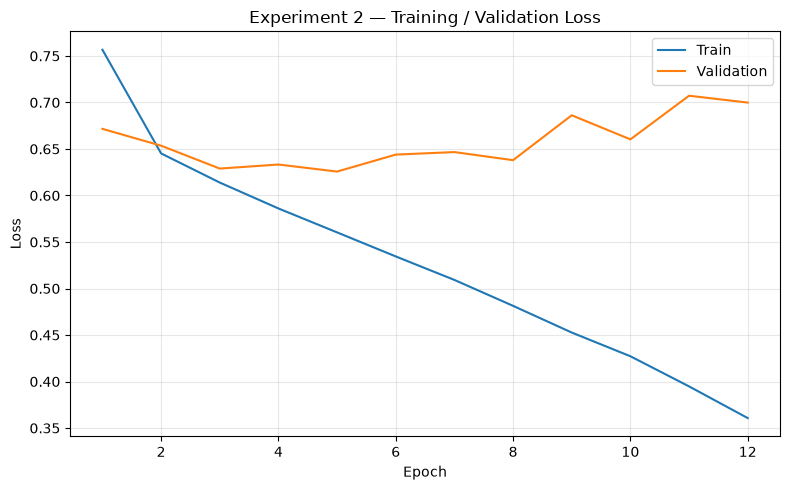

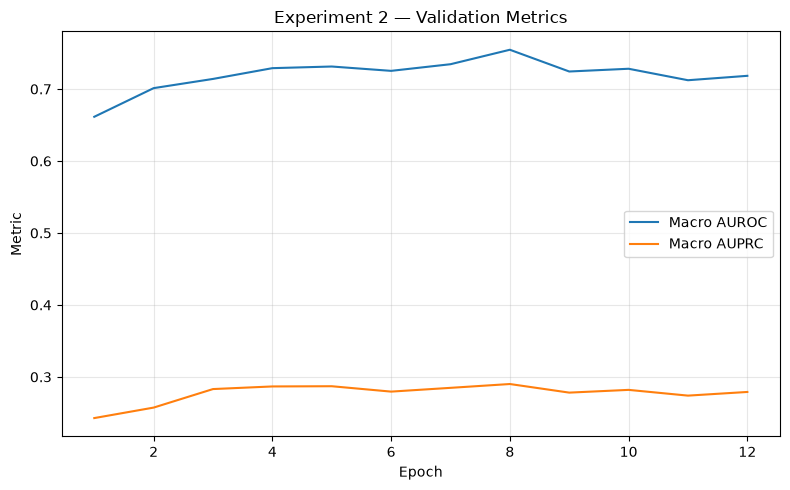


BEST CHECKPOINT
Best epoch: 8
Best validation macro AUPRC: 0.29012354562630044
Corresponding macro AUROC: 0.7545719293527688


Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]


BEST MODEL VALIDATION PERFORMANCE
Validation loss: 0.63796
Validation macro AUROC: 0.75457
Validation macro AUPRC: 0.29012

                     label  AUROC  AUPRC  positives  negatives  n_valid
               Atelectasis 0.7722 0.4150        193        721      914
              Cardiomegaly 0.7764 0.4549        216        733      949
             Consolidation 0.7357 0.1431         52        899      951
                     Edema 0.8857 0.4800        127        798      925
Enlarged Cardiomediastinum 0.6936 0.1298         31        901      932
                  Fracture 0.6184 0.0782         30        939      969
               Lung Lesion 0.6604 0.0315         21        948      969
              Lung Opacity 0.7167 0.3825        211        742      953
          Pleural Effusion 0.8517 0.6015        226        726      952
             Pleural Other 0.8225 0.0199          4        965      969
                 Pneumonia 0.6924 0.1949         69        814      883
           

In [27]:
# ============================================================
# MIMIC-CXR MULTILABEL TRAINING — EXPERIMENT 2
# SINGLE NOTEBOOK CELL
# ============================================================
#
# EXPERIMENT 2 CHANGES
# ------------------------------------------------------------
# - SAME exact patient split as Experiment 1
# - AP + PA frontal X-rays only
# - 13 labels (No Finding excluded)
#
# Label policy:
#     1   -> positive
#     0   -> negative
#     NaN -> negative / unmentioned
#    -1   -> ignored
#
# Model:
# - DenseNet121
# - ImageNet pretrained
# - Dropout 0.30 before classifier
#
# Training:
# - image size 320
# - aspect-ratio-preserving resize + padding
# - LR 3e-5
# - weight decay 1e-3
# - pos_weight cap 5
# - mixed precision
# - early stopping patience 4
#
# Model selection:
# - BEST VALIDATION MACRO AUPRC
#
# Important:
# - RUN_TEST=False by default to avoid repeatedly inspecting
#   the same test set during model development.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import gc
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile, ImageOps

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import (
    densenet121,
    DenseNet121_Weights,
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


# ============================================================
# 0.1 PIL JPEG SAFETY
# ============================================================

ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 1. CONFIG
# ============================================================

INDEX_CSV = (
    "/workspace/private/unzippedarchive/"
    "xray_image_label_index.csv"
)

# ------------------------------------------------------------
# IMPORTANT:
# Experiment 1 split file
# ------------------------------------------------------------

EXPERIMENT_1_SPLIT_CSV = (
    "/workspace/private/unzippedarchive/"
    "xray_training_output/"
    "patient_level_splits.csv"
)

# ------------------------------------------------------------
# Separate output folder so Experiment 1 is untouched
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/workspace/private/unzippedarchive/"
    "xray_training_experiment_2"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


SEED = 42

IMAGE_SIZE = 320

BATCH_SIZE = 24

NUM_WORKERS = 4

EPOCHS = 25

PATIENCE = 4

LR = 3e-5

WEIGHT_DECAY = 1e-3

DROPOUT = 0.30

POS_WEIGHT_CAP = 5.0


# ------------------------------------------------------------
# Leave False while comparing experiments.
#
# When you're satisfied with the final configuration,
# change to True and evaluate the held-out test split.
# ------------------------------------------------------------

RUN_TEST = False


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Enlarged Cardiomediastinum",
    "Fracture",
    "Lung Lesion",
    "Lung Opacity",
    "Pleural Effusion",
    "Pleural Other",
    "Pneumonia",
    "Pneumothorax",
    "Support Devices",
]


print("=" * 80)
print("EXPERIMENT 2 CONFIG")
print("=" * 80)

print("Device:", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(
                0
            ).total_memory
            / 1024**3,
            2,
        ),
        "GB",
    )


print("PyTorch:", torch.__version__)

print(
    "Torchvision:",
    torchvision.__version__,
)

print("Image size:", IMAGE_SIZE)

print("Batch size:", BATCH_SIZE)

print("Workers:", NUM_WORKERS)

print("Learning rate:", LR)

print(
    "Weight decay:",
    WEIGHT_DECAY,
)

print("Dropout:", DROPOUT)

print(
    "Positive weight cap:",
    POS_WEIGHT_CAP,
)

print(
    "Early stopping patience:",
    PATIENCE,
)

print(
    "Checkpoint metric: Macro AUPRC"
)

print("RUN_TEST:", RUN_TEST)

print()


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def seed_everything(
    seed=42,
):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(
            seed
        )

        torch.cuda.manual_seed_all(
            seed
        )

    # Good speed for fixed-size tensors
    torch.backends.cudnn.benchmark = True

    if hasattr(
        torch,
        "set_float32_matmul_precision",
    ):

        torch.set_float32_matmul_precision(
            "high"
        )


seed_everything(SEED)


# ============================================================
# 3. LOAD INDEX
# ============================================================

df = pd.read_csv(
    INDEX_CSV
)


print("=" * 80)
print("RAW INDEX")
print("=" * 80)

print("Rows:", len(df))

print(
    "Patients:",
    df["subject_id"].nunique(),
)

print(
    "Studies:",
    df["study_id"].nunique(),
)

print(
    "DICOM IDs:",
    df["dicom_id"].nunique(),
)

print()


# ============================================================
# 4. VALIDATE REQUIRED COLUMNS
# ============================================================

required_cols = [
    "image_path",
    "dicom_id",
    "subject_id",
    "study_id",
    "ViewPosition",
] + LABELS


missing_cols = [
    c
    for c in required_cols
    if c not in df.columns
]


if missing_cols:

    raise RuntimeError(
        "Missing required columns: "
        f"{missing_cols}"
    )


if df[
    "dicom_id"
].duplicated().any():

    dupes = df[
        df[
            "dicom_id"
        ].duplicated(
            keep=False
        )
    ]

    raise RuntimeError(
        "Duplicate DICOM IDs found "
        f"in index CSV: {len(dupes)} rows"
    )


# ============================================================
# 5. IMAGE VALIDATION
# ============================================================

print("=" * 80)
print("IMAGE VALIDATION")
print("=" * 80)


missing_files = []

bad_images = []


for p in tqdm(
    df["image_path"],
    desc="Validating JPEGs",
):

    if not os.path.exists(
        p
    ):

        missing_files.append(
            p
        )

        continue


    try:

        with Image.open(
            p
        ) as img:

            img.load()

    except Exception as e:

        bad_images.append(
            (
                p,
                repr(e),
            )
        )


problem_paths = set(
    missing_files
)

problem_paths.update(
    p
    for p, _ in bad_images
)


print()

print(
    "Missing files:",
    len(missing_files),
)

print(
    "Unreadable files:",
    len(bad_images),
)


if bad_images:

    print()

    print(
        "Example unreadable images:"
    )

    for p, error in bad_images[:10]:

        print(p)

        print(
            "    ",
            error,
        )


if problem_paths:

    original_count = len(
        df
    )

    df = df[
        ~df[
            "image_path"
        ].isin(
            problem_paths
        )
    ].copy()

    df.reset_index(
        drop=True,
        inplace=True,
    )

    print(
        "Removed unusable images:",
        original_count
        - len(df),
    )

else:

    print(
        "All indexed images decode successfully."
    )


print(
    "Remaining rows:",
    len(df),
)

print()


# ============================================================
# 6. FILTER FRONTAL AP + PA
# ============================================================

df = df[
    df[
        "ViewPosition"
    ].isin(
        [
            "AP",
            "PA",
        ]
    )
].copy()


df.reset_index(
    drop=True,
    inplace=True,
)


print("=" * 80)
print("FRONTAL DATASET")
print("=" * 80)

print(
    "Images:",
    len(df),
)

print(
    "Patients:",
    df[
        "subject_id"
    ].nunique(),
)

print(
    "Studies:",
    df[
        "study_id"
    ].nunique(),
)

print()

print(
    df[
        "ViewPosition"
    ].value_counts()
)

print()


# ============================================================
# 7. LABEL DISTRIBUTION
# ============================================================

print("=" * 80)
print("LABEL DISTRIBUTION — FRONTAL ONLY")
print("=" * 80)


for label in LABELS:

    s = df[
        label
    ]

    pos = int(
        (
            s == 1
        ).sum()
    )

    neg = int(
        (
            s == 0
        ).sum()
    )

    unc = int(
        (
            s == -1
        ).sum()
    )

    missing = int(
        s.isna().sum()
    )

    print(
        f"{label:30s} "
        f"pos={pos:4d} "
        f"explicit_neg={neg:4d} "
        f"uncertain={unc:4d} "
        f"unmentioned={missing:4d}"
    )


# ============================================================
# 8. LOAD EXACT EXPERIMENT 1 SPLIT
# ============================================================
#
# We DO NOT regenerate the split.
#
# This makes Experiment 1 vs Experiment 2 comparison fair.
# ============================================================

print()

print("=" * 80)
print("LOADING EXPERIMENT 1 PATIENT SPLIT")
print("=" * 80)


if not os.path.exists(
    EXPERIMENT_1_SPLIT_CSV
):

    raise RuntimeError(
        "Experiment 1 split file not found:\n"
        f"{EXPERIMENT_1_SPLIT_CSV}"
    )


old_split_df = pd.read_csv(
    EXPERIMENT_1_SPLIT_CSV
)


required_split_cols = [
    "subject_id",
    "split",
]


missing_split_cols = [
    c
    for c in required_split_cols
    if c not in old_split_df.columns
]


if missing_split_cols:

    raise RuntimeError(
        "Experiment 1 split CSV is "
        "missing required columns: "
        f"{missing_split_cols}"
    )


train_ids = set(
    old_split_df.loc[
        old_split_df[
            "split"
        ] == "train",
        "subject_id",
    ].unique()
)


val_ids = set(
    old_split_df.loc[
        old_split_df[
            "split"
        ] == "val",
        "subject_id",
    ].unique()
)


test_ids = set(
    old_split_df.loc[
        old_split_df[
            "split"
        ] == "test",
        "subject_id",
    ].unique()
)


if not train_ids:

    raise RuntimeError(
        "No training patients found "
        "in Experiment 1 split."
    )


if not val_ids:

    raise RuntimeError(
        "No validation patients found "
        "in Experiment 1 split."
    )


if not test_ids:

    raise RuntimeError(
        "No test patients found "
        "in Experiment 1 split."
    )


train_df = df[
    df[
        "subject_id"
    ].isin(
        train_ids
    )
].copy()


val_df = df[
    df[
        "subject_id"
    ].isin(
        val_ids
    )
].copy()


test_df = df[
    df[
        "subject_id"
    ].isin(
        test_ids
    )
].copy()


# ============================================================
# 9. LEAKAGE CHECK
# ============================================================

assert train_ids.isdisjoint(
    val_ids
)

assert train_ids.isdisjoint(
    test_ids
)

assert val_ids.isdisjoint(
    test_ids
)


assert set(
    train_df[
        "dicom_id"
    ]
).isdisjoint(
    set(
        val_df[
            "dicom_id"
        ]
    )
)


assert set(
    train_df[
        "dicom_id"
    ]
).isdisjoint(
    set(
        test_df[
            "dicom_id"
        ]
    )
)


assert set(
    val_df[
        "dicom_id"
    ]
).isdisjoint(
    set(
        test_df[
            "dicom_id"
        ]
    )
)


print()

for name, part in [
    (
        "TRAIN",
        train_df,
    ),
    (
        "VAL",
        val_df,
    ),
    (
        "TEST",
        test_df,
    ),
]:

    print(
        f"{name:6s} "
        f"images={len(part):5d} "
        f"patients="
        f"{part['subject_id'].nunique():4d} "
        f"studies="
        f"{part['study_id'].nunique():4d}"
    )


print()

print(
    "Patient leakage check: PASSED"
)

print(
    "Split source: Experiment 1"
)


# ============================================================
# 10. SAVE EXPERIMENT 2 SPLIT COPY
# ============================================================

train_df[
    "split"
] = "train"

val_df[
    "split"
] = "val"

test_df[
    "split"
] = "test"


split_df = pd.concat(
    [
        train_df,
        val_df,
        test_df,
    ],
    ignore_index=True,
)


split_df.to_csv(
    OUTPUT_DIR
    / "patient_level_splits.csv",
    index=False,
)


# ============================================================
# 11. LABEL COUNTS PER SPLIT
# ============================================================

print()

print("=" * 80)
print("LABEL COUNTS PER SPLIT")
print("=" * 80)


for label in LABELS:

    row_parts = []

    for name, part in [
        (
            "train",
            train_df,
        ),
        (
            "val",
            val_df,
        ),
        (
            "test",
            test_df,
        ),
    ]:

        vals = part[
            label
        ].fillna(
            0
        )

        pos = int(
            (
                vals == 1
            ).sum()
        )

        neg = int(
            (
                vals == 0
            ).sum()
        )

        unc = int(
            (
                vals == -1
            ).sum()
        )

        row_parts.append(
            f"{name}: "
            f"+{pos}/"
            f"-{neg}/"
            f"u{unc}"
        )

    print(
        f"{label:30s} "
        + " | ".join(
            row_parts
        )
    )


# ============================================================
# 12. ASPECT-RATIO PRESERVING RESIZE + PAD
# ============================================================

class ResizeAndPad:

    def __init__(
        self,
        size,
        fill=0,
    ):

        self.size = size

        self.fill = fill


    def __call__(
        self,
        img,
    ):

        width, height = (
            img.size
        )

        scale = min(
            self.size / width,
            self.size / height,
        )


        new_width = max(
            1,
            int(
                round(
                    width
                    * scale
                )
            ),
        )


        new_height = max(
            1,
            int(
                round(
                    height
                    * scale
                )
            ),
        )


        img = img.resize(
            (
                new_width,
                new_height,
            ),
            Image.Resampling.BILINEAR,
        )


        pad_width = (
            self.size
            - new_width
        )

        pad_height = (
            self.size
            - new_height
        )


        left = (
            pad_width
            // 2
        )

        right = (
            pad_width
            - left
        )

        top = (
            pad_height
            // 2
        )

        bottom = (
            pad_height
            - top
        )


        img = ImageOps.expand(
            img,
            border=(
                left,
                top,
                right,
                bottom,
            ),
            fill=self.fill,
        )


        return img


# ============================================================
# 13. TRANSFORMS
# ============================================================
#
# Important order:
#
# image
#   -> preserve aspect ratio + pad
#   -> mild affine augmentation
#   -> tensor
#   -> ImageNet normalization
#
# No horizontal flip.
# ============================================================

train_transform = transforms.Compose(
    [
        ResizeAndPad(
            IMAGE_SIZE
        ),

        transforms.RandomAffine(
            degrees=5,
            translate=(
                0.02,
                0.02,
            ),
            scale=(
                0.95,
                1.05,
            ),
            fill=0,
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[
                0.485,
                0.456,
                0.406,
            ],
            std=[
                0.229,
                0.224,
                0.225,
            ],
        ),
    ]
)


eval_transform = transforms.Compose(
    [
        ResizeAndPad(
            IMAGE_SIZE
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[
                0.485,
                0.456,
                0.406,
            ],
            std=[
                0.229,
                0.224,
                0.225,
            ],
        ),
    ]
)


# ============================================================
# 14. DATASET
# ============================================================

class XRayDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform=None,
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )

        self.transform = (
            transform
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx,
    ):

        row = self.df.iloc[
            idx
        ]


        path = row[
            "image_path"
        ]


        try:

            with Image.open(
                path
            ) as im:

                img = im.convert(
                    "RGB"
                )

        except Exception as e:

            raise RuntimeError(
                "Failed to load image:\n"
                f"{path}\n"
                f"{repr(e)}"
            ) from e


        if (
            self.transform
            is not None
        ):

            img = (
                self.transform(
                    img
                )
            )


        raw_labels = row[
            LABELS
        ].values.astype(
            np.float32
        )


        # ----------------------------
        # Label policy
        # ----------------------------

        uncertain_mask = (
            raw_labels
            == -1
        )


        labels = np.nan_to_num(
            raw_labels,
            nan=0.0,
        )


        labels[
            uncertain_mask
        ] = 0.0


        mask = (
            ~uncertain_mask
        ).astype(
            np.float32
        )


        return (
            img,

            torch.tensor(
                labels,
                dtype=torch.float32,
            ),

            torch.tensor(
                mask,
                dtype=torch.float32,
            ),

            row[
                "dicom_id"
            ],
        )


# ============================================================
# 15. DATA LOADERS
# ============================================================

train_dataset = XRayDataset(
    train_df,
    transform=train_transform,
)


val_dataset = XRayDataset(
    val_df,
    transform=eval_transform,
)


test_dataset = XRayDataset(
    test_df,
    transform=eval_transform,
)


loader_kwargs = dict(
    batch_size=BATCH_SIZE,

    num_workers=NUM_WORKERS,

    pin_memory=(
        torch.cuda.is_available()
    ),

    persistent_workers=(
        NUM_WORKERS > 0
    ),
)


train_loader = DataLoader(
    train_dataset,

    shuffle=True,

    drop_last=False,

    **loader_kwargs,
)


val_loader = DataLoader(
    val_dataset,

    shuffle=False,

    drop_last=False,

    **loader_kwargs,
)


test_loader = DataLoader(
    test_dataset,

    shuffle=False,

    drop_last=False,

    **loader_kwargs,
)


print()

print(
    "Train batches:",
    len(train_loader),
)

print(
    "Val batches:",
    len(val_loader),
)

print(
    "Test batches:",
    len(test_loader),
)


# ============================================================
# 16. CLASS WEIGHTS — CAP 5
# ============================================================

print()

print("=" * 80)
print("CLASS WEIGHTS")
print("=" * 80)


pos_weights = []


for label in LABELS:

    vals = train_df[
        label
    ].fillna(
        0
    )


    vals = vals[
        vals != -1
    ]


    pos = int(
        (
            vals == 1
        ).sum()
    )


    neg = int(
        (
            vals == 0
        ).sum()
    )


    if pos == 0:

        weight = 1.0

    else:

        weight = (
            neg / pos
        )


    weight = float(
        np.clip(
            weight,
            1.0,
            POS_WEIGHT_CAP,
        )
    )


    pos_weights.append(
        weight
    )


    print(
        f"{label:30s} "
        f"pos={pos:4d} "
        f"neg={neg:4d} "
        f"weight={weight:.3f}"
    )


pos_weights = torch.tensor(
    pos_weights,

    dtype=torch.float32,

    device=DEVICE,
)


# ============================================================
# 17. MODEL — DenseNet121 + Dropout
# ============================================================

weights = (
    DenseNet121_Weights
    .IMAGENET1K_V1
)


model = densenet121(
    weights=weights
)


in_features = (
    model
    .classifier
    .in_features
)


model.classifier = nn.Sequential(

    nn.Dropout(
        p=DROPOUT
    ),

    nn.Linear(
        in_features,
        len(LABELS),
    ),
)


model = model.to(
    DEVICE
)


print()

print("=" * 80)
print("MODEL")
print("=" * 80)

print(
    model.__class__.__name__
)

print(
    "Output classes:",
    len(LABELS),
)

print(
    "Classifier dropout:",
    DROPOUT,
)


# ============================================================
# 18. LOSS
# ============================================================

criterion = nn.BCEWithLogitsLoss(
    reduction="none",

    pos_weight=pos_weights,
)


def masked_bce_loss(
    logits,
    targets,
    mask,
):

    raw_loss = criterion(
        logits,
        targets,
    )


    masked_loss = (
        raw_loss
        * mask
    )


    denom = (
        mask
        .sum()
        .clamp(
            min=1.0
        )
    )


    return (
        masked_loss.sum()
        / denom
    )


# ============================================================
# 19. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),

    lr=LR,

    weight_decay=WEIGHT_DECAY,
)


# ============================================================
# 20. LR SCHEDULER
# ============================================================
#
# Experiment 2 selects models using validation AUPRC.
# Scheduler therefore also watches validation AUPRC.
# ============================================================

scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer,

        mode="max",

        factor=0.5,

        patience=2,

        min_lr=1e-7,
    )
)


# ============================================================
# 21. MIXED PRECISION
# ============================================================

scaler = torch.amp.GradScaler(
    "cuda",

    enabled=(
        torch.cuda.is_available()
    ),
)


# ============================================================
# 22. METRICS
# ============================================================

def calculate_metrics(
    targets,
    probs,
    masks,
):

    results = {}

    aurocs = []

    auprcs = []


    for i, label in enumerate(
        LABELS
    ):

        valid = (
            masks[
                :,
                i
            ]
            == 1
        )


        y_true = targets[
            valid,
            i
        ]


        y_prob = probs[
            valid,
            i
        ]


        if len(
            np.unique(
                y_true
            )
        ) < 2:

            auc = np.nan

            ap = np.nan


        else:

            auc = roc_auc_score(
                y_true,
                y_prob,
            )

            ap = average_precision_score(
                y_true,
                y_prob,
            )


        results[
            label
        ] = {
            "AUROC": auc,
            "AUPRC": ap,
        }


        if not np.isnan(
            auc
        ):

            aurocs.append(
                auc
            )


        if not np.isnan(
            ap
        ):

            auprcs.append(
                ap
            )


    results[
        "macro_AUROC"
    ] = (
        float(
            np.mean(
                aurocs
            )
        )
        if aurocs
        else np.nan
    )


    results[
        "macro_AUPRC"
    ] = (
        float(
            np.mean(
                auprcs
            )
        )
        if auprcs
        else np.nan
    )


    return results


# ============================================================
# 23. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
):

    model.train()


    running_loss = 0.0

    samples = 0


    progress = tqdm(
        loader,

        desc="Training",

        leave=False,
    )


    for (
        images,
        targets,
        masks,
        _,
    ) in progress:


        images = images.to(
            DEVICE,

            non_blocking=True,
        )


        targets = targets.to(
            DEVICE,

            non_blocking=True,
        )


        masks = masks.to(
            DEVICE,

            non_blocking=True,
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.autocast(
            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=(
                torch.cuda.is_available()
            ),
        ):

            logits = model(
                images
            )


            loss = masked_bce_loss(
                logits,
                targets,
                masks,
            )


        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),

            max_norm=5.0,
        )


        scaler.step(
            optimizer
        )


        scaler.update()


        bs = images.size(
            0
        )


        running_loss += (
            loss.item()
            * bs
        )


        samples += bs


        progress.set_postfix(
            loss=(
                f"{loss.item():.4f}"
            ),

            lr=(
                f"{optimizer.param_groups[0]['lr']:.2e}"
            ),
        )


    return (
        running_loss
        / max(
            samples,
            1,
        )
    )


# ============================================================
# 24. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(
    model,
    loader,
):

    model.eval()


    running_loss = 0.0

    samples = 0


    all_targets = []

    all_probs = []

    all_masks = []

    all_ids = []


    progress = tqdm(
        loader,

        desc="Evaluating",

        leave=False,
    )


    for (
        images,
        targets,
        masks,
        dicom_ids,
    ) in progress:


        images = images.to(
            DEVICE,

            non_blocking=True,
        )


        targets = targets.to(
            DEVICE,

            non_blocking=True,
        )


        masks = masks.to(
            DEVICE,

            non_blocking=True,
        )


        with torch.autocast(
            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=(
                torch.cuda.is_available()
            ),
        ):

            logits = model(
                images
            )


            loss = masked_bce_loss(
                logits,
                targets,
                masks,
            )


        probs = torch.sigmoid(
            logits
        )


        bs = images.size(
            0
        )


        running_loss += (
            loss.item()
            * bs
        )


        samples += bs


        all_targets.append(
            targets
            .detach()
            .cpu()
            .numpy()
        )


        all_probs.append(
            probs
            .detach()
            .cpu()
            .numpy()
        )


        all_masks.append(
            masks
            .detach()
            .cpu()
            .numpy()
        )


        all_ids.extend(
            list(
                dicom_ids
            )
        )


    targets = np.concatenate(
        all_targets,

        axis=0,
    )


    probs = np.concatenate(
        all_probs,

        axis=0,
    )


    masks = np.concatenate(
        all_masks,

        axis=0,
    )


    metrics = calculate_metrics(
        targets,
        probs,
        masks,
    )


    return (
        running_loss
        / max(
            samples,
            1,
        ),

        metrics,

        targets,

        probs,

        masks,

        all_ids,
    )


# ============================================================
# 25. TRAINING LOOP
# ============================================================

history = []


best_metric = -np.inf


epochs_without_improvement = 0


best_checkpoint = (
    OUTPUT_DIR
    / "best_model.pt"
)


print()

print("=" * 80)
print("TRAINING — EXPERIMENT 2")
print("=" * 80)


for epoch in range(
    1,
    EPOCHS + 1,
):

    print()

    print(
        f"Epoch {epoch}/{EPOCHS}"
    )

    print(
        "-" * 80
    )


    train_loss = train_one_epoch(
        model,
        train_loader,
    )


    (
        val_loss,
        val_metrics,
        _,
        _,
        _,
        _,
    ) = evaluate(
        model,
        val_loader,
    )


    macro_auc = val_metrics[
        "macro_AUROC"
    ]


    macro_ap = val_metrics[
        "macro_AUPRC"
    ]


    # --------------------------------------------------------
    # Scheduler watches AUPRC
    # --------------------------------------------------------

    scheduler.step(
        macro_ap
    )


    current_lr = (
        optimizer.param_groups[
            0
        ][
            "lr"
        ]
    )


    print(
        f"Train loss : "
        f"{train_loss:.5f}"
    )

    print(
        f"Val loss   : "
        f"{val_loss:.5f}"
    )

    print(
        f"Macro AUROC: "
        f"{macro_auc:.5f}"
    )

    print(
        f"Macro AUPRC: "
        f"{macro_ap:.5f}"
    )

    print(
        f"LR         : "
        f"{current_lr:.2e}"
    )


    history.append(
        {
            "epoch": epoch,

            "train_loss": (
                train_loss
            ),

            "val_loss": (
                val_loss
            ),

            "macro_AUROC": (
                macro_auc
            ),

            "macro_AUPRC": (
                macro_ap
            ),

            "lr": (
                current_lr
            ),
        }
    )


    # ========================================================
    # IMPORTANT:
    # Experiment 2 checkpoint selection uses MACRO AUPRC
    # ========================================================

    if macro_ap > best_metric:

        best_metric = (
            macro_ap
        )


        epochs_without_improvement = 0


        torch.save(
            {
                "epoch": (
                    epoch
                ),

                "model_state_dict": (
                    model.state_dict()
                ),

                "optimizer_state_dict": (
                    optimizer.state_dict()
                ),

                "macro_AUROC": (
                    macro_auc
                ),

                "macro_AUPRC": (
                    macro_ap
                ),

                "labels": (
                    LABELS
                ),

                "image_size": (
                    IMAGE_SIZE
                ),

                "dropout": (
                    DROPOUT
                ),

                "learning_rate": (
                    LR
                ),

                "weight_decay": (
                    WEIGHT_DECAY
                ),

                "pos_weight_cap": (
                    POS_WEIGHT_CAP
                ),
            },

            best_checkpoint,
        )


        print(
            "✓ Saved new best model — "
            "Macro AUPRC: "
            f"{macro_ap:.5f}"
        )


    else:

        epochs_without_improvement += 1


        print(
            "No AUPRC improvement "
            f"({epochs_without_improvement}/"
            f"{PATIENCE})"
        )


        if (
            epochs_without_improvement
            >= PATIENCE
        ):

            print()

            print(
                "Early stopping triggered."
            )

            break


# ============================================================
# 26. SAVE HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    OUTPUT_DIR
    / "training_history.csv",

    index=False,
)


# ============================================================
# 27. TRAINING CURVES
# ============================================================

plt.figure(
    figsize=(
        8,
        5,
    )
)


plt.plot(
    history_df[
        "epoch"
    ],

    history_df[
        "train_loss"
    ],

    label="Train",
)


plt.plot(
    history_df[
        "epoch"
    ],

    history_df[
        "val_loss"
    ],

    label="Validation",
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Experiment 2 — Training / Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "loss_curve.png",

    dpi=150,
)


plt.show()


plt.figure(
    figsize=(
        8,
        5,
    )
)


plt.plot(
    history_df[
        "epoch"
    ],

    history_df[
        "macro_AUROC"
    ],

    label="Macro AUROC",
)


plt.plot(
    history_df[
        "epoch"
    ],

    history_df[
        "macro_AUPRC"
    ],

    label="Macro AUPRC",
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Metric"
)

plt.title(
    "Experiment 2 — Validation Metrics"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "validation_metrics.png",

    dpi=150,
)


plt.show()


# ============================================================
# 28. LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(
    best_checkpoint,

    map_location=DEVICE,
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


print()

print("=" * 80)
print("BEST CHECKPOINT")
print("=" * 80)


print(
    "Best epoch:",
    checkpoint[
        "epoch"
    ],
)


print(
    "Best validation macro AUPRC:",
    checkpoint[
        "macro_AUPRC"
    ],
)


print(
    "Corresponding macro AUROC:",
    checkpoint[
        "macro_AUROC"
    ],
)


# ============================================================
# 29. FINAL VALIDATION EVALUATION
# ============================================================

(
    val_loss,
    val_metrics,
    val_targets,
    val_probs,
    val_masks,
    val_ids,
) = evaluate(
    model,
    val_loader,
)


print()

print("=" * 80)
print("BEST MODEL VALIDATION PERFORMANCE")
print("=" * 80)


print(
    "Validation loss:",
    round(
        val_loss,
        5,
    ),
)


print(
    "Validation macro AUROC:",
    round(
        val_metrics[
            "macro_AUROC"
        ],
        5,
    ),
)


print(
    "Validation macro AUPRC:",
    round(
        val_metrics[
            "macro_AUPRC"
        ],
        5,
    ),
)


# ============================================================
# 30. VALIDATION PER-CLASS METRICS
# ============================================================

validation_rows = []


for i, label in enumerate(
    LABELS
):

    valid = (
        val_masks[
            :,
            i
        ]
        == 1
    )


    y_true = val_targets[
        valid,
        i
    ]


    y_prob = val_probs[
        valid,
        i
    ]


    if len(
        np.unique(
            y_true
        )
    ) >= 2:

        auc = roc_auc_score(
            y_true,
            y_prob,
        )

        ap = average_precision_score(
            y_true,
            y_prob,
        )

    else:

        auc = np.nan

        ap = np.nan


    validation_rows.append(
        {
            "label": label,

            "AUROC": auc,

            "AUPRC": ap,

            "positives": int(
                (
                    y_true == 1
                ).sum()
            ),

            "negatives": int(
                (
                    y_true == 0
                ).sum()
            ),

            "n_valid": int(
                len(
                    y_true
                )
            ),
        }
    )


validation_metrics_df = pd.DataFrame(
    validation_rows
)


validation_metrics_df.to_csv(
    OUTPUT_DIR
    / "validation_per_class_metrics.csv",

    index=False,
)


print()

print(
    validation_metrics_df
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ============================================================
# 31. OPTIMIZE THRESHOLDS ON VALIDATION SET
# ============================================================

thresholds = {}


print()

print("=" * 80)
print("VALIDATION THRESHOLD OPTIMIZATION")
print("=" * 80)


for i, label in enumerate(
    LABELS
):

    valid = (
        val_masks[
            :,
            i
        ]
        == 1
    )


    y_true = val_targets[
        valid,
        i
    ]


    y_prob = val_probs[
        valid,
        i
    ]


    if len(
        np.unique(
            y_true
        )
    ) < 2:

        threshold = 0.5

        best_f1 = np.nan


    else:

        threshold = 0.5

        best_f1 = -1.0


        for t in np.linspace(
            0.05,
            0.95,
            181,
        ):

            y_pred = (
                y_prob
                >= t
            ).astype(
                int
            )


            score = f1_score(
                y_true,
                y_pred,

                zero_division=0,
            )


            if score > best_f1:

                best_f1 = (
                    score
                )

                threshold = float(
                    t
                )


    thresholds[
        label
    ] = threshold


    print(
        f"{label:30s} "
        f"threshold="
        f"{threshold:.3f} "
        f"val_F1="
        f"{best_f1:.3f}"
    )


with open(
    OUTPUT_DIR
    / "thresholds.json",

    "w",
) as f:

    json.dump(
        thresholds,

        f,

        indent=2,
    )


# ============================================================
# 32. SAVE VALIDATION PREDICTIONS
# ============================================================

val_pred_df = pd.DataFrame(
    {
        "dicom_id": (
            val_ids
        )
    }
)


for i, label in enumerate(
    LABELS
):

    val_pred_df[
        f"{label}_prob"
    ] = (
        val_probs[
            :,
            i
        ]
    )


    val_pred_df[
        f"{label}_target"
    ] = (
        val_targets[
            :,
            i
        ]
    )


    val_pred_df[
        f"{label}_mask"
    ] = (
        val_masks[
            :,
            i
        ]
    )


val_pred_df.to_csv(
    OUTPUT_DIR
    / "validation_predictions.csv",

    index=False,
)


# ============================================================
# 33. OPTIONAL HELD-OUT TEST
# ============================================================

test_metrics = None

test_loss = None

test_targets = None

test_probs = None

test_masks = None

test_ids = None


if RUN_TEST:

    print()

    print("=" * 80)
    print("FINAL HELD-OUT TEST")
    print("=" * 80)


    (
        test_loss,
        test_metrics,
        test_targets,
        test_probs,
        test_masks,
        test_ids,
    ) = evaluate(
        model,
        test_loader,
    )


    print(
        "Test loss:",
        round(
            test_loss,
            5,
        ),
    )


    print(
        "Test macro AUROC:",
        round(
            test_metrics[
                "macro_AUROC"
            ],
            5,
        ),
    )


    print(
        "Test macro AUPRC:",
        round(
            test_metrics[
                "macro_AUPRC"
            ],
            5,
        ),
    )


    # ========================================================
    # TEST PER-CLASS METRICS
    # ========================================================

    metric_rows = []


    for i, label in enumerate(
        LABELS
    ):

        valid = (
            test_masks[
                :,
                i
            ]
            == 1
        )


        y_true = test_targets[
            valid,
            i
        ]


        y_prob = test_probs[
            valid,
            i
        ]


        threshold = thresholds[
            label
        ]


        y_pred = (
            y_prob
            >= threshold
        ).astype(
            int
        )


        if len(
            np.unique(
                y_true
            )
        ) >= 2:

            auc = roc_auc_score(
                y_true,
                y_prob,
            )

            ap = average_precision_score(
                y_true,
                y_prob,
            )

        else:

            auc = np.nan

            ap = np.nan


        precision = precision_score(
            y_true,
            y_pred,

            zero_division=0,
        )


        recall = recall_score(
            y_true,
            y_pred,

            zero_division=0,
        )


        f1 = f1_score(
            y_true,
            y_pred,

            zero_division=0,
        )


        cm = confusion_matrix(
            y_true,
            y_pred,

            labels=[
                0,
                1,
            ],
        )


        tn, fp, fn, tp = (
            cm.ravel()
        )


        specificity = (
            tn
            / (
                tn
                + fp
            )
            if (
                tn
                + fp
            ) > 0
            else np.nan
        )


        metric_rows.append(
            {
                "label": label,

                "AUROC": auc,

                "AUPRC": ap,

                "threshold": (
                    threshold
                ),

                "precision": (
                    precision
                ),

                "sensitivity_recall": (
                    recall
                ),

                "specificity": (
                    specificity
                ),

                "F1": f1,

                "TP": int(
                    tp
                ),

                "FP": int(
                    fp
                ),

                "TN": int(
                    tn
                ),

                "FN": int(
                    fn
                ),

                "n_valid": int(
                    len(
                        y_true
                    )
                ),
            }
        )


    test_metrics_df = pd.DataFrame(
        metric_rows
    )


    test_metrics_df.to_csv(
        OUTPUT_DIR
        / "test_metrics.csv",

        index=False,
    )


    print()

    print(
        test_metrics_df
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


    # ========================================================
    # SAVE TEST PREDICTIONS
    # ========================================================

    pred_df = pd.DataFrame(
        {
            "dicom_id": (
                test_ids
            )
        }
    )


    for i, label in enumerate(
        LABELS
    ):

        pred_df[
            f"{label}_prob"
        ] = (
            test_probs[
                :,
                i
            ]
        )


        pred_df[
            f"{label}_target"
        ] = (
            test_targets[
                :,
                i
            ]
        )


        pred_df[
            f"{label}_mask"
        ] = (
            test_masks[
                :,
                i
            ]
        )


        pred_df[
            f"{label}_prediction"
        ] = (
            test_probs[
                :,
                i
            ]
            >= thresholds[
                label
            ]
        ).astype(
            int
        )


    pred_df.to_csv(
        OUTPUT_DIR
        / "test_predictions.csv",

        index=False,
    )


else:

    print()

    print("=" * 80)

    print(
        "TEST SET NOT EVALUATED"
    )

    print("=" * 80)

    print(
        "RUN_TEST=False"
    )

    print(
        "Use validation results to compare "
        "Experiment 2 against Experiment 1."
    )


# ============================================================
# 34. EXPERIMENT SUMMARY
# ============================================================

summary = {

    "experiment": (
        "experiment_2_regularized_densenet121"
    ),

    "index_csv": (
        INDEX_CSV
    ),

    "split_source": (
        EXPERIMENT_1_SPLIT_CSV
    ),

    "architecture": (
        "DenseNet121"
    ),

    "pretraining": (
        "ImageNet IMAGENET1K_V1"
    ),

    "views": [
        "AP",
        "PA",
    ],

    "image_size": (
        IMAGE_SIZE
    ),

    "resize_strategy": (
        "preserve_aspect_ratio_and_pad"
    ),

    "batch_size": (
        BATCH_SIZE
    ),

    "num_workers": (
        NUM_WORKERS
    ),

    "learning_rate": (
        LR
    ),

    "weight_decay": (
        WEIGHT_DECAY
    ),

    "dropout": (
        DROPOUT
    ),

    "positive_weight_cap": (
        POS_WEIGHT_CAP
    ),

    "early_stopping_patience": (
        PATIENCE
    ),

    "checkpoint_metric": (
        "macro_AUPRC"
    ),

    "epochs_requested": (
        EPOCHS
    ),

    "epochs_completed": int(
        len(
            history_df
        )
    ),

    "best_epoch": int(
        checkpoint[
            "epoch"
        ]
    ),

    "best_validation_macro_AUROC": float(
        checkpoint[
            "macro_AUROC"
        ]
    ),

    "best_validation_macro_AUPRC": float(
        checkpoint[
            "macro_AUPRC"
        ]
    ),

    "train_images": int(
        len(
            train_df
        )
    ),

    "val_images": int(
        len(
            val_df
        )
    ),

    "test_images": int(
        len(
            test_df
        )
    ),

    "train_patients": int(
        train_df[
            "subject_id"
        ].nunique()
    ),

    "val_patients": int(
        val_df[
            "subject_id"
        ].nunique()
    ),

    "test_patients": int(
        test_df[
            "subject_id"
        ].nunique()
    ),

    "removed_missing_or_bad_images": int(
        len(
            problem_paths
        )
    ),

    "test_evaluated": (
        RUN_TEST
    ),

    "labels": (
        LABELS
    ),
}


if (
    RUN_TEST
    and test_metrics
    is not None
):

    summary[
        "test_macro_AUROC"
    ] = float(
        test_metrics[
            "macro_AUROC"
        ]
    )

    summary[
        "test_macro_AUPRC"
    ] = float(
        test_metrics[
            "macro_AUPRC"
        ]
    )


with open(
    OUTPUT_DIR
    / "summary.json",

    "w",
) as f:

    json.dump(
        summary,

        f,

        indent=2,
    )


# ============================================================
# 35. EXPERIMENT 1 vs EXPERIMENT 2 QUICK COMPARISON
# ============================================================

EXP1_HISTORY = (
    "/workspace/private/unzippedarchive/"
    "xray_training_output/"
    "training_history.csv"
)


print()

print("=" * 80)
print("EXPERIMENT COMPARISON")
print("=" * 80)


if os.path.exists(
    EXP1_HISTORY
):

    exp1_history = pd.read_csv(
        EXP1_HISTORY
    )


    exp1_best_auroc = float(
        exp1_history[
            "macro_AUROC"
        ].max()
    )


    exp1_best_auprc = float(
        exp1_history[
            "macro_AUPRC"
        ].max()
    )


    exp2_best_auroc = float(
        history_df[
            "macro_AUROC"
        ].max()
    )


    exp2_best_auprc = float(
        history_df[
            "macro_AUPRC"
        ].max()
    )


    print(
        "Experiment 1"
    )

    print(
        "  Best val AUROC:",
        round(
            exp1_best_auroc,
            5,
        ),
    )

    print(
        "  Best val AUPRC:",
        round(
            exp1_best_auprc,
            5,
        ),
    )


    print()


    print(
        "Experiment 2"
    )

    print(
        "  Best val AUROC:",
        round(
            exp2_best_auroc,
            5,
        ),
    )

    print(
        "  Best val AUPRC:",
        round(
            exp2_best_auprc,
            5,
        ),
    )


    comparison = pd.DataFrame(
        [
            {
                "experiment": (
                    "experiment_1"
                ),

                "best_val_AUROC": (
                    exp1_best_auroc
                ),

                "best_val_AUPRC": (
                    exp1_best_auprc
                ),
            },

            {
                "experiment": (
                    "experiment_2"
                ),

                "best_val_AUROC": (
                    exp2_best_auroc
                ),

                "best_val_AUPRC": (
                    exp2_best_auprc
                ),
            },
        ]
    )


    comparison.to_csv(
        OUTPUT_DIR
        / "experiment_comparison.csv",

        index=False,
    )


else:

    print(
        "Experiment 1 training_history.csv "
        "not found."
    )


# ============================================================
# 36. FINAL OUTPUT
# ============================================================

print()

print("=" * 80)
print("EXPERIMENT 2 COMPLETE")
print("=" * 80)


print(
    "Output directory:"
)

print(
    OUTPUT_DIR
)

print()


print(
    "Best epoch:",
    checkpoint[
        "epoch"
    ],
)


print(
    "Best validation macro AUROC:",
    round(
        checkpoint[
            "macro_AUROC"
        ],
        5,
    ),
)


print(
    "Best validation macro AUPRC:",
    round(
        checkpoint[
            "macro_AUPRC"
        ],
        5,
    ),
)


print()

print(
    "Files:"
)


for p in sorted(
    OUTPUT_DIR.iterdir()
):

    print(
        " -",
        p.name
    )


print()

print(
    "Removed missing/unreadable images:",
    len(
        problem_paths
    ),
)


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()

torchxrayvision not found — installing...
EXPERIMENT 3 CONFIG
Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM: 15.47 GB
PyTorch: 2.14.0+cu130
TorchXRayVision: 1.5.4
Image size: 320
Batch size: 24
Workers: 4
Learning rate: 3e-05
Weight decay: 0.001
Dropout: 0.3
Positive-weight cap: 5.0
Pretraining: densenet121-res224-chex
Threshold minimum positives: 30
Bootstrap samples: 500
RUN_TEST: False

RAW INDEX
Rows: 10451
Patients: 1804
Studies: 6368
DICOM IDs: 10451

FRONTAL DATASET
Images: 6723
Patients: 1759
Studies: 6078

ViewPosition
AP    4104
PA    2619
Name: count, dtype: int64

STRICT JPEG VALIDATION


Validating frontal JPEGs:   0%|          | 0/6723 [00:00<?, ?it/s]


Missing files: 0
Strictly truncated but recoverable: 58
Fatal / unreadable: 0

Recoverable truncated examples:
 - /workspace/private/unzippedarchive/xray_images/x-ray images/00f6367a-bb53009c-e373833e-14201ddd-5edb8f5f.jpg
    OSError('image file is truncated (12 bytes not processed)')
 - /workspace/private/unzippedarchive/xray_images/x-ray images/02f3231d-6a035a1a-b4248ca9-8c3eda14-83399c2e.jpg
    OSError('image file is truncated (12 bytes not processed)')
 - /workspace/private/unzippedarchive/xray_images/x-ray images/0cd5fa0d-1e7df7f6-ee4cedb9-52f473c7-0d5c79ac.jpg
    OSError('image file is truncated (12 bytes not processed)')
 - /workspace/private/unzippedarchive/xray_images/x-ray images/150b9f76-83f4083f-face71e0-287fa44c-d68a8f68.jpg
    OSError('image file is truncated (6 bytes not processed)')
 - /workspace/private/unzippedarchive/xray_images/x-ray images/1a39dbd5-ce57571a-f918d974-842ee233-f58422dc.jpg
    OSError('image file is truncated (1 bytes not processed)')
 - /worksp

Training:   0%|          | 0/202 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

Train loss          : 0.63588
Val loss            : 0.65295
Macro AUROC         : 0.69140
Macro AUPRC         : 0.24260
Macro AUROC (>=50+) : 0.74594
Macro AUPRC (>=50+) : 0.33437
LR                  : 1.50e-05
No AUPRC improvement (3/4)

Epoch 17/25
--------------------------------------------------------------------------------


Training:   0%|          | 0/202 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

Train loss          : 0.63334
Val loss            : 0.65089
Macro AUROC         : 0.69393
Macro AUPRC         : 0.24391
Macro AUROC (>=50+) : 0.74713
Macro AUPRC (>=50+) : 0.33586
LR                  : 1.50e-05
No AUPRC improvement (4/4)

Early stopping triggered.


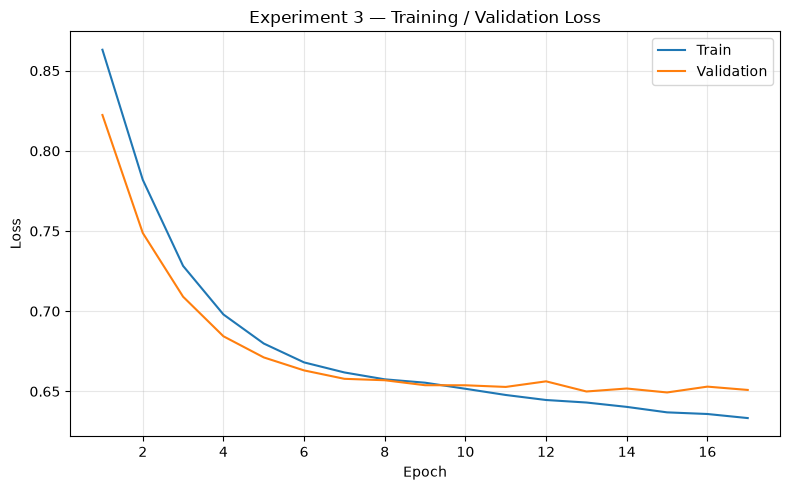

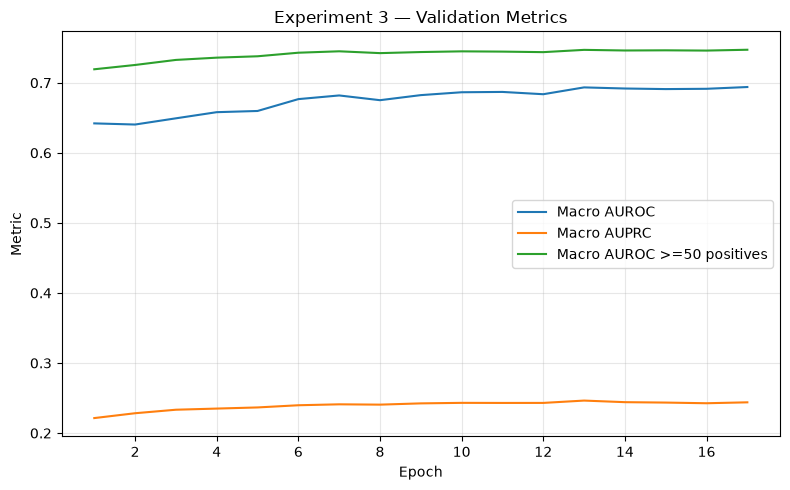


BEST CHECKPOINT
Best epoch: 13
Validation macro AUROC: 0.6934021811795377
Validation macro AUPRC: 0.2463933334341359
Validation AUROC >=50 positives: 0.7469608710504585
Validation AUPRC >=50 positives: 0.33911535279665916


Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]


BEST MODEL VALIDATION PERFORMANCE
Validation loss: 0.64992
Validation macro AUROC: 0.6934
Validation macro AUPRC: 0.24639
Validation stable AUROC: 0.74696
Validation stable AUPRC: 0.33912

                     label  AUROC  AUPRC  prevalence  AUPRC_lift_over_prevalence  positives  negatives  n_valid
               Atelectasis 0.7624 0.4095      0.2112                      1.9391        193        721      914
              Cardiomegaly 0.7380 0.3804      0.2276                      1.6714        216        733      949
             Consolidation 0.7053 0.1209      0.0547                      2.2111         52        899      951
                     Edema 0.8402 0.3794      0.1373                      2.7637        127        798      925
Enlarged Cardiomediastinum 0.5957 0.0483      0.0333                      1.4536         31        901      932
                  Fracture 0.5940 0.0494      0.0310                      1.5944         30        939      969
               Lung Lesion

Patient bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]

            metric  point_estimate  ci_lower  ci_upper  bootstrap_samples_valid
       macro_AUROC         0.69340   0.65608   0.72711                      500
       macro_AUPRC         0.24639   0.21996   0.28207                      500
macro_AUROC_50plus         0.74696   0.71637   0.78614                      500
macro_AUPRC_50plus         0.33912   0.31139   0.42355                      500

VALIDATION THRESHOLD OPTIMIZATION
Atelectasis                    threshold=0.565 val_F1=0.505 (n_pos=193)
Cardiomegaly                   threshold=0.440 val_F1=0.508 (n_pos=216)
Consolidation                  threshold=0.320 val_F1=0.182 (n_pos=52)
Edema                          threshold=0.555 val_F1=0.475 (n_pos=127)
Enlarged Cardiomediastinum     threshold=0.180 val_F1=0.089 (n_pos=31)
Fracture                       threshold=0.135 val_F1=0.115 (n_pos=30)
Lung Lesion                    SKIPPED — only 21 validation positives
Lung Opacity                   threshold=0.550 val_F1=0.464 (n_pos

In [28]:
# ============================================================
# MIMIC-CXR MULTILABEL TRAINING — EXPERIMENT 3
# SINGLE NOTEBOOK CELL
# ============================================================
#
# EXPERIMENT 3 GOAL:
# ------------------------------------------------------------
# Test CHEST-X-RAY-SPECIFIC pretraining.
#
# Main model change from Experiment 2:
#
#   Experiment 2:
#       torchvision DenseNet121
#       ImageNet pretrained
#
#   Experiment 3:
#       TorchXRayVision DenseNet121
#       CheXpert-only pretrained weights
#
#       weights = "densenet121-res224-chex"
#
# IMPORTANT:
# We deliberately DO NOT use the XRV "all" or MIMIC weights,
# because those can include MIMIC-CXR training data and would
# contaminate this experiment.
#
# ------------------------------------------------------------
# Kept from Experiment 2:
# ------------------------------------------------------------
# - same exact patient split
# - AP + PA only
# - 13 outputs
# - NaN -> negative/unmentioned
# - -1 -> ignored
# - 320x320 aspect-ratio preserving pad
# - LR = 3e-5
# - weight decay = 1e-3
# - dropout = 0.30
# - pos_weight cap = 5
# - patience = 4
# - checkpoint using macro AUPRC
# - RUN_TEST=False
#
# ------------------------------------------------------------
# Engineering / evaluation fixes:
# ------------------------------------------------------------
# 1. Strict truncated JPEG check with
#    LOAD_TRUNCATED_IMAGES=False
#
# 2. Recoverable truncated JPEGs are identified separately.
#    They can still be retained for fairness with Exp2.
#
# 3. Filter AP/PA BEFORE expensive JPEG validation.
#
# 4. Deterministic PyTorch/CUDNN settings.
#
# 5. Seed DataLoader workers + shuffle generator.
#
# 6. No val_ids/test_ids variable shadowing.
#
# 7. Exp2 comparison uses its SAVED CHECKPOINT metrics,
#    not max(metric) across unrelated epochs.
#
# 8. Thresholds are NOT fitted for classes with <30
#    validation positives.
#
# 9. Validation patient-level bootstrap confidence intervals.
#
# 10. AUPRC lift over prevalence.
#
# 11. Validation AP vs PA performance breakdown.
#
# ------------------------------------------------------------
# TEST SET:
# ------------------------------------------------------------
# RUN_TEST=False during development.
# ============================================================


# ============================================================
# 0. PACKAGE SETUP
# ============================================================

import sys
import subprocess
import importlib.util


if importlib.util.find_spec("torchxrayvision") is None:

    print(
        "torchxrayvision not found — installing..."
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "torchxrayvision",
        ]
    )


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import json
import random
import warnings

from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from PIL import (
    Image,
    ImageFile,
    ImageOps,
)


from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)


import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
)


from torchvision import transforms


import torchxrayvision as xrv


from tqdm.auto import tqdm


warnings.filterwarnings(
    "ignore"
)


# ============================================================
# 2. CONFIG
# ============================================================

INDEX_CSV = (
    "/workspace/private/unzippedarchive/"
    "xray_image_label_index.csv"
)


# ------------------------------------------------------------
# SAME ORIGINAL PATIENT SPLIT
# ------------------------------------------------------------

SPLIT_CSV = (
    "/workspace/private/unzippedarchive/"
    "xray_training_output/"
    "patient_level_splits.csv"
)


# ------------------------------------------------------------
# EXPERIMENT 2 OUTPUT
# Used only for checkpoint-to-checkpoint comparison
# ------------------------------------------------------------

EXP2_DIR = Path(
    "/workspace/private/unzippedarchive/"
    "xray_training_experiment_2"
)


EXP2_SUMMARY = (
    EXP2_DIR
    / "summary.json"
)


# ------------------------------------------------------------
# EXPERIMENT 3 OUTPUT
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/workspace/private/unzippedarchive/"
    "xray_training_experiment_3"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


SEED = 42


IMAGE_SIZE = 320


BATCH_SIZE = 24


NUM_WORKERS = 4


EPOCHS = 25


PATIENCE = 4


LR = 3e-5


WEIGHT_DECAY = 1e-3


DROPOUT = 0.30


POS_WEIGHT_CAP = 5.0


RUN_TEST = False


# ------------------------------------------------------------
# Tiny-class threshold safeguard
# ------------------------------------------------------------

MIN_POSITIVES_FOR_THRESHOLD = 30


# ------------------------------------------------------------
# Bootstrap settings
# ------------------------------------------------------------

BOOTSTRAP_SAMPLES = 500

BOOTSTRAP_ALPHA = 0.05

BOOTSTRAP_SEED = 12345


# ------------------------------------------------------------
# XRV pretraining
# ------------------------------------------------------------

XRV_WEIGHTS = (
    "densenet121-res224-chex"
)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Enlarged Cardiomediastinum",
    "Fracture",
    "Lung Lesion",
    "Lung Opacity",
    "Pleural Effusion",
    "Pleural Other",
    "Pneumonia",
    "Pneumothorax",
    "Support Devices",
]


print(
    "=" * 80
)

print(
    "EXPERIMENT 3 CONFIG"
)

print(
    "=" * 80
)


print(
    "Device:",
    DEVICE,
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(
            0
        ),
    )

    print(
        "VRAM:",
        round(
            torch.cuda
            .get_device_properties(
                0
            )
            .total_memory
            / 1024**3,
            2,
        ),
        "GB",
    )


print(
    "PyTorch:",
    torch.__version__,
)


print(
    "TorchXRayVision:",
    getattr(
        xrv,
        "__version__",
        "unknown",
    ),
)


print(
    "Image size:",
    IMAGE_SIZE,
)


print(
    "Batch size:",
    BATCH_SIZE,
)


print(
    "Workers:",
    NUM_WORKERS,
)


print(
    "Learning rate:",
    LR,
)


print(
    "Weight decay:",
    WEIGHT_DECAY,
)


print(
    "Dropout:",
    DROPOUT,
)


print(
    "Positive-weight cap:",
    POS_WEIGHT_CAP,
)


print(
    "Pretraining:",
    XRV_WEIGHTS,
)


print(
    "Threshold minimum positives:",
    MIN_POSITIVES_FOR_THRESHOLD,
)


print(
    "Bootstrap samples:",
    BOOTSTRAP_SAMPLES,
)


print(
    "RUN_TEST:",
    RUN_TEST,
)


print()


# ============================================================
# 3. REPRODUCIBILITY
# ============================================================

def seed_everything(
    seed,
):

    os.environ[
        "PYTHONHASHSEED"
    ] = str(
        seed
    )


    random.seed(
        seed
    )


    np.random.seed(
        seed
    )


    torch.manual_seed(
        seed
    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed(
            seed
        )

        torch.cuda.manual_seed_all(
            seed
        )


    # --------------------------------------------------------
    # More deterministic than Experiment 2
    # --------------------------------------------------------

    torch.backends.cudnn.benchmark = False

    torch.backends.cudnn.deterministic = True


    try:

        torch.use_deterministic_algorithms(
            True,
            warn_only=True,
        )

    except Exception:

        pass


    if hasattr(
        torch,
        "set_float32_matmul_precision",
    ):

        torch.set_float32_matmul_precision(
            "high"
        )


seed_everything(
    SEED
)


# ------------------------------------------------------------
# Worker seed function
# ------------------------------------------------------------

def seed_worker(
    worker_id,
):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )


    np.random.seed(
        worker_seed
    )


    random.seed(
        worker_seed
    )


train_generator = (
    torch.Generator()
)

train_generator.manual_seed(
    SEED
)


# ============================================================
# 4. LOAD INDEX
# ============================================================

df = pd.read_csv(
    INDEX_CSV
)


print(
    "=" * 80
)

print(
    "RAW INDEX"
)

print(
    "=" * 80
)


print(
    "Rows:",
    len(
        df
    ),
)


print(
    "Patients:",
    df[
        "subject_id"
    ].nunique(),
)


print(
    "Studies:",
    df[
        "study_id"
    ].nunique(),
)


print(
    "DICOM IDs:",
    df[
        "dicom_id"
    ].nunique(),
)


print()


# ============================================================
# 5. REQUIRED COLUMN / DUPLICATE VALIDATION
# ============================================================

required_cols = [
    "image_path",
    "dicom_id",
    "subject_id",
    "study_id",
    "ViewPosition",
] + LABELS


missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]


if missing_cols:

    raise RuntimeError(
        "Missing columns: "
        f"{missing_cols}"
    )


if df[
    "dicom_id"
].duplicated().any():

    duplicate_rows = df[
        df[
            "dicom_id"
        ].duplicated(
            keep=False
        )
    ]


    raise RuntimeError(
        "Duplicate dicom_id values "
        "inside index CSV: "
        f"{len(duplicate_rows)} rows"
    )


# ============================================================
# 6. FILTER AP / PA BEFORE JPEG VALIDATION
# ============================================================

df = df[
    df[
        "ViewPosition"
    ].isin(
        [
            "AP",
            "PA",
        ]
    )
].copy()


df.reset_index(
    drop=True,
    inplace=True,
)


print(
    "=" * 80
)

print(
    "FRONTAL DATASET"
)

print(
    "=" * 80
)


print(
    "Images:",
    len(
        df
    ),
)


print(
    "Patients:",
    df[
        "subject_id"
    ].nunique(),
)


print(
    "Studies:",
    df[
        "study_id"
    ].nunique(),
)


print()


print(
    df[
        "ViewPosition"
    ].value_counts()
)


print()


# ============================================================
# 7. STRICT JPEG VALIDATION
# ============================================================
#
# Previous bug:
#
# LOAD_TRUNCATED_IMAGES=True before validation meant
# truncated images could silently pass.
#
# Here:
#
# 1. strict decode with truncated handling OFF
# 2. if strict decode fails, try again with truncated loading ON
#
# This lets us distinguish:
#
# - intact
# - truncated but recoverable
# - genuinely unreadable
#
# Recoverable truncated images are kept to preserve the exact
# dataset used by Experiment 2.
# ============================================================

print(
    "=" * 80
)

print(
    "STRICT JPEG VALIDATION"
)

print(
    "=" * 80
)


ImageFile.LOAD_TRUNCATED_IMAGES = False


missing_files = []

recoverable_truncated = []

fatal_images = []


for path in tqdm(
    df[
        "image_path"
    ],
    desc="Validating frontal JPEGs",
):

    if not os.path.exists(
        path
    ):

        missing_files.append(
            path
        )

        continue


    try:

        with Image.open(
            path
        ) as img:

            img.load()


    except Exception as strict_error:

        # ----------------------------------------------------
        # Determine whether PIL can recover it in permissive
        # mode.
        # ----------------------------------------------------

        ImageFile.LOAD_TRUNCATED_IMAGES = True


        try:

            with Image.open(
                path
            ) as img:

                img.load()


            recoverable_truncated.append(
                (
                    path,
                    repr(
                        strict_error
                    ),
                )
            )


        except Exception as permissive_error:

            fatal_images.append(
                (
                    path,
                    repr(
                        strict_error
                    ),
                    repr(
                        permissive_error
                    ),
                )
            )


        finally:

            ImageFile.LOAD_TRUNCATED_IMAGES = False


print()


print(
    "Missing files:",
    len(
        missing_files
    ),
)


print(
    "Strictly truncated but recoverable:",
    len(
        recoverable_truncated
    ),
)


print(
    "Fatal / unreadable:",
    len(
        fatal_images
    ),
)


if recoverable_truncated:

    print()

    print(
        "Recoverable truncated examples:"
    )


    for (
        path,
        error,
    ) in recoverable_truncated[
        :10
    ]:

        print(
            " -",
            path
        )

        print(
            "   ",
            error
        )


if fatal_images:

    print()

    print(
        "Fatal examples:"
    )


    for (
        path,
        strict_error,
        permissive_error,
    ) in fatal_images[
        :10
    ]:

        print(
            " -",
            path
        )

        print(
            "   strict:",
            strict_error
        )

        print(
            "   permissive:",
            permissive_error
        )


fatal_paths = set(
    missing_files
)


fatal_paths.update(
    path
    for (
        path,
        _,
        __,
    ) in fatal_images
)


if fatal_paths:

    before = len(
        df
    )


    df = df[
        ~df[
            "image_path"
        ].isin(
            fatal_paths
        )
    ].copy()


    df.reset_index(
        drop=True,
        inplace=True,
    )


    print()

    print(
        "Removed truly unusable images:",
        before
        - len(
            df
        ),
    )


# ------------------------------------------------------------
# Permit recoverable truncated images DURING training.
# We have already identified them explicitly.
# ------------------------------------------------------------

ImageFile.LOAD_TRUNCATED_IMAGES = True


print()

print(
    "Final frontal images:",
    len(
        df
    ),
)


print()


# ============================================================
# 8. LABEL DISTRIBUTION
# ============================================================

print(
    "=" * 80
)

print(
    "LABEL DISTRIBUTION — FRONTAL ONLY"
)

print(
    "=" * 80
)


for label in LABELS:

    series = df[
        label
    ]


    pos = int(
        (
            series
            == 1
        ).sum()
    )


    explicit_neg = int(
        (
            series
            == 0
        ).sum()
    )


    uncertain = int(
        (
            series
            == -1
        ).sum()
    )


    missing = int(
        series
        .isna()
        .sum()
    )


    print(
        f"{label:30s} "
        f"pos={pos:4d} "
        f"explicit_neg={explicit_neg:4d} "
        f"uncertain={uncertain:4d} "
        f"unmentioned={missing:4d}"
    )


# ============================================================
# 9. LOAD SAME PATIENT SPLIT
# ============================================================

print()

print(
    "=" * 80
)

print(
    "LOADING ORIGINAL PATIENT SPLIT"
)

print(
    "=" * 80
)


if not os.path.exists(
    SPLIT_CSV
):

    raise RuntimeError(
        "Split CSV not found:\n"
        f"{SPLIT_CSV}"
    )


original_split_df = pd.read_csv(
    SPLIT_CSV
)


for required in [
    "subject_id",
    "split",
]:

    if required not in original_split_df.columns:

        raise RuntimeError(
            "Split CSV missing column: "
            f"{required}"
        )


train_subject_ids = set(
    original_split_df.loc[
        original_split_df[
            "split"
        ] == "train",
        "subject_id",
    ].unique()
)


val_subject_ids = set(
    original_split_df.loc[
        original_split_df[
            "split"
        ] == "val",
        "subject_id",
    ].unique()
)


test_subject_ids = set(
    original_split_df.loc[
        original_split_df[
            "split"
        ] == "test",
        "subject_id",
    ].unique()
)


train_df = df[
    df[
        "subject_id"
    ].isin(
        train_subject_ids
    )
].copy()


val_df = df[
    df[
        "subject_id"
    ].isin(
        val_subject_ids
    )
].copy()


test_df = df[
    df[
        "subject_id"
    ].isin(
        test_subject_ids
    )
].copy()


# ============================================================
# 10. LEAKAGE ASSERTIONS
# ============================================================

assert train_subject_ids.isdisjoint(
    val_subject_ids
)


assert train_subject_ids.isdisjoint(
    test_subject_ids
)


assert val_subject_ids.isdisjoint(
    test_subject_ids
)


assert set(
    train_df[
        "dicom_id"
    ]
).isdisjoint(
    set(
        val_df[
            "dicom_id"
        ]
    )
)


assert set(
    train_df[
        "dicom_id"
    ]
).isdisjoint(
    set(
        test_df[
            "dicom_id"
        ]
    )
)


assert set(
    val_df[
        "dicom_id"
    ]
).isdisjoint(
    set(
        test_df[
            "dicom_id"
        ]
    )
)


for (
    name,
    part,
) in [
    (
        "TRAIN",
        train_df,
    ),
    (
        "VAL",
        val_df,
    ),
    (
        "TEST",
        test_df,
    ),
]:

    print(
        f"{name:6s} "
        f"images={len(part):5d} "
        f"patients="
        f"{part['subject_id'].nunique():4d} "
        f"studies="
        f"{part['study_id'].nunique():4d}"
    )


print()


print(
    "Patient leakage check: PASSED"
)


# ============================================================
# 11. SAVE SPLIT COPY
# ============================================================

train_df[
    "split"
] = "train"


val_df[
    "split"
] = "val"


test_df[
    "split"
] = "test"


experiment_split_df = pd.concat(
    [
        train_df,
        val_df,
        test_df,
    ],
    ignore_index=True,
)


experiment_split_df.to_csv(
    OUTPUT_DIR
    / "patient_level_splits.csv",
    index=False,
)


# ============================================================
# 12. SPLIT LABEL COUNTS
# ============================================================

print()

print(
    "=" * 80
)

print(
    "LABEL COUNTS PER SPLIT"
)

print(
    "=" * 80
)


for label in LABELS:

    parts = []


    for (
        split_name,
        split_data,
    ) in [
        (
            "train",
            train_df,
        ),
        (
            "val",
            val_df,
        ),
        (
            "test",
            test_df,
        ),
    ]:

        values = split_data[
            label
        ].fillna(
            0
        )


        positive = int(
            (
                values
                == 1
            ).sum()
        )


        negative = int(
            (
                values
                == 0
            ).sum()
        )


        uncertain = int(
            (
                values
                == -1
            ).sum()
        )


        parts.append(
            f"{split_name}: "
            f"+{positive}/"
            f"-{negative}/"
            f"u{uncertain}"
        )


    print(
        f"{label:30s} "
        + " | ".join(
            parts
        )
    )


# ============================================================
# 13. ASPECT-RATIO RESIZE + PAD
# ============================================================

class ResizeAndPad:

    def __init__(
        self,
        size,
        fill=0,
    ):

        self.size = size

        self.fill = fill


    def __call__(
        self,
        img,
    ):

        width, height = (
            img.size
        )


        scale = min(
            self.size
            / width,

            self.size
            / height,
        )


        new_width = max(
            1,
            int(
                round(
                    width
                    * scale
                )
            ),
        )


        new_height = max(
            1,
            int(
                round(
                    height
                    * scale
                )
            ),
        )


        img = img.resize(
            (
                new_width,
                new_height,
            ),

            Image.Resampling.BILINEAR,
        )


        pad_width = (
            self.size
            - new_width
        )


        pad_height = (
            self.size
            - new_height
        )


        left = (
            pad_width
            // 2
        )


        right = (
            pad_width
            - left
        )


        top = (
            pad_height
            // 2
        )


        bottom = (
            pad_height
            - top
        )


        return ImageOps.expand(
            img,

            border=(
                left,
                top,
                right,
                bottom,
            ),

            fill=self.fill,
        )


# ============================================================
# 14. XRV NORMALIZATION
# ============================================================
#
# TorchXRayVision expects:
#
#   single-channel chest radiograph
#   values normalized approximately to [-1024, 1024]
#
# rather than ImageNet RGB normalization.
# ============================================================

class XRVToTensor:

    def __call__(
        self,
        img,
    ):

        # Force grayscale
        if img.mode != "L":

            img = img.convert(
                "L"
            )


        arr = np.asarray(
            img,
            dtype=np.float32,
        )


        arr = xrv.datasets.normalize(
            arr,
            255,
        )


        if arr.ndim == 2:

            arr = arr[
                None,
                :,
                :,
            ]


        return torch.from_numpy(
            arr
        ).float()


# ============================================================
# 15. TRANSFORMS
# ============================================================
#
# No horizontal flip.
#
# We keep Experiment 2's mild affine augmentation.
# ============================================================

train_transform = transforms.Compose(
    [
        ResizeAndPad(
            IMAGE_SIZE
        ),

        transforms.RandomAffine(
            degrees=5,

            translate=(
                0.02,
                0.02,
            ),

            scale=(
                0.95,
                1.05,
            ),

            fill=0,
        ),

        XRVToTensor(),
    ]
)


eval_transform = transforms.Compose(
    [
        ResizeAndPad(
            IMAGE_SIZE
        ),

        XRVToTensor(),
    ]
)


# ============================================================
# 16. DATASET
# ============================================================

class XRayDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform=None,
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )


        self.transform = (
            transform
        )


    def __len__(
        self,
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx,
    ):

        row = self.df.iloc[
            idx
        ]


        path = row[
            "image_path"
        ]


        try:

            with Image.open(
                path
            ) as img:

                image = img.convert(
                    "L"
                )


        except Exception as error:

            raise RuntimeError(
                "Failed to load image:\n"
                f"{path}\n"
                f"{repr(error)}"
            ) from error


        if self.transform is not None:

            image = self.transform(
                image
            )


        raw_labels = row[
            LABELS
        ].values.astype(
            np.float32
        )


        uncertain_mask = (
            raw_labels
            == -1
        )


        # NaN / unmentioned -> 0
        labels = np.nan_to_num(
            raw_labels,
            nan=0.0,
        )


        labels[
            uncertain_mask
        ] = 0.0


        valid_mask = (
            ~uncertain_mask
        ).astype(
            np.float32
        )


        return (
            image,

            torch.tensor(
                labels,
                dtype=torch.float32,
            ),

            torch.tensor(
                valid_mask,
                dtype=torch.float32,
            ),

            str(
                row[
                    "dicom_id"
                ]
            ),

            int(
                row[
                    "subject_id"
                ]
            ),

            str(
                row[
                    "ViewPosition"
                ]
            ),
        )


# ============================================================
# 17. DATA LOADERS
# ============================================================

train_dataset = XRayDataset(
    train_df,
    transform=train_transform,
)


val_dataset = XRayDataset(
    val_df,
    transform=eval_transform,
)


test_dataset = XRayDataset(
    test_df,
    transform=eval_transform,
)


common_loader_kwargs = dict(

    batch_size=BATCH_SIZE,

    num_workers=NUM_WORKERS,

    pin_memory=(
        torch.cuda.is_available()
    ),

    persistent_workers=(
        NUM_WORKERS
        > 0
    ),

    worker_init_fn=(
        seed_worker
    ),
)


train_loader = DataLoader(

    train_dataset,

    shuffle=True,

    drop_last=False,

    generator=train_generator,

    **common_loader_kwargs,
)


val_loader = DataLoader(

    val_dataset,

    shuffle=False,

    drop_last=False,

    **common_loader_kwargs,
)


test_loader = DataLoader(

    test_dataset,

    shuffle=False,

    drop_last=False,

    **common_loader_kwargs,
)


print()

print(
    "Train batches:",
    len(
        train_loader
    ),
)


print(
    "Val batches:",
    len(
        val_loader
    ),
)


print(
    "Test batches:",
    len(
        test_loader
    ),
)


# ============================================================
# 18. CLASS WEIGHTS
# ============================================================

print()

print(
    "=" * 80
)

print(
    "CLASS WEIGHTS"
)

print(
    "=" * 80
)


pos_weights = []


for label in LABELS:

    values = train_df[
        label
    ].fillna(
        0
    )


    values = values[
        values
        != -1
    ]


    positives = int(
        (
            values
            == 1
        ).sum()
    )


    negatives = int(
        (
            values
            == 0
        ).sum()
    )


    if positives == 0:

        weight = 1.0

    else:

        weight = (
            negatives
            / positives
        )


    weight = float(
        np.clip(
            weight,
            1.0,
            POS_WEIGHT_CAP,
        )
    )


    pos_weights.append(
        weight
    )


    print(
        f"{label:30s} "
        f"pos={positives:4d} "
        f"neg={negatives:4d} "
        f"weight={weight:.3f}"
    )


pos_weights = torch.tensor(
    pos_weights,

    dtype=torch.float32,

    device=DEVICE,
)


# ============================================================
# 19. MODEL
# ============================================================
#
# XRV's pretrained DenseNet is trained at 224x224.
#
# Instead of using its original fixed classifier path, we reuse
# the convolutional features and apply ADAPTIVE pooling.
#
# This lets us keep Experiment 2's 320x320 input size.
# ============================================================

class CheXpertPretrainedDenseNet13(
    nn.Module
):

    def __init__(
        self,
        dropout,
    ):

        super().__init__()


        pretrained = xrv.models.DenseNet(
            weights=XRV_WEIGHTS,

            apply_sigmoid=False,
        )


        self.pretrained_pathologies = list(
            pretrained.pathologies
        )


        self.features = (
            pretrained.features
        )


        in_features = (
            pretrained
            .classifier
            .in_features
        )


        self.dropout = nn.Dropout(
            p=dropout
        )


        self.classifier = nn.Linear(
            in_features,
            len(
                LABELS
            ),
        )


    def forward(
        self,
        x,
    ):

        features = self.features(
            x
        )


        x = F.relu(
            features,
            inplace=True,
        )


        x = F.adaptive_avg_pool2d(
            x,
            (
                1,
                1,
            ),
        )


        x = torch.flatten(
            x,
            1,
        )


        x = self.dropout(
            x
        )


        x = self.classifier(
            x
        )


        return x


model = CheXpertPretrainedDenseNet13(
    dropout=DROPOUT
)


model = model.to(
    DEVICE
)


print()

print(
    "=" * 80
)

print(
    "MODEL"
)

print(
    "=" * 80
)


print(
    "Architecture:",
    model.__class__.__name__,
)


print(
    "Pretraining:",
    XRV_WEIGHTS,
)


print(
    "Output classes:",
    len(
        LABELS
    ),
)


print(
    "Input channels: 1"
)


print(
    "Classifier dropout:",
    DROPOUT,
)


print()

print(
    "XRV pretrained pathologies:"
)


print(
    model.pretrained_pathologies
)


# ============================================================
# 20. LOSS
# ============================================================

criterion = nn.BCEWithLogitsLoss(

    reduction="none",

    pos_weight=pos_weights,
)


def masked_bce_loss(
    logits,
    targets,
    mask,
):

    raw_loss = criterion(
        logits,
        targets,
    )


    masked_loss = (
        raw_loss
        * mask
    )


    denominator = (
        mask
        .sum()
        .clamp(
            min=1.0
        )
    )


    return (
        masked_loss.sum()
        / denominator
    )


# ============================================================
# 21. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=WEIGHT_DECAY,
)


# ============================================================
# 22. SCHEDULER
# ============================================================
#
# Kept intentionally identical to Experiment 2 so that
# this experiment primarily tests pretraining.
# ============================================================

scheduler = (
    torch.optim
    .lr_scheduler
    .ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=0.5,

        patience=2,

        min_lr=1e-7,
    )
)


# ============================================================
# 23. MIXED PRECISION
# ============================================================

USE_AMP = (
    torch.cuda.is_available()
)


AMP_DTYPE = (
    torch.float16
)


scaler = torch.amp.GradScaler(

    "cuda",

    enabled=USE_AMP,
)


# ============================================================
# 24. METRIC FUNCTIONS
# ============================================================

def calculate_metrics(
    targets,
    probabilities,
    masks,
):

    results = {}


    all_aurocs = []

    all_auprcs = []


    stable_aurocs = []

    stable_auprcs = []


    for (
        index,
        label,
    ) in enumerate(
        LABELS
    ):

        valid = (
            masks[
                :,
                index
            ]
            == 1
        )


        y_true = targets[
            valid,
            index
        ]


        y_probability = probabilities[
            valid,
            index
        ]


        positives = int(
            (
                y_true
                == 1
            ).sum()
        )


        negatives = int(
            (
                y_true
                == 0
            ).sum()
        )


        prevalence = (
            positives
            / len(
                y_true
            )
            if len(
                y_true
            ) > 0
            else np.nan
        )


        if len(
            np.unique(
                y_true
            )
        ) < 2:

            auroc = np.nan

            auprc = np.nan


        else:

            auroc = roc_auc_score(
                y_true,
                y_probability,
            )


            auprc = average_precision_score(
                y_true,
                y_probability,
            )


        if (
            prevalence > 0
            and not np.isnan(
                auprc
            )
        ):

            auprc_lift = (
                auprc
                / prevalence
            )

        else:

            auprc_lift = np.nan


        results[
            label
        ] = {

            "AUROC": auroc,

            "AUPRC": auprc,

            "prevalence": prevalence,

            "AUPRC_lift": auprc_lift,

            "positives": positives,

            "negatives": negatives,
        }


        if not np.isnan(
            auroc
        ):

            all_aurocs.append(
                auroc
            )


        if not np.isnan(
            auprc
        ):

            all_auprcs.append(
                auprc
            )


        # ----------------------------------------------------
        # More stable auxiliary macro metric.
        # NOT used to select the checkpoint in Exp3.
        # ----------------------------------------------------

        if positives >= 50:

            if not np.isnan(
                auroc
            ):

                stable_aurocs.append(
                    auroc
                )


            if not np.isnan(
                auprc
            ):

                stable_auprcs.append(
                    auprc
                )


    results[
        "macro_AUROC"
    ] = (
        float(
            np.mean(
                all_aurocs
            )
        )
        if all_aurocs
        else np.nan
    )


    results[
        "macro_AUPRC"
    ] = (
        float(
            np.mean(
                all_auprcs
            )
        )
        if all_auprcs
        else np.nan
    )


    results[
        "macro_AUROC_50plus"
    ] = (
        float(
            np.mean(
                stable_aurocs
            )
        )
        if stable_aurocs
        else np.nan
    )


    results[
        "macro_AUPRC_50plus"
    ] = (
        float(
            np.mean(
                stable_auprcs
            )
        )
        if stable_auprcs
        else np.nan
    )


    return results


# ============================================================
# 25. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
):

    model.train()


    running_loss = 0.0

    samples = 0


    progress = tqdm(
        loader,

        desc="Training",

        leave=False,
    )


    for (
        images,
        targets,
        masks,
        _dicom_ids,
        _subject_ids,
        _views,
    ) in progress:


        images = images.to(
            DEVICE,
            non_blocking=True,
        )


        targets = targets.to(
            DEVICE,
            non_blocking=True,
        )


        masks = masks.to(
            DEVICE,
            non_blocking=True,
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=AMP_DTYPE,

            enabled=USE_AMP,
        ):

            logits = model(
                images
            )


            loss = masked_bce_loss(
                logits,
                targets,
                masks,
            )


        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )


        scaler.step(
            optimizer
        )


        scaler.update()


        batch_size = images.size(
            0
        )


        running_loss += (
            loss.item()
            * batch_size
        )


        samples += (
            batch_size
        )


        progress.set_postfix(

            loss=(
                f"{loss.item():.4f}"
            ),

            lr=(
                f"{optimizer.param_groups[0]['lr']:.2e}"
            ),
        )


    return (
        running_loss
        / max(
            samples,
            1,
        )
    )


# ============================================================
# 26. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(
    model,
    loader,
):

    model.eval()


    running_loss = 0.0

    samples = 0


    all_targets = []

    all_probabilities = []

    all_masks = []


    all_dicom_ids = []

    all_subject_ids = []

    all_views = []


    progress = tqdm(
        loader,

        desc="Evaluating",

        leave=False,
    )


    for (
        images,
        targets,
        masks,
        dicom_ids,
        subject_ids,
        views,
    ) in progress:


        images = images.to(
            DEVICE,
            non_blocking=True,
        )


        targets = targets.to(
            DEVICE,
            non_blocking=True,
        )


        masks = masks.to(
            DEVICE,
            non_blocking=True,
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=AMP_DTYPE,

            enabled=USE_AMP,
        ):

            logits = model(
                images
            )


            loss = masked_bce_loss(
                logits,
                targets,
                masks,
            )


        probabilities = torch.sigmoid(
            logits
        )


        batch_size = images.size(
            0
        )


        running_loss += (
            loss.item()
            * batch_size
        )


        samples += (
            batch_size
        )


        all_targets.append(
            targets
            .detach()
            .cpu()
            .numpy()
        )


        all_probabilities.append(
            probabilities
            .detach()
            .cpu()
            .numpy()
        )


        all_masks.append(
            masks
            .detach()
            .cpu()
            .numpy()
        )


        all_dicom_ids.extend(
            list(
                dicom_ids
            )
        )


        all_subject_ids.extend(
            subject_ids
            .cpu()
            .numpy()
            .tolist()
        )


        all_views.extend(
            list(
                views
            )
        )


    targets = np.concatenate(
        all_targets,
        axis=0,
    )


    probabilities = np.concatenate(
        all_probabilities,
        axis=0,
    )


    masks = np.concatenate(
        all_masks,
        axis=0,
    )


    metrics = calculate_metrics(
        targets,
        probabilities,
        masks,
    )


    return {

        "loss": (
            running_loss
            / max(
                samples,
                1,
            )
        ),

        "metrics": metrics,

        "targets": targets,

        "probabilities": probabilities,

        "masks": masks,

        "dicom_ids": all_dicom_ids,

        "subject_ids": np.asarray(
            all_subject_ids
        ),

        "views": np.asarray(
            all_views
        ),
    }


# ============================================================
# 27. TRAINING LOOP
# ============================================================

history = []


best_selection_metric = (
    -np.inf
)


epochs_without_improvement = 0


best_checkpoint = (
    OUTPUT_DIR
    / "best_model.pt"
)


print()

print(
    "=" * 80
)

print(
    "TRAINING — EXPERIMENT 3"
)

print(
    "=" * 80
)


for epoch in range(
    1,
    EPOCHS + 1,
):

    print()

    print(
        f"Epoch {epoch}/{EPOCHS}"
    )

    print(
        "-" * 80
    )


    train_loss = train_one_epoch(
        model,
        train_loader,
    )


    validation_result = evaluate(
        model,
        val_loader,
    )


    val_loss = (
        validation_result[
            "loss"
        ]
    )


    val_metrics = (
        validation_result[
            "metrics"
        ]
    )


    macro_auroc = (
        val_metrics[
            "macro_AUROC"
        ]
    )


    macro_auprc = (
        val_metrics[
            "macro_AUPRC"
        ]
    )


    stable_auroc = (
        val_metrics[
            "macro_AUROC_50plus"
        ]
    )


    stable_auprc = (
        val_metrics[
            "macro_AUPRC_50plus"
        ]
    )


    # --------------------------------------------------------
    # Kept same as Experiment 2 for controlled comparison.
    # --------------------------------------------------------

    scheduler.step(
        macro_auprc
    )


    current_lr = (
        optimizer
        .param_groups[
            0
        ][
            "lr"
        ]
    )


    print(
        f"Train loss          : "
        f"{train_loss:.5f}"
    )


    print(
        f"Val loss            : "
        f"{val_loss:.5f}"
    )


    print(
        f"Macro AUROC         : "
        f"{macro_auroc:.5f}"
    )


    print(
        f"Macro AUPRC         : "
        f"{macro_auprc:.5f}"
    )


    print(
        f"Macro AUROC (>=50+) : "
        f"{stable_auroc:.5f}"
    )


    print(
        f"Macro AUPRC (>=50+) : "
        f"{stable_auprc:.5f}"
    )


    print(
        f"LR                  : "
        f"{current_lr:.2e}"
    )


    history.append(
        {

            "epoch": epoch,

            "train_loss": train_loss,

            "val_loss": val_loss,

            "macro_AUROC": macro_auroc,

            "macro_AUPRC": macro_auprc,

            "macro_AUROC_50plus": stable_auroc,

            "macro_AUPRC_50plus": stable_auprc,

            "lr": current_lr,
        }
    )


    # --------------------------------------------------------
    # Keep Experiment 2 checkpoint criterion.
    # --------------------------------------------------------

    selection_metric = (
        macro_auprc
    )


    if selection_metric > best_selection_metric:

        best_selection_metric = (
            selection_metric
        )


        epochs_without_improvement = 0


        torch.save(
            {

                "epoch": epoch,

                "model_state_dict": (
                    model.state_dict()
                ),

                "optimizer_state_dict": (
                    optimizer.state_dict()
                ),

                "macro_AUROC": (
                    macro_auroc
                ),

                "macro_AUPRC": (
                    macro_auprc
                ),

                "macro_AUROC_50plus": (
                    stable_auroc
                ),

                "macro_AUPRC_50plus": (
                    stable_auprc
                ),

                "labels": LABELS,

                "image_size": IMAGE_SIZE,

                "pretraining": (
                    XRV_WEIGHTS
                ),

                "dropout": DROPOUT,

                "learning_rate": LR,

                "weight_decay": (
                    WEIGHT_DECAY
                ),

                "pos_weight_cap": (
                    POS_WEIGHT_CAP
                ),
            },

            best_checkpoint,
        )


        print(
            "✓ Saved new best model — "
            "Macro AUPRC: "
            f"{macro_auprc:.5f}"
        )


    else:

        epochs_without_improvement += 1


        print(
            "No AUPRC improvement "
            f"({epochs_without_improvement}/"
            f"{PATIENCE})"
        )


        if (
            epochs_without_improvement
            >= PATIENCE
        ):

            print()

            print(
                "Early stopping triggered."
            )

            break


# ============================================================
# 28. SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    OUTPUT_DIR
    / "training_history.csv",
    index=False,
)


# ============================================================
# 29. TRAINING CURVES
# ============================================================

plt.figure(
    figsize=(
        8,
        5,
    )
)


plt.plot(
    history_df[
        "epoch"
    ],

    history_df[
        "train_loss"
    ],

    label="Train",
)


plt.plot(
    history_df[
        "epoch"
    ],

    history_df[
        "val_loss"
    ],

    label="Validation",
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "Experiment 3 — Training / Validation Loss"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "loss_curve.png",

    dpi=150,
)


plt.show()


plt.figure(
    figsize=(
        8,
        5,
    )
)


plt.plot(
    history_df[
        "epoch"
    ],

    history_df[
        "macro_AUROC"
    ],

    label="Macro AUROC",
)


plt.plot(
    history_df[
        "epoch"
    ],

    history_df[
        "macro_AUPRC"
    ],

    label="Macro AUPRC",
)


plt.plot(
    history_df[
        "epoch"
    ],

    history_df[
        "macro_AUROC_50plus"
    ],

    label="Macro AUROC >=50 positives",
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Metric"
)


plt.title(
    "Experiment 3 — Validation Metrics"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "validation_metrics.png",

    dpi=150,
)


plt.show()


# ============================================================
# 30. LOAD SAVED BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    best_checkpoint,

    map_location=DEVICE,
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


print()

print(
    "=" * 80
)

print(
    "BEST CHECKPOINT"
)

print(
    "=" * 80
)


print(
    "Best epoch:",
    checkpoint[
        "epoch"
    ],
)


print(
    "Validation macro AUROC:",
    checkpoint[
        "macro_AUROC"
    ],
)


print(
    "Validation macro AUPRC:",
    checkpoint[
        "macro_AUPRC"
    ],
)


print(
    "Validation AUROC >=50 positives:",
    checkpoint[
        "macro_AUROC_50plus"
    ],
)


print(
    "Validation AUPRC >=50 positives:",
    checkpoint[
        "macro_AUPRC_50plus"
    ],
)


# ============================================================
# 31. RE-EVALUATE BEST CHECKPOINT
# ============================================================

val_result = evaluate(
    model,
    val_loader,
)


val_loss = (
    val_result[
        "loss"
    ]
)


val_metrics = (
    val_result[
        "metrics"
    ]
)


val_targets = (
    val_result[
        "targets"
    ]
)


val_probabilities = (
    val_result[
        "probabilities"
    ]
)


val_masks = (
    val_result[
        "masks"
    ]
)


val_dicom_ids = (
    val_result[
        "dicom_ids"
    ]
)


val_subject_array = (
    val_result[
        "subject_ids"
    ]
)


val_views = (
    val_result[
        "views"
    ]
)


print()

print(
    "=" * 80
)

print(
    "BEST MODEL VALIDATION PERFORMANCE"
)

print(
    "=" * 80
)


print(
    "Validation loss:",
    round(
        val_loss,
        5,
    ),
)


print(
    "Validation macro AUROC:",
    round(
        val_metrics[
            "macro_AUROC"
        ],
        5,
    ),
)


print(
    "Validation macro AUPRC:",
    round(
        val_metrics[
            "macro_AUPRC"
        ],
        5,
    ),
)


print(
    "Validation stable AUROC:",
    round(
        val_metrics[
            "macro_AUROC_50plus"
        ],
        5,
    ),
)


print(
    "Validation stable AUPRC:",
    round(
        val_metrics[
            "macro_AUPRC_50plus"
        ],
        5,
    ),
)


# ============================================================
# 32. PER-CLASS VALIDATION METRICS
# ============================================================

validation_rows = []


for (
    index,
    label,
) in enumerate(
    LABELS
):

    label_metrics = (
        val_metrics[
            label
        ]
    )


    validation_rows.append(
        {

            "label": label,

            "AUROC": (
                label_metrics[
                    "AUROC"
                ]
            ),

            "AUPRC": (
                label_metrics[
                    "AUPRC"
                ]
            ),

            "prevalence": (
                label_metrics[
                    "prevalence"
                ]
            ),

            "AUPRC_lift_over_prevalence": (
                label_metrics[
                    "AUPRC_lift"
                ]
            ),

            "positives": (
                label_metrics[
                    "positives"
                ]
            ),

            "negatives": (
                label_metrics[
                    "negatives"
                ]
            ),

            "n_valid": (
                label_metrics[
                    "positives"
                ]
                + label_metrics[
                    "negatives"
                ]
            ),
        }
    )


validation_metrics_df = pd.DataFrame(
    validation_rows
)


validation_metrics_df.to_csv(
    OUTPUT_DIR
    / "validation_per_class_metrics.csv",

    index=False,
)


print()

print(
    validation_metrics_df
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ============================================================
# 33. AP VS PA VALIDATION BREAKDOWN
# ============================================================

print()

print(
    "=" * 80
)

print(
    "VALIDATION PERFORMANCE BY VIEW"
)

print(
    "=" * 80
)


view_rows = []


for view in [
    "AP",
    "PA",
]:

    view_mask = (
        val_views
        == view
    )


    if (
        view_mask
        .sum()
        == 0
    ):

        continue


    view_metrics = calculate_metrics(

        val_targets[
            view_mask
        ],

        val_probabilities[
            view_mask
        ],

        val_masks[
            view_mask
        ],
    )


    row = {

        "view": view,

        "images": int(
            view_mask
            .sum()
        ),

        "macro_AUROC": (
            view_metrics[
                "macro_AUROC"
            ]
        ),

        "macro_AUPRC": (
            view_metrics[
                "macro_AUPRC"
            ]
        ),

        "macro_AUROC_50plus": (
            view_metrics[
                "macro_AUROC_50plus"
            ]
        ),

        "macro_AUPRC_50plus": (
            view_metrics[
                "macro_AUPRC_50plus"
            ]
        ),
    }


    view_rows.append(
        row
    )


view_metrics_df = pd.DataFrame(
    view_rows
)


view_metrics_df.to_csv(
    OUTPUT_DIR
    / "validation_view_breakdown.csv",

    index=False,
)


print(
    view_metrics_df
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ============================================================
# 34. PATIENT-LEVEL BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================
#
# Resample patients rather than individual images.
#
# This preserves intra-patient correlation.
# ============================================================

def patient_bootstrap_ci(

    targets,

    probabilities,

    masks,

    subject_ids,

    samples=500,

    alpha=0.05,

    seed=12345,
):

    rng = np.random.default_rng(
        seed
    )


    unique_subjects = np.unique(
        subject_ids
    )


    subject_to_indices = {

        subject: np.where(
            subject_ids
            == subject
        )[0]

        for subject in unique_subjects
    }


    metric_names = [
        "macro_AUROC",
        "macro_AUPRC",
        "macro_AUROC_50plus",
        "macro_AUPRC_50plus",
    ]


    distributions = {

        metric: []

        for metric in metric_names
    }


    for _ in tqdm(
        range(
            samples
        ),

        desc="Patient bootstrap",
    ):

        sampled_subjects = rng.choice(

            unique_subjects,

            size=len(
                unique_subjects
            ),

            replace=True,
        )


        sampled_indices = np.concatenate(
            [
                subject_to_indices[
                    subject
                ]

                for subject in sampled_subjects
            ]
        )


        metrics = calculate_metrics(

            targets[
                sampled_indices
            ],

            probabilities[
                sampled_indices
            ],

            masks[
                sampled_indices
            ],
        )


        for metric in metric_names:

            value = metrics[
                metric
            ]


            if not np.isnan(
                value
            ):

                distributions[
                    metric
                ].append(
                    value
                )


    rows = []


    point_metrics = calculate_metrics(
        targets,
        probabilities,
        masks,
    )


    for metric in metric_names:

        values = np.asarray(
            distributions[
                metric
            ],
            dtype=float,
        )


        if len(
            values
        ) == 0:

            lower = np.nan

            upper = np.nan

        else:

            lower = np.quantile(
                values,
                alpha
                / 2,
            )


            upper = np.quantile(
                values,
                1
                - alpha
                / 2,
            )


        rows.append(
            {

                "metric": metric,

                "point_estimate": (
                    point_metrics[
                        metric
                    ]
                ),

                "ci_lower": lower,

                "ci_upper": upper,

                "bootstrap_samples_valid": (
                    len(
                        values
                    )
                ),
            }
        )


    return pd.DataFrame(
        rows
    )


print()

print(
    "=" * 80
)

print(
    "PATIENT-LEVEL BOOTSTRAP CI"
)

print(
    "=" * 80
)


bootstrap_df = patient_bootstrap_ci(

    val_targets,

    val_probabilities,

    val_masks,

    val_subject_array,

    samples=BOOTSTRAP_SAMPLES,

    alpha=BOOTSTRAP_ALPHA,

    seed=BOOTSTRAP_SEED,
)


bootstrap_df.to_csv(
    OUTPUT_DIR
    / "validation_bootstrap_ci.csv",

    index=False,
)


print(
    bootstrap_df
    .round(
        5
    )
    .to_string(
        index=False
    )
)


# ============================================================
# 35. VALIDATION THRESHOLD OPTIMIZATION
# ============================================================
#
# Thresholded F1 is NOT estimated for classes with fewer than
# MIN_POSITIVES_FOR_THRESHOLD positive validation examples.
# ============================================================

thresholds = {}


threshold_rows = []


print()

print(
    "=" * 80
)

print(
    "VALIDATION THRESHOLD OPTIMIZATION"
)

print(
    "=" * 80
)


for (
    index,
    label,
) in enumerate(
    LABELS
):

    valid = (
        val_masks[
            :,
            index
        ]
        == 1
    )


    y_true = val_targets[
        valid,
        index
    ]


    y_probability = val_probabilities[
        valid,
        index
    ]


    positive_count = int(
        (
            y_true
            == 1
        ).sum()
    )


    if (
        positive_count
        < MIN_POSITIVES_FOR_THRESHOLD
    ):

        threshold = None

        best_f1 = np.nan


        print(
            f"{label:30s} "
            f"SKIPPED — only "
            f"{positive_count} validation positives"
        )


    elif len(
        np.unique(
            y_true
        )
    ) < 2:

        threshold = None

        best_f1 = np.nan


        print(
            f"{label:30s} "
            "SKIPPED — only one class present"
        )


    else:

        threshold = 0.5

        best_f1 = -1.0


        for candidate in np.linspace(
            0.05,
            0.95,
            181,
        ):

            prediction = (
                y_probability
                >= candidate
            ).astype(
                int
            )


            score = f1_score(

                y_true,

                prediction,

                zero_division=0,
            )


            if score > best_f1:

                best_f1 = score

                threshold = float(
                    candidate
                )


        print(
            f"{label:30s} "
            f"threshold="
            f"{threshold:.3f} "
            f"val_F1="
            f"{best_f1:.3f} "
            f"(n_pos={positive_count})"
        )


    thresholds[
        label
    ] = threshold


    threshold_rows.append(
        {

            "label": label,

            "validation_positives": (
                positive_count
            ),

            "threshold": threshold,

            "validation_F1": (
                best_f1
            ),
        }
    )


threshold_df = pd.DataFrame(
    threshold_rows
)


threshold_df.to_csv(
    OUTPUT_DIR
    / "validation_thresholds.csv",

    index=False,
)


with open(
    OUTPUT_DIR
    / "thresholds.json",

    "w",
) as file:

    json.dump(
        thresholds,
        file,
        indent=2,
    )


# ============================================================
# 36. SAVE VALIDATION PREDICTIONS
# ============================================================

validation_predictions_df = pd.DataFrame(
    {

        "dicom_id": (
            val_dicom_ids
        ),

        "subject_id": (
            val_subject_array
        ),

        "view": (
            val_views
        ),
    }
)


for (
    index,
    label,
) in enumerate(
    LABELS
):

    validation_predictions_df[
        f"{label}_prob"
    ] = (
        val_probabilities[
            :,
            index
        ]
    )


    validation_predictions_df[
        f"{label}_target"
    ] = (
        val_targets[
            :,
            index
        ]
    )


    validation_predictions_df[
        f"{label}_mask"
    ] = (
        val_masks[
            :,
            index
        ]
    )


validation_predictions_df.to_csv(

    OUTPUT_DIR
    / "validation_predictions.csv",

    index=False,
)


# ============================================================
# 37. OPTIONAL TEST EVALUATION
# ============================================================

test_result = None


if RUN_TEST:

    print()

    print(
        "=" * 80
    )

    print(
        "FINAL HELD-OUT TEST"
    )

    print(
        "=" * 80
    )


    test_result = evaluate(
        model,
        test_loader,
    )


    test_metrics = (
        test_result[
            "metrics"
        ]
    )


    print(
        "Test loss:",
        round(
            test_result[
                "loss"
            ],
            5,
        ),
    )


    print(
        "Test macro AUROC:",
        round(
            test_metrics[
                "macro_AUROC"
            ],
            5,
        ),
    )


    print(
        "Test macro AUPRC:",
        round(
            test_metrics[
                "macro_AUPRC"
            ],
            5,
        ),
    )


    test_rows = []


    for (
        index,
        label,
    ) in enumerate(
        LABELS
    ):

        valid = (
            test_result[
                "masks"
            ][
                :,
                index
            ]
            == 1
        )


        y_true = (
            test_result[
                "targets"
            ][
                valid,
                index
            ]
        )


        y_probability = (
            test_result[
                "probabilities"
            ][
                valid,
                index
            ]
        )


        label_metrics = (
            test_metrics[
                label
            ]
        )


        threshold = thresholds[
            label
        ]


        if threshold is None:

            precision = np.nan

            sensitivity = np.nan

            specificity = np.nan

            f1 = np.nan

            tp = np.nan

            fp = np.nan

            tn = np.nan

            fn = np.nan


        else:

            y_prediction = (
                y_probability
                >= threshold
            ).astype(
                int
            )


            precision = precision_score(
                y_true,
                y_prediction,
                zero_division=0,
            )


            sensitivity = recall_score(
                y_true,
                y_prediction,
                zero_division=0,
            )


            f1 = f1_score(
                y_true,
                y_prediction,
                zero_division=0,
            )


            matrix = confusion_matrix(

                y_true,

                y_prediction,

                labels=[
                    0,
                    1,
                ],
            )


            tn, fp, fn, tp = (
                matrix.ravel()
            )


            specificity = (
                tn
                / (
                    tn
                    + fp
                )
                if (
                    tn
                    + fp
                ) > 0
                else np.nan
            )


        test_rows.append(
            {

                "label": label,

                "AUROC": (
                    label_metrics[
                        "AUROC"
                    ]
                ),

                "AUPRC": (
                    label_metrics[
                        "AUPRC"
                    ]
                ),

                "prevalence": (
                    label_metrics[
                        "prevalence"
                    ]
                ),

                "AUPRC_lift_over_prevalence": (
                    label_metrics[
                        "AUPRC_lift"
                    ]
                ),

                "threshold": (
                    threshold
                ),

                "precision": (
                    precision
                ),

                "sensitivity_recall": (
                    sensitivity
                ),

                "specificity": (
                    specificity
                ),

                "F1": (
                    f1
                ),

                "TP": tp,

                "FP": fp,

                "TN": tn,

                "FN": fn,

                "positives": (
                    label_metrics[
                        "positives"
                    ]
                ),

                "negatives": (
                    label_metrics[
                        "negatives"
                    ]
                ),
            }
        )


    test_metrics_df = pd.DataFrame(
        test_rows
    )


    test_metrics_df.to_csv(

        OUTPUT_DIR
        / "test_metrics.csv",

        index=False,
    )


    print()

    print(
        test_metrics_df
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


    test_predictions_df = pd.DataFrame(
        {

            "dicom_id": (
                test_result[
                    "dicom_ids"
                ]
            ),

            "subject_id": (
                test_result[
                    "subject_ids"
                ]
            ),

            "view": (
                test_result[
                    "views"
                ]
            ),
        }
    )


    for (
        index,
        label,
    ) in enumerate(
        LABELS
    ):

        test_predictions_df[
            f"{label}_prob"
        ] = (
            test_result[
                "probabilities"
            ][
                :,
                index
            ]
        )


        test_predictions_df[
            f"{label}_target"
        ] = (
            test_result[
                "targets"
            ][
                :,
                index
            ]
        )


        test_predictions_df[
            f"{label}_mask"
        ] = (
            test_result[
                "masks"
            ][
                :,
                index
            ]
        )


        threshold = thresholds[
            label
        ]


        if threshold is None:

            test_predictions_df[
                f"{label}_prediction"
            ] = -1

        else:

            test_predictions_df[
                f"{label}_prediction"
            ] = (
                test_result[
                    "probabilities"
                ][
                    :,
                    index
                ]
                >= threshold
            ).astype(
                int
            )


    test_predictions_df.to_csv(

        OUTPUT_DIR
        / "test_predictions.csv",

        index=False,
    )


else:

    print()

    print(
        "=" * 80
    )

    print(
        "TEST SET NOT EVALUATED"
    )

    print(
        "=" * 80
    )

    print(
        "RUN_TEST=False"
    )


    print(
        "Continue comparing experiments "
        "using validation only."
    )


# ============================================================
# 38. EXPERIMENT SUMMARY
# ============================================================

summary = {

    "experiment": (
        "experiment_3_chexpert_pretrained_densenet121"
    ),

    "index_csv": (
        INDEX_CSV
    ),

    "split_source": (
        SPLIT_CSV
    ),

    "architecture": (
        "TorchXRayVision DenseNet121"
    ),

    "pretraining": (
        XRV_WEIGHTS
    ),

    "pretraining_dataset": (
        "CheXpert"
    ),

    "views": [
        "AP",
        "PA",
    ],

    "image_size": (
        IMAGE_SIZE
    ),

    "resize_strategy": (
        "preserve_aspect_ratio_and_pad"
    ),

    "input_channels": (
        1
    ),

    "normalization": (
        "TorchXRayVision [-1024,1024]"
    ),

    "batch_size": (
        BATCH_SIZE
    ),

    "num_workers": (
        NUM_WORKERS
    ),

    "learning_rate": (
        LR
    ),

    "weight_decay": (
        WEIGHT_DECAY
    ),

    "dropout": (
        DROPOUT
    ),

    "positive_weight_cap": (
        POS_WEIGHT_CAP
    ),

    "checkpoint_metric": (
        "macro_AUPRC"
    ),

    "early_stopping_patience": (
        PATIENCE
    ),

    "epochs_requested": (
        EPOCHS
    ),

    "epochs_completed": int(
        len(
            history_df
        )
    ),

    "best_epoch": int(
        checkpoint[
            "epoch"
        ]
    ),

    "best_validation_macro_AUROC": float(
        checkpoint[
            "macro_AUROC"
        ]
    ),

    "best_validation_macro_AUPRC": float(
        checkpoint[
            "macro_AUPRC"
        ]
    ),

    "best_validation_macro_AUROC_50plus": float(
        checkpoint[
            "macro_AUROC_50plus"
        ]
    ),

    "best_validation_macro_AUPRC_50plus": float(
        checkpoint[
            "macro_AUPRC_50plus"
        ]
    ),

    "train_images": int(
        len(
            train_df
        )
    ),

    "val_images": int(
        len(
            val_df
        )
    ),

    "test_images": int(
        len(
            test_df
        )
    ),

    "train_patients": int(
        train_df[
            "subject_id"
        ].nunique()
    ),

    "val_patients": int(
        val_df[
            "subject_id"
        ].nunique()
    ),

    "test_patients": int(
        test_df[
            "subject_id"
        ].nunique()
    ),

    "recoverable_truncated_images": int(
        len(
            recoverable_truncated
        )
    ),

    "removed_fatal_images": int(
        len(
            fatal_paths
        )
    ),

    "deterministic_training": (
        True
    ),

    "minimum_positive_count_for_threshold": (
        MIN_POSITIVES_FOR_THRESHOLD
    ),

    "bootstrap_samples": (
        BOOTSTRAP_SAMPLES
    ),

    "test_evaluated": (
        RUN_TEST
    ),

    "labels": LABELS,
}


if (
    RUN_TEST
    and test_result
    is not None
):

    summary[
        "test_macro_AUROC"
    ] = float(
        test_result[
            "metrics"
        ][
            "macro_AUROC"
        ]
    )


    summary[
        "test_macro_AUPRC"
    ] = float(
        test_result[
            "metrics"
        ][
            "macro_AUPRC"
        ]
    )


with open(
    OUTPUT_DIR
    / "summary.json",

    "w",
) as file:

    json.dump(
        summary,
        file,
        indent=2,
    )


# ============================================================
# 39. EXPERIMENT 2 vs EXPERIMENT 3
# CHECKPOINT-TO-CHECKPOINT COMPARISON
# ============================================================
#
# Fixes the previous comparison bug:
#
# We DO NOT compare max(AUROC) and max(AUPRC) from unrelated
# epochs.
#
# Instead, use the metrics stored for the actual saved model.
# ============================================================

print()

print(
    "=" * 80
)

print(
    "CHECKPOINT-TO-CHECKPOINT COMPARISON"
)

print(
    "=" * 80
)


comparison_rows = []


if EXP2_SUMMARY.exists():

    with open(
        EXP2_SUMMARY,
        "r",
    ) as file:

        exp2_summary = json.load(
            file
        )


    exp2_auroc = exp2_summary.get(
        "best_validation_macro_AUROC",
        np.nan,
    )


    exp2_auprc = exp2_summary.get(
        "best_validation_macro_AUPRC",
        np.nan,
    )


    exp2_epoch = exp2_summary.get(
        "best_epoch",
        np.nan,
    )


    comparison_rows.append(
        {

            "experiment": (
                "Experiment 2"
            ),

            "checkpoint_epoch": (
                exp2_epoch
            ),

            "validation_macro_AUROC": (
                exp2_auroc
            ),

            "validation_macro_AUPRC": (
                exp2_auprc
            ),

            "pretraining": (
                exp2_summary.get(
                    "pretraining",
                    "ImageNet",
                )
            ),
        }
    )


else:

    print(
        "Experiment 2 summary.json "
        "not found."
    )


comparison_rows.append(
    {

        "experiment": (
            "Experiment 3"
        ),

        "checkpoint_epoch": int(
            checkpoint[
                "epoch"
            ]
        ),

        "validation_macro_AUROC": float(
            checkpoint[
                "macro_AUROC"
            ]
        ),

        "validation_macro_AUPRC": float(
            checkpoint[
                "macro_AUPRC"
            ]
        ),

        "pretraining": (
            XRV_WEIGHTS
        ),
    }
)


comparison_df = pd.DataFrame(
    comparison_rows
)


comparison_df.to_csv(
    OUTPUT_DIR
    / "experiment_comparison.csv",

    index=False,
)


print(
    comparison_df
    .round(
        5
    )
    .to_string(
        index=False
    )
)


# ============================================================
# 40. FINAL OUTPUT
# ============================================================

print()

print(
    "=" * 80
)

print(
    "EXPERIMENT 3 COMPLETE"
)

print(
    "=" * 80
)


print(
    "Output directory:"
)


print(
    OUTPUT_DIR
)


print()


print(
    "Best epoch:",
    checkpoint[
        "epoch"
    ],
)


print(
    "Validation macro AUROC:",
    round(
        checkpoint[
            "macro_AUROC"
        ],
        5,
    ),
)


print(
    "Validation macro AUPRC:",
    round(
        checkpoint[
            "macro_AUPRC"
        ],
        5,
    ),
)


print(
    "Stable validation AUROC (>=50 positives):",
    round(
        checkpoint[
            "macro_AUROC_50plus"
        ],
        5,
    ),
)


print(
    "Stable validation AUPRC (>=50 positives):",
    round(
        checkpoint[
            "macro_AUPRC_50plus"
        ],
        5,
    ),
)


print()


print(
    "Recoverable truncated JPEGs:",
    len(
        recoverable_truncated
    ),
)


print(
    "Fatal JPEGs removed:",
    len(
        fatal_paths
    ),
)


print()


print(
    "Files:"
)


for path in sorted(
    OUTPUT_DIR.iterdir()
):

    print(
        " -",
        path.name
    )


# ============================================================
# 41. CLEANUP
# ============================================================

gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()

EXPERIMENT 3B | cuda | pretraining: densenet121-res224-chex
Torch: 2.14.0+cu130 | XRV: 1.5.4
RUN_TEST: False | 224x224 grayscale | 11 transferred + 2 new rows
Experiment 2 saved checkpoint: {'experiment': 'Experiment 2', 'checkpoint_epoch': 8, 'pretraining': 'ImageNet IMAGENET1K_V1', 'metrics_source': '/workspace/private/unzippedarchive/xray_training_experiment_2/summary.json', 'validation_macro_AUROC': 0.7545719293527688, 'validation_macro_AUPRC': 0.29012354562630044}
Previous output files preserved in: /workspace/private/unzippedarchive/xray_training_experiment_3b/previous_run_20260928T172511_071047Z


Strict JPEG validation:   0%|          | 0/6723 [00:00<?, ?it/s]

JPEG validation: {'intact': 6665, 'recoverable_truncated': 58}
train:   4830 images,  1231 patients
val  :    970 images,   264 patients
test :    923 images,   264 patients
Cohort comparison: Identical image IDs in all splits
                     label  positives  negatives  pos_weight
               Atelectasis        992       3637    3.666331
              Cardiomegaly        955       3731    3.906806
             Consolidation        240       4502    5.000000
                     Edema        530       4023    5.000000
Enlarged Cardiomediastinum        147       4459    5.000000
                  Fracture        120       4698    5.000000
               Lung Lesion        135       4674    5.000000
              Lung Opacity       1101       3656    3.320618
          Pleural Effusion       1158       3538    3.055268
             Pleural Other         71       4742    5.000000
                 Pneumonia        332       4140    5.000000
              Pneumothorax        205    

Training:   0%|          | 0/202 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

...

Epoch 22 | stage 2.20 | train 0.62329 | val 0.62943 | AUROC 0.70629 | AUPRC 0.26650 | AUROC50 0.76664 | AUPRC50 0.36461 | LRs {'backbone': 1e-05, 'classifier': 0.0001}


Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

BEST CHECKPOINT: 21 | stage: 2
{'macro_AUROC': 0.7058743378107165, 'macro_AUPRC': 0.26746639781906056, 'macro_AUROC_50plus': 0.7663139614817951, 'macro_AUPRC_50plus': 0.3661927814428261}
                     label   AUROC   AUPRC  prevalence  AUPRC_lift_over_prevalence  positives  negatives  n_valid
               Atelectasis 0.77722 0.43675     0.21116                     2.06835        193        721      914
              Cardiomegaly 0.79248 0.48150     0.22761                     2.11546        216        733      949
             Consolidation 0.74140 0.11240     0.05468                     2.05566         52        899      951
                     Edema 0.86311 0.44740     0.13730                     3.25861        127        798      925
Enlarged Cardiomediastinum 0.63913 0.07958     0.03326                     2.39243         31        901      932
                  Fracture 0.58317 0.04057     0.03096                     1.31028         30        939      969
               

Patient-cluster bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]

label             metric  point_estimate  ci_lower  ci_upper  confidence_level  bootstrap_samples_requested  bootstrap_samples_valid  bootstrap_samples_undefined
macro        macro_AUROC         0.70587   0.67459   0.73405              0.95                          500                      493                            7
macro        macro_AUPRC         0.26747   0.24658   0.29883              0.95                          500                      493                            7
macro macro_AUROC_50plus         0.76631   0.73336   0.79330              0.95                          500                      500                            0
macro macro_AUPRC_50plus         0.36619   0.33256   0.40816              0.95                          500                      500                            0
Validation-fitted F1 (in-sample, not an unbiased held-out estimate):
                     label  validation_positives  validation_negatives  threshold  validation_F1            status
      

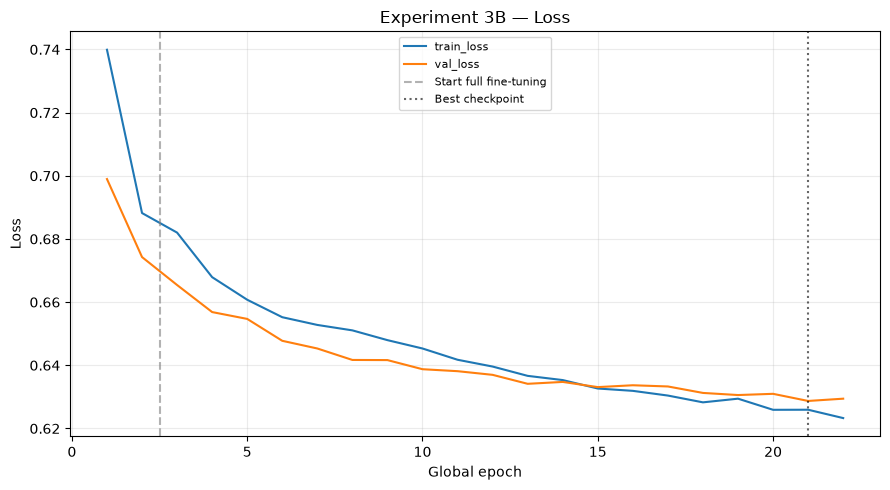

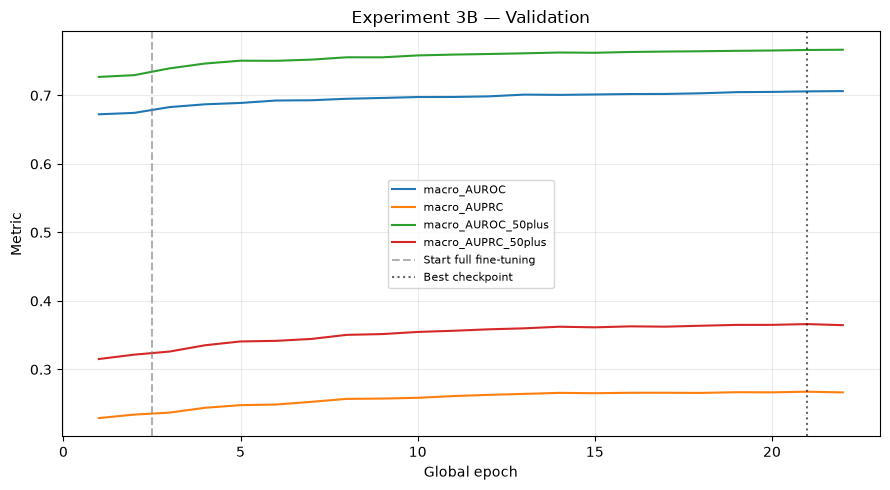


CHECKPOINT-TO-CHECKPOINT COMPARISON
   experiment  checkpoint_epoch             pretraining  validation_macro_AUROC  validation_macro_AUPRC
 Experiment 2                 8  ImageNet IMAGENET1K_V1                 0.75457                 0.29012
Experiment 3B                21 densenet121-res224-chex                 0.70587                 0.26747
Experiment 3B minus Experiment 2: {'AUROC': -0.04869759154205233, 'AUPRC': -0.022657147807239875}
Experiment 3B complete. Outputs: /workspace/private/unzippedarchive/xray_training_experiment_3b


In [31]:
# ============================================================
# MIMIC-CXR EXPERIMENT 3B — ONE COMPLETE NOTEBOOK CELL
# Paste this entire file into one cell in the Experiment 3 environment.
# Requires the same local image index, original splits, and Exp2 summary.
# No training or test results are embedded: this cell computes them.
# ============================================================

# ============================================================
# 0. SETUP AND CONFIGURATION
# ============================================================
import os
# Set before CUDA operations. A fresh notebook kernel is recommended.
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import sys
import gc
import json
import math
import random
import shutil
import hashlib
import platform
import subprocess
import importlib.util
from pathlib import Path
from contextlib import nullcontext

if importlib.util.find_spec('torchxrayvision') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'torchxrayvision'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, confusion_matrix)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import torchxrayvision as xrv
from tqdm.auto import tqdm

INDEX_CSV = Path('/workspace/private/unzippedarchive/xray_image_label_index.csv')
SPLIT_CSV = Path('/workspace/private/unzippedarchive/xray_training_output/patient_level_splits.csv')
EXP2_DIR = Path('/workspace/private/unzippedarchive/xray_training_experiment_2')
EXP2_SUMMARY = EXP2_DIR / 'summary.json'
OUTPUT_DIR = Path('/workspace/private/unzippedarchive/xray_training_experiment_3b')

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 24
NUM_WORKERS = 4 if sys.platform.startswith('linux') else 0
STAGE1_EPOCHS = 2
STAGE2_EPOCHS = 20
STAGE1_CLASSIFIER_LR = 3e-4
STAGE2_BACKBONE_LR = 1e-5
STAGE2_CLASSIFIER_LR = 1e-4
PATIENCE = 4
WEIGHT_DECAY = 1e-3
DROPOUT = 0.30
POS_WEIGHT_CAP = 5.0
RUN_TEST = False
MIN_POSITIVES_FOR_THRESHOLD = 30
BOOTSTRAP_SAMPLES = 500
BOOTSTRAP_ALPHA = 0.05
BOOTSTRAP_SEED = 12345
XRV_WEIGHTS = 'densenet121-res224-chex'
LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion',
    'Lung Opacity', 'Pleural Effusion', 'Pleural Other',
    'Pneumonia', 'Pneumothorax', 'Support Devices',
]
TRANSFER_MAP = {
    label: ('Effusion' if label == 'Pleural Effusion' else label)
    for label in LABELS if label not in {'Pleural Other', 'Support Devices'}
}
METRIC_NAMES = ['macro_AUROC', 'macro_AUPRC',
                'macro_AUROC_50plus', 'macro_AUPRC_50plus']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
assert len(LABELS) == 13 and len(set(LABELS)) == 13
assert 'No Finding' not in LABELS and len(TRANSFER_MAP) == 11


def clean_json(value):
    """Write real JSON null, never the nonstandard NaN / Infinity tokens."""
    if isinstance(value, dict):
        return {str(key): clean_json(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [clean_json(item) for item in value]
    if isinstance(value, np.ndarray):
        return clean_json(value.tolist())
    if isinstance(value, np.generic):
        return clean_json(value.item())
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


def save_json(path, payload):
    temporary = path.with_suffix(path.suffix + '.tmp')
    temporary.write_text(json.dumps(clean_json(payload), indent=2,
                                    allow_nan=False), encoding='utf-8')
    os.replace(temporary, path)


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def seed_everything(seed):
    # PYTHONHASHSEED cannot change this already-running interpreter's hash seed.
    # No stochastic decision below depends on iteration order of a Python set.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)  # fail visibly on unsupported ops


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)
    # Needed even for workers that do not inherit the parent's PIL setting.
    ImageFile.LOAD_TRUNCATED_IMAGES = True


seed_everything(SEED)
print('EXPERIMENT 3B |', DEVICE, '| pretraining:', XRV_WEIGHTS)
print('Torch:', torch.__version__, '| XRV:', getattr(xrv, '__version__', 'unknown'))
print('RUN_TEST:', RUN_TEST, '| 224x224 grayscale | 11 transferred + 2 new rows')

# ============================================================
# 1. FAIL-FAST INPUT AND EXPERIMENT 2 CHECKPOINT METADATA CHECKS
# ============================================================
for required_path in [INDEX_CSV, SPLIT_CSV, EXP2_SUMMARY]:
    if not required_path.is_file():
        raise FileNotFoundError(f'Required input is missing: {required_path}')


def read_exp2_checkpoint_summary(path):
    summary_data = json.loads(path.read_text(encoding='utf-8'))
    # These are the saved-checkpoint keys used by the supplied Experiment 3
    # comparison. Never substitute independent metric maxima or reference text.
    required = ['best_epoch', 'best_validation_macro_AUROC',
                'best_validation_macro_AUPRC']
    missing = [key for key in required if summary_data.get(key) is None]
    if missing:
        raise ValueError(
            f'{path} lacks saved-checkpoint fields {missing}. '
            'Check its schema and map actual checkpoint fields explicitly; '
            'do not substitute history maxima or hardcoded reference scores. '
            f'Available keys: {sorted(summary_data)}')
    checkpoint_epoch = float(summary_data['best_epoch'])
    if not math.isfinite(checkpoint_epoch) or checkpoint_epoch < 1 or not checkpoint_epoch.is_integer():
        raise ValueError('Experiment 2 best_epoch must be a positive integer.')
    result = {'experiment': 'Experiment 2', 'checkpoint_epoch': int(checkpoint_epoch),
              'pretraining': summary_data.get('pretraining', 'ImageNet'),
              'metrics_source': str(path)}
    for short_name in ['AUROC', 'AUPRC']:
        metric_value = float(summary_data[f'best_validation_macro_{short_name}'])
        if not math.isfinite(metric_value) or not 0 <= metric_value <= 1:
            raise ValueError(f'Invalid saved Experiment 2 {short_name}: {metric_value}')
        result[f'validation_macro_{short_name}'] = metric_value
    if 'labels' in summary_data and summary_data['labels'] != LABELS:
        raise ValueError('Experiment 2 labels/order differ from Experiment 3B.')
    return summary_data, result


exp2_summary, exp2_comparison_row = read_exp2_checkpoint_summary(EXP2_SUMMARY)
print('Experiment 2 saved checkpoint:', exp2_comparison_row)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Preserve earlier attempts if this cell is rerun, including stale test outputs.
# The original experiment folders are never modified.
if any(OUTPUT_DIR.iterdir()):
    from datetime import datetime, timezone
    archive_dir = OUTPUT_DIR / ('previous_run_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ'))
    existing_files = [entry for entry in OUTPUT_DIR.iterdir() if entry.is_file()]
    if existing_files:
        archive_dir.mkdir()
        for entry in existing_files:
            shutil.move(str(entry), str(archive_dir / entry.name))
        print('Previous output files preserved in:', archive_dir)

# ============================================================
# 2. INDEX, ORIGINAL PATIENT SPLITS, AND LEAKAGE CHECKS
# ============================================================

def read_index(path):
    frame = pd.read_csv(path, dtype={'subject_id': 'string', 'study_id': 'string',
                                     'dicom_id': 'string'})
    required = ['image_path', 'dicom_id', 'subject_id', 'study_id', 'ViewPosition'] + LABELS
    missing = [column for column in required if column not in frame]
    if missing:
        raise ValueError(f'Index missing columns: {missing}')
    for column in ['image_path', 'dicom_id', 'subject_id', 'study_id']:
        if frame[column].isna().any() or frame[column].astype(str).str.strip().eq('').any():
            raise ValueError(f'Index contains missing/empty {column}.')
    if frame['dicom_id'].duplicated().any():
        raise ValueError('Duplicate dicom_id values in the image index.')
    # Filter views before any JPEG decoding.
    frame = frame.loc[frame['ViewPosition'].isin(['AP', 'PA'])].copy()
    if frame.empty:
        raise ValueError('No AP/PA images in the index.')
    for label in LABELS:
        frame[label] = pd.to_numeric(frame[label], errors='raise')
        invalid = frame[label].notna() & ~frame[label].isin([-1, 0, 1])
        if invalid.any():
            raise ValueError(f'Unexpected values in {label}: {frame.loc[invalid, label].unique()}')
    # Relative paths, if present, are relative to the index CSV's directory.
    frame['image_path'] = frame['image_path'].map(
        lambda value: str(Path(value) if Path(value).is_absolute() else path.parent / value))
    return frame.reset_index(drop=True)


def read_patient_assignments(path):
    frame = pd.read_csv(path, dtype={'subject_id': 'string'})
    if not {'subject_id', 'split'}.issubset(frame.columns):
        raise ValueError(f'{path} must contain subject_id and split.')
    if frame[['subject_id', 'split']].isna().any().any():
        raise ValueError(f'{path} contains missing split assignments.')
    if not frame['split'].isin(['train', 'val', 'test']).all():
        raise ValueError(f'{path} has unknown split names; expected train / val / test.')
    assignments = frame[['subject_id', 'split']].drop_duplicates()
    if assignments['subject_id'].duplicated().any():
        raise ValueError(f'Patient leakage: multiple splits assigned in {path}.')
    return frame, assignments.set_index('subject_id')['split']


df = read_index(INDEX_CSV)
original_split_df, subject_to_split = read_patient_assignments(SPLIT_CSV)
unknown_subjects = sorted(set(df['subject_id']) - set(subject_to_split.index))
if unknown_subjects:
    raise ValueError(f'{len(unknown_subjects)} frontal patients absent from the original split; '
                     f'no new split will be generated. Examples: {unknown_subjects[:5]}')
df['split'] = df['subject_id'].map(subject_to_split)
train_subject_ids = set(subject_to_split.index[subject_to_split == 'train'])
val_subject_ids = set(subject_to_split.index[subject_to_split == 'val'])
test_subject_ids = set(subject_to_split.index[subject_to_split == 'test'])
assert train_subject_ids.isdisjoint(val_subject_ids)
assert train_subject_ids.isdisjoint(test_subject_ids)
assert val_subject_ids.isdisjoint(test_subject_ids)
# Save the original split file byte-for-byte, even if unusable images are removed.
shutil.copy2(SPLIT_CSV, OUTPUT_DIR / 'patient_level_splits.csv')

# ============================================================
# 3. STRICT JPEG VALIDATION, THEN RECOVERABLE DECODING
# ============================================================

def validate_jpegs(frame):
    audit_rows = []
    for image_path in tqdm(frame['image_path'].drop_duplicates(), desc='Strict JPEG validation'):
        ImageFile.LOAD_TRUNCATED_IMAGES = False
        status, strict_message, permissive_message = 'intact', '', ''
        if not Path(image_path).is_file():
            status, strict_message = 'missing', 'File not found'
        else:
            try:
                with Image.open(image_path) as image:
                    image.load()  # verify() alone does not force full decoding
                    image.convert('L').load()
            except (OSError, ValueError, SyntaxError, Image.DecompressionBombError) as strict_error:
                strict_message = repr(strict_error)
                ImageFile.LOAD_TRUNCATED_IMAGES = True
                try:
                    with Image.open(image_path) as image:
                        image.load()
                        image.convert('L').load()
                    status = 'recoverable_truncated'
                except (OSError, ValueError, SyntaxError, Image.DecompressionBombError) as permissive_error:
                    status, permissive_message = 'fatal', repr(permissive_error)
                finally:
                    ImageFile.LOAD_TRUNCATED_IMAGES = False
        audit_rows.append({'image_path': image_path, 'status': status,
                           'strict_error': strict_message, 'permissive_error': permissive_message})
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    return pd.DataFrame(audit_rows)


jpeg_audit = validate_jpegs(df)
jpeg_audit.to_csv(OUTPUT_DIR / 'jpeg_validation_report.csv', index=False)
fatal_paths = set(jpeg_audit.loc[jpeg_audit['status'].isin(['missing', 'fatal']), 'image_path'])
df = df.loc[~df['image_path'].isin(fatal_paths)].reset_index(drop=True)
print('JPEG validation:', jpeg_audit['status'].value_counts().to_dict())
train_df = df.loc[df['split'] == 'train'].reset_index(drop=True)
val_df = df.loc[df['split'] == 'val'].reset_index(drop=True)
test_df = df.loc[df['split'] == 'test'].reset_index(drop=True)
for split_name, split_frame in [('train', train_df), ('val', val_df), ('test', test_df)]:
    if split_frame.empty:
        raise ValueError(f'No usable AP/PA images remain in {split_name}.')
    print(f'{split_name:5s}: {len(split_frame):6d} images, '
          f'{split_frame.subject_id.nunique():5d} patients')
for identifier in ['subject_id', 'study_id', 'dicom_id', 'image_path']:
    split_sets = [set(part[identifier]) for part in [train_df, val_df, test_df]]
    assert all(split_sets[left].isdisjoint(split_sets[right])
               for left, right in [(0, 1), (0, 2), (1, 2)]), f'Leakage via {identifier}'
df.to_csv(OUTPUT_DIR / 'dataset_manifest.csv', index=False)

# Verify Exp2 patient assignments when its manifest is available; report any
# changed image cohort rather than silently calling the comparison identical.
comparison_cohort_status = 'Exp2 manifest unavailable; original patient assignments reused'
exp2_split_path = EXP2_DIR / 'patient_level_splits.csv'
if exp2_split_path.is_file():
    exp2_manifest, exp2_assignments = read_patient_assignments(exp2_split_path)
    shared_subjects = subject_to_split.index.intersection(exp2_assignments.index)
    if not subject_to_split.loc[shared_subjects].equals(exp2_assignments.loc[shared_subjects]):
        raise ValueError('Experiment 2 and original patient assignments disagree.')
    comparison_cohort_status = 'Patient assignments agree; image membership not available'
    if 'dicom_id' in exp2_manifest:
        cohort_differences = {}
        for split_name, current_frame in [('train', train_df), ('val', val_df), ('test', test_df)]:
            prior_ids = set(exp2_manifest.loc[exp2_manifest['split'] == split_name, 'dicom_id'].astype(str))
            current_ids = set(current_frame['dicom_id'].astype(str))
            cohort_differences[split_name] = {'only_exp2': len(prior_ids - current_ids),
                                               'only_exp3b': len(current_ids - prior_ids)}
        comparison_cohort_status = ('Identical image IDs in all splits' if all(
            count == 0 for item in cohort_differences.values() for count in item.values())
            else 'Image cohorts differ: ' + json.dumps(cohort_differences))
print('Cohort comparison:', comparison_cohort_status)

# ============================================================
# 4. NATIVE XRV PREPROCESSING AND THE EXISTING MILD AUGMENTATION
# ============================================================
# Official reference: https://github.com/mlmed/torchxrayvision
# grayscale -> normalize(255) -> center crop -> resize(224) -> float tensor.
# Keep Exp3's mild affine ONLY during training; its black fill becomes -1024
# in XRV units. No ImageNet normalization, padding, or stronger augmentation.
class NativeXRVTransform:
    def __init__(self, training=False):
        self.crop = xrv.datasets.XRayCenterCrop()
        self.resize = xrv.datasets.XRayResizer(IMAGE_SIZE)
        self.affine = (transforms.RandomAffine(
            degrees=5, translate=(0.02, 0.02), scale=(0.95, 1.05), fill=-1024.0
        ) if training else None)

    def __call__(self, image):
        array = np.asarray(image.convert('L'), dtype=np.float32)
        array = xrv.datasets.normalize(array, 255)[None, :, :]
        array = self.resize(self.crop(array))
        tensor = torch.from_numpy(np.array(array, dtype=np.float32, copy=True))
        if self.affine is not None:
            tensor = self.affine(tensor)
        if tensor.shape != (1, IMAGE_SIZE, IMAGE_SIZE) or not torch.isfinite(tensor).all():
            raise ValueError(f'Invalid preprocessed image: {tuple(tensor.shape)}')
        return tensor


def encode_labels(raw):
    raw = np.asarray(raw, dtype=np.float32)
    masks = (raw != -1).astype(np.float32)
    targets = np.where(raw == 1, 1.0, 0.0).astype(np.float32)
    return targets, masks


class XRayDataset(Dataset):
    def __init__(self, dataframe, training=False):
        self.frame = dataframe.reset_index(drop=True)
        self.transform = NativeXRVTransform(training)
        self.targets, self.masks = encode_labels(self.frame[LABELS].to_numpy(dtype=np.float32))

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        try:
            with Image.open(row['image_path']) as source:
                image = self.transform(source)
        except (OSError, ValueError, SyntaxError) as error:
            raise RuntimeError(f"Cannot decode/transform {row['image_path']}: {error}") from error
        return (image, torch.from_numpy(self.targets[index]), torch.from_numpy(self.masks[index]),
                str(row['dicom_id']), str(row['subject_id']), str(row['ViewPosition']))


# Worker processes in a Linux notebook use fork. Other platforms use 0 workers
# to avoid spawn trying to import classes defined only in a notebook cell.
loader_generators = {}

def make_loader(frame, training, seed_offset):
    generator = torch.Generator().manual_seed(SEED + seed_offset)
    loader_generators[seed_offset] = generator
    kwargs = dict(batch_size=BATCH_SIZE, shuffle=training, drop_last=False,
                  num_workers=NUM_WORKERS, pin_memory=USE_AMP,
                  persistent_workers=NUM_WORKERS > 0, worker_init_fn=seed_worker,
                  generator=generator)
    if NUM_WORKERS:
        kwargs['multiprocessing_context'] = 'fork'
    return DataLoader(XRayDataset(frame, training), **kwargs)


train_loader = make_loader(train_df, True, 0)
val_loader = make_loader(val_df, False, 1)
# No test loader or inference is created unless explicitly enabled.
test_loader = make_loader(test_df, False, 2) if RUN_TEST else None

# Training-only class weights; ignored entries never count as negatives.
train_targets, train_masks = encode_labels(train_df[LABELS].to_numpy(dtype=np.float32))
positive_counts = (train_targets * train_masks).sum(axis=0)
negative_counts = ((1 - train_targets) * train_masks).sum(axis=0)
pos_weight_values = np.divide(negative_counts, positive_counts,
                             out=np.ones(len(LABELS), dtype=np.float32), where=positive_counts > 0)
pos_weight_values = np.clip(pos_weight_values, 1.0, POS_WEIGHT_CAP)
class_weight_report = pd.DataFrame({'label': LABELS, 'positives': positive_counts.astype(int),
                                    'negatives': negative_counts.astype(int), 'pos_weight': pos_weight_values})
print(class_weight_report.to_string(index=False))
class_weight_report.to_csv(OUTPUT_DIR / 'training_class_weights.csv', index=False)

# ============================================================
# 5. TRANSFER 11 CLASSIFIER ROWS + BIASES; KEEP 2 RANDOM ROWS
# ============================================================
class CheXpertPretrainedDenseNet13(nn.Module):
    def __init__(self, dropout=DROPOUT):
        super().__init__()
        pretrained = xrv.models.DenseNet(weights=XRV_WEIGHTS, apply_sigmoid=False)
        self.pretrained_pathologies = list(pretrained.pathologies)
        for source_label in TRANSFER_MAP.values():
            assert self.pretrained_pathologies.count(source_label) == 1, (
                f"Expected exactly one pretrained row for {source_label!r}; "
                f"got {self.pretrained_pathologies.count(source_label)}. "
                f"Pathologies: {self.pretrained_pathologies!r}"
            )
        missing = sorted(set(TRANSFER_MAP.values()) - set(self.pretrained_pathologies))
        assert not missing, f'Missing expected pretrained pathologies: {missing}'
        old_classifier = pretrained.classifier
        assert isinstance(old_classifier, nn.Linear) and old_classifier.bias is not None
        assert old_classifier.out_features == len(self.pretrained_pathologies)
        self.features = pretrained.features
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(old_classifier.in_features, len(LABELS))
        self.backbone_frozen = False
        self.initialization_report = []
        with torch.no_grad():
            for target_index, label in enumerate(LABELS):
                source_label = TRANSFER_MAP.get(label)
                source_index = None
                if source_label is not None:
                    source_index = self.pretrained_pathologies.index(source_label)
                    weight_row = old_classifier.weight[source_index]
                    bias_value = old_classifier.bias[source_index]
                    assert torch.isfinite(weight_row).all() and torch.isfinite(bias_value)
                    self.classifier.weight[target_index].copy_(weight_row)
                    self.classifier.bias[target_index].copy_(bias_value)
                    assert torch.equal(self.classifier.weight[target_index], weight_row)
                    assert torch.equal(self.classifier.bias[target_index], bias_value)
                report = {'label': label, 'initialization': 'pretrained' if source_label else 'random',
                          'source_pathology': source_label, 'source_row': source_index}
                self.initialization_report.append(report)
                description = f'pretrained "{source_label}"' if source_label else 'random'
                print(f'{label:28s} <- {description}')
        # Keep the supplied Exp3 raw-logit forward path: use features directly,
        # never XRV's optional output sigmoid / operating-point normalization.

    def freeze_backbone(self, frozen):
        self.backbone_frozen = bool(frozen)
        self.features.requires_grad_(not frozen)
        self.features.train(self.training and not frozen)
        self.classifier.requires_grad_(True)

    def train(self, mode=True):
        super().train(mode)
        # requires_grad=False alone does NOT freeze BatchNorm running buffers.
        if self.backbone_frozen:
            self.features.eval()
        return self

    def forward(self, images):
        features = self.features(images)
        pooled = F.adaptive_avg_pool2d(F.relu(features, inplace=True), (1, 1)).flatten(1)
        return self.classifier(self.dropout(pooled))  # raw logits, [B, 13]


model = CheXpertPretrainedDenseNet13().to(DEVICE)
pd.DataFrame(model.initialization_report).to_csv(OUTPUT_DIR / 'classifier_initialization.csv', index=False)
criterion = nn.BCEWithLogitsLoss(reduction='none',
    pos_weight=torch.tensor(pos_weight_values, dtype=torch.float32, device=DEVICE))


def loss_components(logits, targets, masks):
    # Full precision BCE and sigmoid prevent half-precision probability ties.
    element_losses = criterion(logits.float(), targets.float())
    return (element_losses * masks).sum(), masks.sum()


def amp_context():
    return torch.autocast(device_type='cuda', dtype=torch.float16) if USE_AMP else nullcontext()


def make_scaler():
    if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
        return torch.amp.GradScaler('cuda', enabled=USE_AMP)
    return torch.cuda.amp.GradScaler(enabled=USE_AMP)


# A deterministic sample check does not consume the training shuffle generator.
example_image = val_loader.dataset[0][0]
assert -1024.1 <= example_image.min().item() <= example_image.max().item() <= 1024.1
model.eval()
with torch.no_grad():
    example_logits = model(example_image.unsqueeze(0).to(DEVICE))
assert example_logits.shape == (1, len(LABELS)) and torch.isfinite(example_logits).all()
del example_logits, example_image

# ============================================================
# 6. MASK-AWARE METRICS (AUPRC = AVERAGE PRECISION, AS IN EXP3)
# ============================================================
def calculate_metrics(targets, probabilities, masks, macro_indices=None, stable_indices=None):
    if targets.shape != probabilities.shape or targets.shape != masks.shape:
        raise ValueError('Metric arrays must have identical shapes.')
    if targets.ndim != 2 or targets.shape[1] != len(LABELS):
        raise ValueError('Expected [n_images, 13] metric arrays.')
    if not np.isfinite(probabilities).all():
        raise FloatingPointError('Non-finite predicted probabilities.')
    results = {}
    for label_index, label in enumerate(LABELS):
        valid = masks[:, label_index] == 1
        truth = targets[valid, label_index]
        probability = probabilities[valid, label_index]
        positives = int((truth == 1).sum())
        negatives = int((truth == 0).sum())
        prevalence = positives / len(truth) if len(truth) else np.nan
        # Match Exp3's evaluability policy for both metrics.
        auroc = roc_auc_score(truth, probability) if positives and negatives else np.nan
        auprc = average_precision_score(truth, probability) if positives and negatives else np.nan
        results[label] = {'AUROC': float(auroc), 'AUPRC': float(auprc),
                          'prevalence': prevalence,
                          'AUPRC_lift_over_prevalence': auprc / prevalence if prevalence > 0 else np.nan,
                          'positives': positives, 'negatives': negatives, 'n_valid': len(truth)}
    eligible_indices = [i for i, label in enumerate(LABELS)
                        if results[label]['positives'] > 0 and results[label]['negatives'] > 0]
    if macro_indices is None:
        macro_indices = eligible_indices
    if stable_indices is None:
        stable_indices = [i for i in eligible_indices if results[LABELS[i]]['positives'] >= 50]
    for metric in ['AUROC', 'AUPRC']:
        # Ordinary mean deliberately propagates NaN for a degenerate bootstrap
        # draw instead of quietly changing which labels define its macro metric.
        results[f'macro_{metric}'] = (float(np.mean([results[LABELS[i]][metric] for i in macro_indices]))
                                     if len(macro_indices) else np.nan)
        results[f'macro_{metric}_50plus'] = (float(np.mean([results[LABELS[i]][metric] for i in stable_indices]))
                                            if len(stable_indices) else np.nan)
    results['macro_label_count'] = len(macro_indices)
    results['stable_label_count'] = len(stable_indices)
    return results


def run_epoch(loader, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train(training)
    loss_numerator, valid_entries = 0.0, 0.0
    collected = {'targets': [], 'probabilities': [], 'masks': [],
                 'dicom_ids': [], 'subject_ids': [], 'views': []}
    gradient_context = nullcontext() if training else torch.no_grad()
    with gradient_context:
        for images, targets, masks, dicom_ids, subject_ids, views in tqdm(
                loader, desc='Training' if training else 'Evaluating', leave=False):
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            if training:
                optimizer.zero_grad(set_to_none=True)
            with amp_context():
                logits = model(images)
            if not torch.isfinite(logits).all():
                raise FloatingPointError('Non-finite logits. Inspect input/model before continuing.')
            numerator, denominator = loss_components(logits, targets, masks)
            if not torch.isfinite(numerator):
                raise FloatingPointError('Non-finite masked BCE loss.')
            if training and denominator.item() > 0:
                loss = numerator / denominator
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()
            loss_numerator += numerator.detach().item()
            valid_entries += denominator.item()
            if not training:
                collected['targets'].append(targets.cpu().numpy())
                collected['masks'].append(masks.cpu().numpy())
                collected['probabilities'].append(torch.sigmoid(logits.float()).cpu().numpy())
                collected['dicom_ids'].extend(list(dicom_ids))
                collected['subject_ids'].extend(list(subject_ids))
                collected['views'].extend(list(views))
    if valid_entries == 0:
        raise ValueError('Epoch has no valid labels; cannot compute masked loss.')
    epoch_loss = loss_numerator / valid_entries
    if training:
        return epoch_loss
    for key in ['targets', 'probabilities', 'masks']:
        collected[key] = np.concatenate(collected[key], axis=0)
    for key in ['dicom_ids', 'subject_ids', 'views']:
        collected[key] = np.asarray(collected[key], dtype=str)
    collected['loss'] = epoch_loss
    collected['metrics'] = calculate_metrics(collected['targets'], collected['probabilities'], collected['masks'])
    return collected

# ============================================================
# 7. TWO-STAGE FINE-TUNING; GLOBAL BEST CHECKPOINT BY MACRO AUPRC
# ============================================================
config = {
    'experiment': 'Experiment 3B', 'labels': LABELS, 'seed': SEED,
    'index_csv': str(INDEX_CSV), 'split_source': str(SPLIT_CSV),
    'split_sha256': sha256_file(SPLIT_CSV), 'index_sha256': sha256_file(INDEX_CSV),
    'exp2_summary_sha256': sha256_file(EXP2_SUMMARY),
    'pretraining': XRV_WEIGHTS, 'architecture': 'TorchXRayVision DenseNet121',
    'image_size': IMAGE_SIZE, 'input_channels': 1, 'views': ['AP', 'PA'],
    'preprocessing': 'grayscale -> xrv.normalize(255) -> XRayCenterCrop -> XRayResizer(224) -> tensor',
    'augmentation': {'degrees': 5, 'translate': [0.02, 0.02], 'scale': [0.95, 1.05],
                     'fill_xrv_units': -1024.0, 'training_only': True},
    'label_policy': {'1': 'positive', '0': 'negative', 'NaN': 'negative/unmentioned', '-1': 'ignored'},
    'batch_size': BATCH_SIZE, 'num_workers': NUM_WORKERS, 'dropout': DROPOUT,
    'positive_weight_cap': POS_WEIGHT_CAP, 'weight_decay': WEIGHT_DECAY,
    'pos_weights': pos_weight_values.tolist(),
    'stage1_epochs': STAGE1_EPOCHS, 'stage2_max_epochs': STAGE2_EPOCHS,
    'stage1_classifier_lr': STAGE1_CLASSIFIER_LR,
    'stage2_backbone_lr': STAGE2_BACKBONE_LR, 'stage2_classifier_lr': STAGE2_CLASSIFIER_LR,
    'checkpoint_metric': 'macro_AUPRC', 'early_stopping_patience': PATIENCE,
    'scheduler': {'stage': 2, 'type': 'ReduceLROnPlateau', 'mode': 'max',
                  'factor': 0.5, 'patience': 2, 'min_lr': 1e-7},
    'deterministic_algorithms': True, 'cudnn_benchmark': False, 'cudnn_deterministic': True,
    'amp': USE_AMP, 'run_test': RUN_TEST,
    'versions': {'python': platform.python_version(), 'torch': str(torch.__version__),
                 'torchvision': str(torchvision.__version__),
                 'torchxrayvision': str(getattr(xrv, '__version__', 'unknown')),
                 'numpy': str(np.__version__), 'pandas': str(pd.__version__),
                 'cuda': torch.version.cuda, 'cudnn': torch.backends.cudnn.version()},
}
save_json(OUTPUT_DIR / 'run_config.json', config)
history = []
best_selection_metric = -np.inf
best_checkpoint = OUTPUT_DIR / 'best_model.pt'
global_epoch = 0

for stage in [1, 2]:
    model.freeze_backbone(stage == 1)
    if stage == 1:
        optimizer = torch.optim.AdamW([
            {'params': list(model.classifier.parameters()), 'lr': STAGE1_CLASSIFIER_LR,
             'name': 'classifier'}], weight_decay=WEIGHT_DECAY)
        scheduler = None  # exactly two adaptation epochs at the requested fixed LR
        stage_epochs = STAGE1_EPOCHS
    else:
        backbone_parameters = list(model.features.parameters())
        classifier_parameters = list(model.classifier.parameters())
        assert set(map(id, backbone_parameters)).isdisjoint(set(map(id, classifier_parameters)))
        assert set(map(id, backbone_parameters + classifier_parameters)) == set(map(id, model.parameters()))
        optimizer = torch.optim.AdamW([
            {'params': backbone_parameters, 'lr': STAGE2_BACKBONE_LR, 'name': 'backbone'},
            {'params': classifier_parameters, 'lr': STAGE2_CLASSIFIER_LR, 'name': 'classifier'},
        ], weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=2, min_lr=[1e-7, 1e-7])
        stage_epochs = STAGE2_EPOCHS
    scaler = make_scaler()
    # Give Stage 2 its own early-stopping window; checkpoint selection remains
    # global across both stages. Continue from the end of Stage 1, no rewind.
    stage_best = -np.inf
    epochs_without_improvement = 0
    frozen_buffers = ({name: buffer.detach().cpu().clone()
                       for name, buffer in model.features.named_buffers()} if stage == 1 else {})
    for stage_epoch in range(1, stage_epochs + 1):
        global_epoch += 1
        used_lrs = {group['name']: float(group['lr']) for group in optimizer.param_groups}
        train_loss = run_epoch(train_loader, optimizer, scaler)
        if stage == 1:
            assert all(parameter.grad is None for parameter in model.features.parameters())
            for name, buffer in model.features.named_buffers():
                assert torch.equal(buffer.detach().cpu(), frozen_buffers[name]), f'Frozen buffer changed: {name}'
        validation_result = run_epoch(val_loader)
        validation_metrics = validation_result['metrics']
        selection_metric = validation_metrics['macro_AUPRC']
        if not math.isfinite(selection_metric):
            raise ValueError('Validation macro AUPRC is undefined; no checkpoint can be selected.')
        if scheduler is not None:
            scheduler.step(selection_metric)
        history_row = {'epoch': global_epoch, 'stage': stage, 'stage_epoch': stage_epoch,
                       'train_loss': train_loss, 'val_loss': validation_result['loss'],
                       **{key: validation_metrics[key] for key in METRIC_NAMES},
                       'backbone_lr': used_lrs.get('backbone', 0.0),
                       'classifier_lr': used_lrs['classifier']}
        history.append(history_row)
        pd.DataFrame(history).to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
        print(f"Epoch {global_epoch:02d} | stage {stage}.{stage_epoch:02d} | "
              f"train {train_loss:.5f} | val {validation_result['loss']:.5f} | "
              f"AUROC {validation_metrics['macro_AUROC']:.5f} | AUPRC {selection_metric:.5f} | "
              f"AUROC50 {validation_metrics['macro_AUROC_50plus']:.5f} | "
              f"AUPRC50 {validation_metrics['macro_AUPRC_50plus']:.5f} | LRs {used_lrs}")
        if selection_metric > best_selection_metric:
            best_selection_metric = selection_metric
            payload = {'epoch': global_epoch, 'stage': stage, 'stage_epoch': stage_epoch,
                       'model_state_dict': model.state_dict(),
                       'optimizer_state_dict': optimizer.state_dict(),
                       'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                       'scaler_state_dict': scaler.state_dict(),
                       'validation_loss': float(validation_result['loss']),
                       **{key: float(validation_metrics[key]) for key in METRIC_NAMES},
                       'labels': LABELS, 'pretraining': XRV_WEIGHTS, 'config': config,
                       'initialization_report': model.initialization_report}
            temporary_checkpoint = best_checkpoint.with_suffix('.pt.tmp')
            torch.save(payload, temporary_checkpoint)
            os.replace(temporary_checkpoint, best_checkpoint)
            print('  Saved best validation-AUPRC checkpoint.')
        if selection_metric > stage_best:
            stage_best = selection_metric
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if stage == 2 and epochs_without_improvement >= PATIENCE:
            print('Stage 2 early stopping: four epochs without improvement.')
            break
    del frozen_buffers

# ============================================================
# 8. RELOAD BEST MODEL AND SAVE VALIDATION REPORTS
# ============================================================
# Our checkpoint contains tensors and primitive metadata; safe weights-only load.
checkpoint = torch.load(best_checkpoint, map_location='cpu', weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)
val_result = run_epoch(val_loader)
val_metrics = val_result['metrics']
val_dicom_ids = val_result['dicom_ids']
assert list(val_dicom_ids) == val_df['dicom_id'].astype(str).tolist()
for metric_name in METRIC_NAMES:
    saved_value = checkpoint[metric_name]
    restored_value = val_metrics[metric_name]
    if math.isfinite(saved_value):
        assert np.isclose(saved_value, restored_value, rtol=0, atol=1e-8), \
            f'Reloaded checkpoint metric mismatch for {metric_name}: {saved_value} vs {restored_value}'
print('BEST CHECKPOINT:', checkpoint['epoch'], '| stage:', checkpoint['stage'])
print({key: val_metrics[key] for key in METRIC_NAMES})


def per_class_frame(metrics):
    return pd.DataFrame([{'label': label, **metrics[label]} for label in LABELS])


def save_predictions(result, prefix, thresholds=None):
    output = pd.DataFrame({'dicom_id': result['dicom_ids'], 'subject_id': result['subject_ids'],
                           'view': result['views']})
    for label_index, label in enumerate(LABELS):
        output[f'{label}_prob'] = result['probabilities'][:, label_index]
        output[f'{label}_target'] = result['targets'][:, label_index]
        output[f'{label}_mask'] = result['masks'][:, label_index]
        if thresholds is not None:
            threshold = thresholds[label]
            output[f'{label}_prediction'] = (pd.NA if threshold is None else
                (result['probabilities'][:, label_index] >= threshold).astype(int))
    output.to_csv(OUTPUT_DIR / f'{prefix}_predictions.csv', index=False)


validation_per_class = per_class_frame(val_metrics)
validation_per_class.to_csv(OUTPUT_DIR / 'validation_per_class_metrics.csv', index=False)
save_predictions(val_result, 'validation')
print(validation_per_class.round(5).to_string(index=False))

view_rows = []
view_per_class_rows = []
for view in ['AP', 'PA']:
    selection = val_result['views'] == view
    if not selection.any():
        view_rows.append({'view': view, 'images': 0, 'patients': 0,
                          **{key: np.nan for key in METRIC_NAMES}})
        continue
    view_metrics = calculate_metrics(val_result['targets'][selection],
                                     val_result['probabilities'][selection], val_result['masks'][selection])
    view_rows.append({'view': view, 'images': int(selection.sum()),
                      'patients': len(np.unique(val_result['subject_ids'][selection])),
                      **{key: view_metrics[key] for key in METRIC_NAMES},
                      'macro_label_count': view_metrics['macro_label_count'],
                      'stable_label_count': view_metrics['stable_label_count']})
    view_per_class_rows.extend([{'view': view, 'label': label, **view_metrics[label]} for label in LABELS])
view_breakdown = pd.DataFrame(view_rows)
view_breakdown.to_csv(OUTPUT_DIR / 'validation_view_breakdown.csv', index=False)
pd.DataFrame(view_per_class_rows).to_csv(OUTPUT_DIR / 'validation_view_per_class_metrics.csv', index=False)
print('VALIDATION AP / PA:\n', view_breakdown.round(5).to_string(index=False))

# ============================================================
# 9. PATIENT-CLUSTER BOOTSTRAP — FIXED LABEL SETS, 500 RESAMPLES
# ============================================================
def patient_bootstrap_ci(result, samples=BOOTSTRAP_SAMPLES, alpha=BOOTSTRAP_ALPHA, seed=BOOTSTRAP_SEED):
    subjects = np.asarray(result['subject_ids'])
    unique_subjects = np.unique(subjects)
    subject_indices = {subject: np.flatnonzero(subjects == subject) for subject in unique_subjects}
    point_metrics = result['metrics']
    macro_indices = [i for i, label in enumerate(LABELS)
                     if point_metrics[label]['positives'] and point_metrics[label]['negatives']]
    stable_indices = [i for i in macro_indices if point_metrics[LABELS[i]]['positives'] >= 50]
    distribution = {('macro', metric): [] for metric in METRIC_NAMES}
    distribution.update({(label, metric): [] for label in LABELS for metric in ['AUROC', 'AUPRC']})
    rng = np.random.default_rng(seed)
    for _ in tqdm(range(samples), desc='Patient-cluster bootstrap'):
        sampled_subjects = rng.choice(unique_subjects, size=len(unique_subjects), replace=True)
        # Concatenation preserves ALL images and repeated draws of each patient.
        indices = np.concatenate([subject_indices[subject] for subject in sampled_subjects])
        metrics = calculate_metrics(result['targets'][indices], result['probabilities'][indices],
                                    result['masks'][indices], macro_indices, stable_indices)
        for (label, metric), values in distribution.items():
            value = metrics[metric] if label == 'macro' else metrics[label][metric]
            if math.isfinite(value):
                values.append(value)
    rows = []
    for (label, metric), values in distribution.items():
        estimate = point_metrics[metric] if label == 'macro' else point_metrics[label][metric]
        bounds = np.quantile(values, [alpha / 2, 1 - alpha / 2]) if values else [np.nan, np.nan]
        rows.append({'label': label, 'metric': metric, 'point_estimate': estimate,
                     'ci_lower': bounds[0], 'ci_upper': bounds[1], 'confidence_level': 1 - alpha,
                     'bootstrap_samples_requested': samples, 'bootstrap_samples_valid': len(values),
                     'bootstrap_samples_undefined': samples - len(values)})
    return pd.DataFrame(rows)


bootstrap_df = patient_bootstrap_ci(val_result)
bootstrap_df.to_csv(OUTPUT_DIR / 'validation_bootstrap_ci.csv', index=False)
print(bootstrap_df.loc[bootstrap_df['label'] == 'macro'].round(5).to_string(index=False))
# These intervals quantify validation sampling uncertainty at the chosen model;
# they do not correct for selecting that model on this same validation set.

# ============================================================
# 10. VALIDATION-ONLY F1 THRESHOLDS, NULL FOR <30 POSITIVES
# ============================================================
def fit_validation_thresholds(result):
    thresholds, threshold_rows = {}, []
    for label_index, label in enumerate(LABELS):
        valid = result['masks'][:, label_index] == 1
        truth = result['targets'][valid, label_index]
        probability = result['probabilities'][valid, label_index]
        positives, negatives = int((truth == 1).sum()), int((truth == 0).sum())
        threshold, best_f1 = None, np.nan
        status = 'too_few_positives' if positives < MIN_POSITIVES_FOR_THRESHOLD else 'one_class_only'
        if positives >= MIN_POSITIVES_FOR_THRESHOLD and negatives > 0:
            precision, recall, candidates = precision_recall_curve(truth, probability)
            # Last PR point has no threshold; exclude it. Search all observed
            # cutoffs, fixing the old arbitrary 0.05..0.95 search range.
            scores = np.divide(2 * precision[:-1] * recall[:-1], precision[:-1] + recall[:-1],
                               out=np.zeros_like(precision[:-1]), where=(precision[:-1] + recall[:-1]) > 0)
            best_index = int(np.argmax(scores))  # stable tie break: lowest threshold
            threshold, best_f1, status = float(candidates[best_index]), float(scores[best_index]), 'fitted'
        thresholds[label] = threshold
        threshold_rows.append({'label': label, 'validation_positives': positives,
                               'validation_negatives': negatives, 'threshold': threshold,
                               'validation_F1': best_f1, 'status': status})
    return thresholds, pd.DataFrame(threshold_rows)


thresholds, threshold_df = fit_validation_thresholds(val_result)
save_json(OUTPUT_DIR / 'thresholds.json', thresholds)
threshold_df.to_csv(OUTPUT_DIR / 'validation_thresholds.csv', index=False)
print('Validation-fitted F1 (in-sample, not an unbiased held-out estimate):')
print(threshold_df.round(5).to_string(index=False))

# ============================================================
# 11. OPTIONAL TEST — NEVER FIT TEST THRESHOLDS
# ============================================================
test_result = None
if RUN_TEST:
    test_result = run_epoch(test_loader)
    test_dicom_ids = test_result['dicom_ids']
    assert list(test_dicom_ids) == test_df['dicom_id'].astype(str).tolist()
    test_rows = []
    for label_index, label in enumerate(LABELS):
        valid = test_result['masks'][:, label_index] == 1
        truth = test_result['targets'][valid, label_index]
        probability = test_result['probabilities'][valid, label_index]
        threshold = thresholds[label]
        row = {'label': label, **test_result['metrics'][label], 'threshold': threshold}
        row.update({key: np.nan for key in ['precision', 'sensitivity_recall', 'specificity', 'F1', 'TP', 'FP', 'TN', 'FN']})
        if threshold is not None and len(truth):
            predictions = (probability >= threshold).astype(int)
            tn, fp, fn, tp = confusion_matrix(truth, predictions, labels=[0, 1]).ravel()
            row.update({'precision': tp / (tp + fp) if tp + fp else np.nan,
                        'sensitivity_recall': tp / (tp + fn) if tp + fn else np.nan,
                        'specificity': tn / (tn + fp) if tn + fp else np.nan,
                        'F1': 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else np.nan,
                        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn)})
        test_rows.append(row)
    pd.DataFrame(test_rows).to_csv(OUTPUT_DIR / 'test_metrics.csv', index=False)
    save_predictions(test_result, 'test', thresholds)
    print('Test metrics:', {key: test_result['metrics'][key] for key in METRIC_NAMES})
else:
    print('RUN_TEST=False — test set not evaluated.')

# ============================================================
# 12. PLOTS, CHECKPOINT-TO-CHECKPOINT COMPARISON, AND SUMMARY
# ============================================================
history_df = pd.DataFrame(history)
for filename, title, columns in [
    ('loss_curve.png', 'Experiment 3B — Loss', ['train_loss', 'val_loss']),
    ('validation_metrics.png', 'Experiment 3B — Validation', METRIC_NAMES),
]:
    figure, axis = plt.subplots(figsize=(9, 5))
    for column in columns:
        axis.plot(history_df['epoch'], history_df[column], label=column)
    axis.axvline(STAGE1_EPOCHS + 0.5, color='gray', linestyle='--', alpha=0.6, label='Start full fine-tuning')
    axis.axvline(checkpoint['epoch'], color='black', linestyle=':', alpha=0.6, label='Best checkpoint')
    axis.set(xlabel='Global epoch', ylabel='Loss' if 'loss' in filename else 'Metric', title=title)
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()
    plt.close(figure)

exp3b_comparison_row = {
    'experiment': 'Experiment 3B', 'checkpoint_epoch': int(checkpoint['epoch']),
    'validation_macro_AUROC': float(checkpoint['macro_AUROC']),
    'validation_macro_AUPRC': float(checkpoint['macro_AUPRC']),
    'pretraining': XRV_WEIGHTS, 'metrics_source': str(OUTPUT_DIR / 'summary.json'),
}
comparison_df = pd.DataFrame([exp2_comparison_row, exp3b_comparison_row])
comparison_df['cohort_check'] = comparison_cohort_status
comparison_df.to_csv(OUTPUT_DIR / 'experiment_comparison.csv', index=False)
metric_deltas = {metric: exp3b_comparison_row[f'validation_macro_{metric}'] -
                 exp2_comparison_row[f'validation_macro_{metric}'] for metric in ['AUROC', 'AUPRC']}
summary = {
    **config, 'best_epoch': int(checkpoint['epoch']), 'best_stage': int(checkpoint['stage']),
    'best_stage_epoch': int(checkpoint['stage_epoch']), 'epochs_completed': len(history),
    'best_validation_loss': val_result['loss'],
    **{f'best_validation_{metric}': float(checkpoint[metric]) for metric in METRIC_NAMES},
    'checkpoint_selection_scope': 'all epochs from both stages',
    'stage2_early_stopping_scope': 'stage2 epochs only, fresh counter',
    'train_images': len(train_df), 'val_images': len(val_df), 'test_images': len(test_df),
    'train_patients': train_df.subject_id.nunique(), 'val_patients': val_df.subject_id.nunique(),
    'test_patients': test_df.subject_id.nunique(),
    'recoverable_truncated_images': int((jpeg_audit['status'] == 'recoverable_truncated').sum()),
    'removed_missing_images': int((jpeg_audit['status'] == 'missing').sum()),
    'removed_unreadable_images': int((jpeg_audit['status'] == 'fatal').sum()),
    'minimum_positive_count_for_threshold': MIN_POSITIVES_FOR_THRESHOLD,
    'bootstrap_samples': BOOTSTRAP_SAMPLES, 'bootstrap_unit': 'patient',
    'bootstrap_fixed_macro_labels': [label for label in LABELS if math.isfinite(val_metrics[label]['AUROC'])],
    'bootstrap_fixed_stable_labels': [label for label in LABELS
        if val_metrics[label]['positives'] >= 50 and val_metrics[label]['negatives'] > 0],
    'bootstrap_degenerate_draw_policy': 'exclude from a macro CI if any fixed member is undefined; counts reported',
    'validation_thresholds': thresholds, 'test_evaluated': RUN_TEST,
    'classifier_initialization': model.initialization_report,
    'comparison_cohort_status': comparison_cohort_status,
    'experiment2_checkpoint': exp2_comparison_row,
    'validation_metric_deltas_vs_exp2': metric_deltas,
    'interpretation': 'Joint test of head transfer, native preprocessing, and two-stage differential fine-tuning; not separate ablations.',
}
if test_result is not None:
    summary['test_loss'] = test_result['loss']
    summary.update({f'test_{key}': test_result['metrics'][key] for key in METRIC_NAMES})
save_json(OUTPUT_DIR / 'summary.json', summary)
required_outputs = [
    'best_model.pt', 'training_history.csv', 'patient_level_splits.csv',
    'validation_per_class_metrics.csv', 'validation_predictions.csv',
    'validation_thresholds.csv', 'thresholds.json', 'validation_bootstrap_ci.csv',
    'validation_view_breakdown.csv', 'experiment_comparison.csv', 'summary.json',
    'loss_curve.png', 'validation_metrics.png',
]
assert all((OUTPUT_DIR / name).is_file() for name in required_outputs)
print('\nCHECKPOINT-TO-CHECKPOINT COMPARISON')
print(comparison_df.drop(columns=['metrics_source', 'cohort_check']).round(5).to_string(index=False))
print('Experiment 3B minus Experiment 2:', metric_deltas)
print('Experiment 3B complete. Outputs:', OUTPUT_DIR)
gc.collect()
if USE_AMP:
    torch.cuda.empty_cache()


In [ ]:
# ============================================================
# MIMIC-CXR EXPERIMENT 4 — ONE COMPLETE NOTEBOOK CELL
# Paste the whole file into one cell in your working Experiment 3B environment.
# E4: exact preprocessing cache + bounded continuation of the best E3B model.
# Full GPU training must be run on your machine; improvement is not guaranteed.
# Requires the same local image index, original splits, and Exp2 summary.
# No training or test results are embedded: this cell computes them.
# Run in a fresh kernel with your working Torch/XRV installation.
# First execution builds a disk cache; later epochs reuse it.
# No test inference occurs with RUN_TEST=False.
# Macro AUPRC selects checkpoints; accuracy is supplementary.
# Outputs: xray_training_experiment_4; source Experiment 3B is untouched.
# ============================================================

# ============================================================
# 0. SETUP AND CONFIGURATION
# ============================================================
import os
# Set before CUDA operations. A fresh notebook kernel is recommended.
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import sys
import gc
import time
from concurrent.futures import ThreadPoolExecutor
import json
import math
import random
import shutil
import hashlib
import platform
import subprocess
import importlib.util
from pathlib import Path
from contextlib import nullcontext

if importlib.util.find_spec('torchxrayvision') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'torchxrayvision'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, confusion_matrix)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import torchxrayvision as xrv
from tqdm.auto import tqdm

INDEX_CSV = Path('/workspace/private/unzippedarchive/xray_image_label_index.csv')
SPLIT_CSV = Path('/workspace/private/unzippedarchive/xray_training_output/patient_level_splits.csv')
EXP2_DIR = Path('/workspace/private/unzippedarchive/xray_training_experiment_2')
EXP2_SUMMARY = EXP2_DIR / 'summary.json'
OUTPUT_DIR = Path('/workspace/private/unzippedarchive/xray_training_experiment_4')
SOURCE_DIR = Path('/workspace/private/unzippedarchive/xray_training_experiment_3b')
SOURCE_CHECKPOINT = SOURCE_DIR / 'best_model.pt'
CACHE_ROOT = Path('/workspace/private/unzippedarchive/xray_preprocessed_cache')
# E4 continues the saved E3B model; it does not spend time repeating its 22 epochs.
MAX_EPOCHS = 10
BACKBONE_LR = 3e-5
CLASSIFIER_LR = 1e-4
STOP_MIN_DELTA = 0.001  # patience control only; every true best is still saved
CHANNELS_LAST = True
CACHE_BUILD_WORKERS = 4
FORCE_REBUILD_CACHE = False
# Keep FP16 evaluation comparable with E3B. AMP is already a speed optimization.
# No cuDNN benchmarking or relaxed determinism is required for the cache.


SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 24
NUM_WORKERS = 4 if sys.platform.startswith('linux') else 0
PATIENCE = 4
WEIGHT_DECAY = 1e-3
DROPOUT = 0.30
POS_WEIGHT_CAP = 5.0
RUN_TEST = False
MIN_POSITIVES_FOR_THRESHOLD = 30
BOOTSTRAP_SAMPLES = 500
BOOTSTRAP_ALPHA = 0.05
BOOTSTRAP_SEED = 12345
XRV_WEIGHTS = 'densenet121-res224-chex'
LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion',
    'Lung Opacity', 'Pleural Effusion', 'Pleural Other',
    'Pneumonia', 'Pneumothorax', 'Support Devices',
]
TRANSFER_MAP = {
    label: ('Effusion' if label == 'Pleural Effusion' else label)
    for label in LABELS if label not in {'Pleural Other', 'Support Devices'}
}
METRIC_NAMES = ['macro_AUROC', 'macro_AUPRC',
                'macro_AUROC_50plus', 'macro_AUPRC_50plus']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
assert len(LABELS) == 13 and len(set(LABELS)) == 13
assert 'No Finding' not in LABELS and len(TRANSFER_MAP) == 11


def clean_json(value):
    """Write real JSON null, never the nonstandard NaN / Infinity tokens."""
    if isinstance(value, dict):
        return {str(key): clean_json(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [clean_json(item) for item in value]
    if isinstance(value, np.ndarray):
        return clean_json(value.tolist())
    if isinstance(value, np.generic):
        return clean_json(value.item())
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


def save_json(path, payload):
    temporary = path.with_suffix(path.suffix + '.tmp')
    temporary.write_text(json.dumps(clean_json(payload), indent=2,
                                    allow_nan=False), encoding='utf-8')
    os.replace(temporary, path)


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def seed_everything(seed):
    # PYTHONHASHSEED cannot change this already-running interpreter's hash seed.
    # No stochastic decision below depends on iteration order of a Python set.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)  # fail visibly on unsupported ops


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)
    # Needed even for workers that do not inherit the parent's PIL setting.
    ImageFile.LOAD_TRUNCATED_IMAGES = True


seed_everything(SEED)
print('EXPERIMENT 4 |', DEVICE, '| pretraining:', XRV_WEIGHTS)
print('Torch:', torch.__version__, '| XRV:', getattr(xrv, '__version__', 'unknown'))
print('RUN_TEST:', RUN_TEST, '| 224x224 grayscale | continuation from best E3B checkpoint')
if USE_AMP:
    print('GPU:', torch.cuda.get_device_name(0), '| VRAM GiB:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

# ============================================================
# 1. FAIL-FAST INPUT AND EXPERIMENT 2 CHECKPOINT METADATA CHECKS
# ============================================================
for required_path in [INDEX_CSV, SPLIT_CSV, EXP2_SUMMARY, SOURCE_CHECKPOINT]:
    if not required_path.is_file():
        raise FileNotFoundError(f'Required input is missing: {required_path}')


def read_exp2_checkpoint_summary(path):
    summary_data = json.loads(path.read_text(encoding='utf-8'))
    # These are the saved-checkpoint keys used by the supplied Experiment 3
    # comparison. Never substitute independent metric maxima or reference text.
    required = ['best_epoch', 'best_validation_macro_AUROC',
                'best_validation_macro_AUPRC']
    missing = [key for key in required if summary_data.get(key) is None]
    if missing:
        raise ValueError(
            f'{path} lacks saved-checkpoint fields {missing}. '
            'Check its schema and map actual checkpoint fields explicitly; '
            'do not substitute history maxima or hardcoded reference scores. '
            f'Available keys: {sorted(summary_data)}')
    checkpoint_epoch = float(summary_data['best_epoch'])
    if not math.isfinite(checkpoint_epoch) or checkpoint_epoch < 1 or not checkpoint_epoch.is_integer():
        raise ValueError('Experiment 2 best_epoch must be a positive integer.')
    result = {'experiment': 'Experiment 2', 'checkpoint_epoch': int(checkpoint_epoch),
              'pretraining': summary_data.get('pretraining', 'ImageNet'),
              'metrics_source': str(path)}
    for short_name in ['AUROC', 'AUPRC']:
        metric_value = float(summary_data[f'best_validation_macro_{short_name}'])
        if not math.isfinite(metric_value) or not 0 <= metric_value <= 1:
            raise ValueError(f'Invalid saved Experiment 2 {short_name}: {metric_value}')
        result[f'validation_macro_{short_name}'] = metric_value
    if 'labels' in summary_data and summary_data['labels'] != LABELS:
        raise ValueError('Experiment 2 labels/order differ from Experiment 4.')
    return summary_data, result


exp2_summary, exp2_comparison_row = read_exp2_checkpoint_summary(EXP2_SUMMARY)
print('Experiment 2 saved checkpoint:', exp2_comparison_row)
source_checkpoint = torch.load(SOURCE_CHECKPOINT, map_location='cpu', weights_only=True)
assert source_checkpoint['labels'] == LABELS, 'Source label order differs.'
assert source_checkpoint.get('pretraining') == XRV_WEIGHTS, 'Expected E3B CheXpert checkpoint.'
assert source_checkpoint.get('config', {}).get('image_size', source_checkpoint.get('image_size')) == IMAGE_SIZE
source_comparison_row = {
    'experiment': 'Experiment 3B', 'checkpoint_epoch': int(source_checkpoint['epoch']),
    'validation_macro_AUROC': float(source_checkpoint['macro_AUROC']),
    'validation_macro_AUPRC': float(source_checkpoint['macro_AUPRC']),
    'pretraining': XRV_WEIGHTS, 'metrics_source': str(SOURCE_CHECKPOINT),
}
source_checkpoint_sha256 = sha256_file(SOURCE_CHECKPOINT)
print('Starting checkpoint:', source_comparison_row)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Preserve earlier attempts if this cell is rerun, including stale test outputs.
# The original experiment folders are never modified.
if any(OUTPUT_DIR.iterdir()):
    from datetime import datetime, timezone
    archive_dir = OUTPUT_DIR / ('previous_run_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ'))
    existing_files = [entry for entry in OUTPUT_DIR.iterdir() if entry.is_file()]
    if existing_files:
        archive_dir.mkdir()
        for entry in existing_files:
            shutil.move(str(entry), str(archive_dir / entry.name))
        print('Previous output files preserved in:', archive_dir)

# ============================================================
# 2. INDEX, ORIGINAL PATIENT SPLITS, AND LEAKAGE CHECKS
# ============================================================

def read_index(path):
    frame = pd.read_csv(path, dtype={'subject_id': 'string', 'study_id': 'string',
                                     'dicom_id': 'string'})
    required = ['image_path', 'dicom_id', 'subject_id', 'study_id', 'ViewPosition'] + LABELS
    missing = [column for column in required if column not in frame]
    if missing:
        raise ValueError(f'Index missing columns: {missing}')
    for column in ['image_path', 'dicom_id', 'subject_id', 'study_id']:
        if frame[column].isna().any() or frame[column].astype(str).str.strip().eq('').any():
            raise ValueError(f'Index contains missing/empty {column}.')
    if frame['dicom_id'].duplicated().any():
        raise ValueError('Duplicate dicom_id values in the image index.')
    # Filter views before any JPEG decoding.
    frame = frame.loc[frame['ViewPosition'].isin(['AP', 'PA'])].copy()
    if frame.empty:
        raise ValueError('No AP/PA images in the index.')
    for label in LABELS:
        frame[label] = pd.to_numeric(frame[label], errors='raise')
        invalid = frame[label].notna() & ~frame[label].isin([-1, 0, 1])
        if invalid.any():
            raise ValueError(f'Unexpected values in {label}: {frame.loc[invalid, label].unique()}')
    # Relative paths, if present, are relative to the index CSV's directory.
    frame['image_path'] = frame['image_path'].map(
        lambda value: str(Path(value) if Path(value).is_absolute() else path.parent / value))
    return frame.reset_index(drop=True)


def read_patient_assignments(path):
    frame = pd.read_csv(path, dtype={'subject_id': 'string'})
    if not {'subject_id', 'split'}.issubset(frame.columns):
        raise ValueError(f'{path} must contain subject_id and split.')
    if frame[['subject_id', 'split']].isna().any().any():
        raise ValueError(f'{path} contains missing split assignments.')
    if not frame['split'].isin(['train', 'val', 'test']).all():
        raise ValueError(f'{path} has unknown split names; expected train / val / test.')
    assignments = frame[['subject_id', 'split']].drop_duplicates()
    if assignments['subject_id'].duplicated().any():
        raise ValueError(f'Patient leakage: multiple splits assigned in {path}.')
    return frame, assignments.set_index('subject_id')['split']


df = read_index(INDEX_CSV)
original_split_df, subject_to_split = read_patient_assignments(SPLIT_CSV)
unknown_subjects = sorted(set(df['subject_id']) - set(subject_to_split.index))
if unknown_subjects:
    raise ValueError(f'{len(unknown_subjects)} frontal patients absent from the original split; '
                     f'no new split will be generated. Examples: {unknown_subjects[:5]}')
df['split'] = df['subject_id'].map(subject_to_split)
train_subject_ids = set(subject_to_split.index[subject_to_split == 'train'])
val_subject_ids = set(subject_to_split.index[subject_to_split == 'val'])
test_subject_ids = set(subject_to_split.index[subject_to_split == 'test'])
assert train_subject_ids.isdisjoint(val_subject_ids)
assert train_subject_ids.isdisjoint(test_subject_ids)
assert val_subject_ids.isdisjoint(test_subject_ids)
# Save the original split file byte-for-byte, even if unusable images are removed.
shutil.copy2(SPLIT_CSV, OUTPUT_DIR / 'patient_level_splits.csv')

# ============================================================
# 3. STRICT JPEG VALIDATION, THEN RECOVERABLE DECODING
# ============================================================

def validate_jpegs(frame):
    audit_rows = []
    for image_path in tqdm(frame['image_path'].drop_duplicates(), desc='Strict JPEG validation'):
        ImageFile.LOAD_TRUNCATED_IMAGES = False
        status, strict_message, permissive_message = 'intact', '', ''
        if not Path(image_path).is_file():
            status, strict_message = 'missing', 'File not found'
        else:
            try:
                with Image.open(image_path) as image:
                    image.load()  # verify() alone does not force full decoding
                    image.convert('L').load()
            except (OSError, ValueError, SyntaxError, Image.DecompressionBombError) as strict_error:
                strict_message = repr(strict_error)
                ImageFile.LOAD_TRUNCATED_IMAGES = True
                try:
                    with Image.open(image_path) as image:
                        image.load()
                        image.convert('L').load()
                    status = 'recoverable_truncated'
                except (OSError, ValueError, SyntaxError, Image.DecompressionBombError) as permissive_error:
                    status, permissive_message = 'fatal', repr(permissive_error)
                finally:
                    ImageFile.LOAD_TRUNCATED_IMAGES = False
        audit_rows.append({'image_path': image_path, 'status': status,
                           'strict_error': strict_message, 'permissive_error': permissive_message})
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    return pd.DataFrame(audit_rows)


jpeg_audit = validate_jpegs(df)
jpeg_audit.to_csv(OUTPUT_DIR / 'jpeg_validation_report.csv', index=False)
fatal_paths = set(jpeg_audit.loc[jpeg_audit['status'].isin(['missing', 'fatal']), 'image_path'])
df = df.loc[~df['image_path'].isin(fatal_paths)].reset_index(drop=True)
print('JPEG validation:', jpeg_audit['status'].value_counts().to_dict())
train_df = df.loc[df['split'] == 'train'].reset_index(drop=True)
val_df = df.loc[df['split'] == 'val'].reset_index(drop=True)
test_df = df.loc[df['split'] == 'test'].reset_index(drop=True)
for split_name, split_frame in [('train', train_df), ('val', val_df), ('test', test_df)]:
    if split_frame.empty:
        raise ValueError(f'No usable AP/PA images remain in {split_name}.')
    print(f'{split_name:5s}: {len(split_frame):6d} images, '
          f'{split_frame.subject_id.nunique():5d} patients')
for identifier in ['subject_id', 'study_id', 'dicom_id', 'image_path']:
    split_sets = [set(part[identifier]) for part in [train_df, val_df, test_df]]
    assert all(split_sets[left].isdisjoint(split_sets[right])
               for left, right in [(0, 1), (0, 2), (1, 2)]), f'Leakage via {identifier}'
df.to_csv(OUTPUT_DIR / 'dataset_manifest.csv', index=False)

# Verify Exp2 patient assignments when its manifest is available; report any
# changed image cohort rather than silently calling the comparison identical.
comparison_cohort_status = 'Exp2 manifest unavailable; original patient assignments reused'
exp2_split_path = EXP2_DIR / 'patient_level_splits.csv'
if exp2_split_path.is_file():
    exp2_manifest, exp2_assignments = read_patient_assignments(exp2_split_path)
    shared_subjects = subject_to_split.index.intersection(exp2_assignments.index)
    if not subject_to_split.loc[shared_subjects].equals(exp2_assignments.loc[shared_subjects]):
        raise ValueError('Experiment 2 and original patient assignments disagree.')
    comparison_cohort_status = 'Patient assignments agree; image membership not available'
    if 'dicom_id' in exp2_manifest:
        cohort_differences = {}
        for split_name, current_frame in [('train', train_df), ('val', val_df), ('test', test_df)]:
            prior_ids = set(exp2_manifest.loc[exp2_manifest['split'] == split_name, 'dicom_id'].astype(str))
            current_ids = set(current_frame['dicom_id'].astype(str))
            cohort_differences[split_name] = {'only_exp2': len(prior_ids - current_ids),
                                               'only_exp4': len(current_ids - prior_ids)}
        comparison_cohort_status = ('Identical image IDs in all splits' if all(
            count == 0 for item in cohort_differences.values() for count in item.values())
            else 'Image cohorts differ: ' + json.dumps(cohort_differences))
print('Cohort comparison:', comparison_cohort_status)



# ============================================================
# 4. EXACT FLOAT32 PREPROCESSING CACHE; AUGMENTATION STAYS RANDOM
# ============================================================
# Cache key: ordered IDs, source path/size/mtime, transform revision, versions.
# Cache bytes are checksummed. A manifest is committed only after a full build.
# Train and val are cached; test pixels are cached only when RUN_TEST=True.
# First build is expensive once. Subsequent epochs do not open/resize JPEGs.
import PIL
import skimage

def native_array(image_path):
    with Image.open(image_path) as source:
        array = np.asarray(source.convert('L'), dtype=np.float32)
    array = xrv.datasets.normalize(array, 255)[None, :, :]
    array = xrv.datasets.XRayResizer(IMAGE_SIZE)(xrv.datasets.XRayCenterCrop()(array))
    array = np.array(array, dtype=np.float32, copy=True)
    if array.shape != (1, IMAGE_SIZE, IMAGE_SIZE) or not np.isfinite(array).all():
        raise ValueError(f'Invalid preprocessed array: {image_path}')
    if array.min() < -1024.1 or array.max() > 1024.1:
        raise ValueError(f'Unexpected normalized range: {image_path}')
    return array


def build_cache(frame):
    started = time.perf_counter()
    records = []
    for row in frame.itertuples(index=False):
        stat = Path(row.image_path).stat()
        records.append([str(row.dicom_id), str(row.image_path), stat.st_size, stat.st_mtime_ns])
    specification = {'revision': 'e4-native-xrv-float32-v1', 'size': IMAGE_SIZE,
                     'dtype': 'float32', 'xrv': str(getattr(xrv, '__version__', 'unknown')),
                     'numpy': np.__version__, 'skimage': skimage.__version__,
                     'pillow': PIL.__version__, 'records': records}
    cache_key = hashlib.sha256(json.dumps(specification, sort_keys=True).encode()).hexdigest()
    folder = CACHE_ROOT / cache_key
    folder.mkdir(parents=True, exist_ok=True)
    cache_path, manifest_path = folder / 'images.npy', folder / 'manifest.json'
    shape = (len(frame), 1, IMAGE_SIZE, IMAGE_SIZE)
    reusable = False
    if not FORCE_REBUILD_CACHE and cache_path.is_file() and manifest_path.is_file():
        manifest = json.loads(manifest_path.read_text())
        reusable = (manifest.get('cache_key') == cache_key and
                    manifest.get('array_sha256') == sha256_file(cache_path))
        if reusable:
            probe = np.load(cache_path, mmap_mode='r', allow_pickle=False)
            reusable = probe.shape == shape and probe.dtype == np.float32
            del probe
    if not reusable:
        # Invalidate completion marker before replacing bytes.
        manifest_path.unlink(missing_ok=True)
        temporary = folder / 'images.partial.npy'
        cache_array = np.lib.format.open_memmap(temporary, mode='w+', dtype=np.float32, shape=shape)
        paths = frame.image_path.tolist()
        # PIL flag is fixed during this threaded stage, never toggled here.
        ImageFile.LOAD_TRUNCATED_IMAGES = True
        try:
            # Submit bounded chunks; Executor.map over all images can buffer >1GB.
            with ThreadPoolExecutor(max_workers=CACHE_BUILD_WORKERS) as executor:
                for offset in tqdm(range(0, len(paths), 32), desc='Building native XRV cache'):
                    arrays = executor.map(native_array, paths[offset:offset + 32])
                    for local_index, array in enumerate(arrays):
                        cache_array[offset + local_index] = array
            cache_array.flush()
        finally:
            del cache_array
        os.replace(temporary, cache_path)
        manifest = {'cache_key': cache_key, 'shape': list(shape), 'dtype': 'float32',
                    'array_sha256': sha256_file(cache_path), 'specification': specification}
        save_json(manifest_path, manifest)
    # Compare deterministic pixels against direct preprocessing, including
    # recoverable JPEGs when present. No tolerance/quantization is hidden here.
    cache_array = np.load(cache_path, mmap_mode='r', allow_pickle=False)
    indices = list(np.linspace(0, len(frame) - 1, min(8, len(frame)), dtype=int))
    recovered = set(jpeg_audit.loc[jpeg_audit.status == 'recoverable_truncated', 'image_path'])
    indices += [i for i, path in enumerate(frame.image_path) if path in recovered][:4]
    for index in sorted(set(indices)):
        assert np.array_equal(cache_array[index], native_array(frame.iloc[index].image_path)), \
            f'Cached preprocessing mismatch at row {index}; rebuild cache.'
    del cache_array
    seconds = time.perf_counter() - started
    print(f'Cache {"reused" if reusable else "built"}: {len(frame)} images, '
          f'{np.prod(shape) * 4 / 1024**3:.2f} GiB, {seconds:.1f}s; pixel checks passed.')
    return cache_path, {'cache_key': cache_key, 'reused': reusable, 'seconds': seconds,
                        'image_count': len(frame), 'pixel_checks': len(set(indices))}


# Enforce the same E3B training and validation images/labels before continuation.
source_manifest_path = SOURCE_DIR / 'dataset_manifest.csv'
if not source_manifest_path.is_file():
    raise FileNotFoundError(f'Need E3B dataset_manifest.csv for continuation checks: {source_manifest_path}')
source_manifest = pd.read_csv(source_manifest_path, dtype={'subject_id': 'string', 'dicom_id': 'string'})
assert not source_manifest.dicom_id.duplicated().any()
if set(source_manifest.dicom_id) != set(df.dicom_id):
    raise ValueError('Usable image cohort differs from E3B. Resolve it before continuing this checkpoint.')
aligned_source = source_manifest.set_index('dicom_id').loc[df.dicom_id]
for column in ['subject_id', 'split', 'ViewPosition']:
    assert np.array_equal(aligned_source[column].astype(str), df[column].astype(str)), column
assert np.array_equal(aligned_source[LABELS].to_numpy(float), df[LABELS].to_numpy(float), equal_nan=True), \
    'Label annotations differ from E3B.'

cache_frame = df.loc[df.split.isin(['train', 'val', 'test'] if RUN_TEST else ['train', 'val'])].reset_index(drop=True)
cache_path, cache_info = build_cache(cache_frame)
cache_indices = {str(dicom_id): index for index, dicom_id in enumerate(cache_frame.dicom_id)}


def encode_labels(raw):
    raw = np.asarray(raw, dtype=np.float32)
    return (np.where(raw == 1, 1.0, 0.0).astype(np.float32), (raw != -1).astype(np.float32))


class CachedXRayDataset(Dataset):
    def __init__(self, frame, training=False):
        self.indices = np.array([cache_indices[str(value)] for value in frame.dicom_id], dtype=np.int64)
        self.dicom_ids = frame.dicom_id.astype(str).tolist()
        self.subject_ids = frame.subject_id.astype(str).tolist()
        self.views = frame.ViewPosition.astype(str).tolist()
        self.targets, self.masks = encode_labels(frame[LABELS].to_numpy(np.float32))
        self.cache_path = str(cache_path)
        self.cache = None
        self.affine = transforms.RandomAffine(degrees=5, translate=(0.02, 0.02),
            scale=(0.95, 1.05), fill=-1024.0) if training else None

    def __len__(self):
        return len(self.indices)

    def __getstate__(self):
        state = self.__dict__.copy()
        state['cache'] = None
        return state

    def __getitem__(self, index):
        if self.cache is None:
            self.cache = np.load(self.cache_path, mmap_mode='r', allow_pickle=False)
        # Copy prevents augmentation/torch from ever mutating cached pixels.
        image = torch.from_numpy(np.array(self.cache[self.indices[index]], copy=True))
        if self.affine is not None:
            image = self.affine(image)
        return (image, torch.from_numpy(self.targets[index]), torch.from_numpy(self.masks[index]),
                self.dicom_ids[index], self.subject_ids[index], self.views[index])


loader_generators = {}
def make_loader(frame, training, seed_offset):
    generator = torch.Generator().manual_seed(SEED + seed_offset)
    loader_generators[seed_offset] = generator
    kwargs = dict(batch_size=BATCH_SIZE, shuffle=training, drop_last=False,
                  num_workers=NUM_WORKERS, pin_memory=USE_AMP,
                  persistent_workers=NUM_WORKERS > 0, worker_init_fn=seed_worker, generator=generator)
    if NUM_WORKERS:
        kwargs.update(multiprocessing_context='fork', prefetch_factor=2)
    return DataLoader(CachedXRayDataset(frame, training), **kwargs)


train_loader = make_loader(train_df, True, 0)
val_loader = make_loader(val_df, False, 1)
test_loader = make_loader(test_df, False, 2) if RUN_TEST else None
train_targets, train_masks = encode_labels(train_df[LABELS].to_numpy(np.float32))
positive_counts = (train_targets * train_masks).sum(0)
negative_counts = ((1 - train_targets) * train_masks).sum(0)
pos_weight_values = np.clip(np.divide(negative_counts, positive_counts,
    out=np.ones(len(LABELS), dtype=np.float32), where=positive_counts > 0), 1, POS_WEIGHT_CAP)
pd.DataFrame({'label': LABELS, 'positives': positive_counts, 'negatives': negative_counts,
              'pos_weight': pos_weight_values}).to_csv(OUTPUT_DIR / 'training_class_weights.csv', index=False)

# ============================================================
# 5. RESTORE THE EXACT E3B MODEL; NO NEW PRETRAINED DOWNLOAD
# ============================================================
class CheXpertPretrainedDenseNet13(nn.Module):
    def __init__(self):
        super().__init__()
        architecture = xrv.models.DenseNet(weights=None, apply_sigmoid=False)
        self.features = architecture.features
        self.dropout = nn.Dropout(DROPOUT)
        self.classifier = nn.Linear(architecture.classifier.in_features, len(LABELS))

    def forward(self, images):
        features = self.features(images)
        pooled = F.adaptive_avg_pool2d(F.relu(features, inplace=True), (1, 1)).flatten(1)
        return self.classifier(self.dropout(pooled))


model = CheXpertPretrainedDenseNet13()
model.load_state_dict(source_checkpoint['model_state_dict'], strict=True)
model.to(DEVICE)
if CHANNELS_LAST:
    model.to(memory_format=torch.channels_last)
# Avoid keeping the source optimizer's large CPU state alive.
source_initialization = source_checkpoint.get('initialization_report', [])
del source_checkpoint
gc.collect()
criterion = nn.BCEWithLogitsLoss(reduction='none',
    pos_weight=torch.tensor(pos_weight_values, dtype=torch.float32, device=DEVICE))


def amp_context():
    return torch.autocast(device_type='cuda', dtype=torch.float16) if USE_AMP else nullcontext()


def make_scaler():
    if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
        return torch.amp.GradScaler('cuda', enabled=USE_AMP)
    return torch.cuda.amp.GradScaler(enabled=USE_AMP)

# ============================================================
# 6. MASK-AWARE RANKING AND THRESHOLD METRICS
# ============================================================

def calculate_metrics(targets, probabilities, masks, macro_indices=None, stable_indices=None):
    if targets.shape != probabilities.shape or targets.shape != masks.shape:
        raise ValueError('Metric arrays must have identical shapes.')
    if targets.ndim != 2 or targets.shape[1] != len(LABELS):
        raise ValueError('Expected [n_images, 13] metric arrays.')
    if not np.isfinite(probabilities).all():
        raise FloatingPointError('Non-finite predicted probabilities.')
    results = {}
    for label_index, label in enumerate(LABELS):
        valid = masks[:, label_index] == 1
        truth = targets[valid, label_index]
        probability = probabilities[valid, label_index]
        positives = int((truth == 1).sum())
        negatives = int((truth == 0).sum())
        prevalence = positives / len(truth) if len(truth) else np.nan
        # Match Exp3's evaluability policy for both metrics.
        auroc = roc_auc_score(truth, probability) if positives and negatives else np.nan
        auprc = average_precision_score(truth, probability) if positives and negatives else np.nan
        results[label] = {'AUROC': float(auroc), 'AUPRC': float(auprc),
                          'prevalence': prevalence,
                          'AUPRC_lift_over_prevalence': auprc / prevalence if prevalence > 0 else np.nan,
                          'positives': positives, 'negatives': negatives, 'n_valid': len(truth)}
    eligible_indices = [i for i, label in enumerate(LABELS)
                        if results[label]['positives'] > 0 and results[label]['negatives'] > 0]
    if macro_indices is None:
        macro_indices = eligible_indices
    if stable_indices is None:
        stable_indices = [i for i in eligible_indices if results[LABELS[i]]['positives'] >= 50]
    for metric in ['AUROC', 'AUPRC']:
        # Ordinary mean deliberately propagates NaN for a degenerate bootstrap
        # draw instead of quietly changing which labels define its macro metric.
        results[f'macro_{metric}'] = (float(np.mean([results[LABELS[i]][metric] for i in macro_indices]))
                                     if len(macro_indices) else np.nan)
        results[f'macro_{metric}_50plus'] = (float(np.mean([results[LABELS[i]][metric] for i in stable_indices]))
                                            if len(stable_indices) else np.nan)
    results['macro_label_count'] = len(macro_indices)
    results['stable_label_count'] = len(stable_indices)
    return results



def threshold_metrics(targets, probabilities, masks, thresholds):
    """None excludes a label entirely; never silently replace it by 0.5."""
    chosen = [i for i, label in enumerate(LABELS) if thresholds.get(label) is not None]
    if not chosen:
        return {'evaluated_labels': 0, 'valid_label_entries': 0}, pd.DataFrame()
    truth = targets[:, chosen].astype(bool)
    valid = masks[:, chosen].astype(bool)
    probs = probabilities[:, chosen]
    predicted = probs >= np.array([thresholds[LABELS[i]] for i in chosen])
    tp = (valid & truth & predicted).sum(0).astype(float)
    tn = (valid & ~truth & ~predicted).sum(0).astype(float)
    fp = (valid & ~truth & predicted).sum(0).astype(float)
    fn = (valid & truth & ~predicted).sum(0).astype(float)
    def divide(a, b):
        return np.divide(a, b, out=np.full(np.broadcast(a, b).shape, np.nan), where=np.asarray(b) > 0)
    precision = divide(tp, tp + fp)
    recall = divide(tp, tp + fn)
    specificity = divide(tn, tn + fp)
    f1 = divide(2 * tp, 2 * tp + fp + fn)
    accuracy = divide(tp + tn, tp + tn + fp + fn)
    balanced = (recall + specificity) / 2
    mcc = divide(tp * tn - fp * fn, np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)))
    jaccard = divide(tp, tp + fp + fn)
    rows = []
    for offset, label_index in enumerate(chosen):
        rows.append({'label': LABELS[label_index], 'threshold': thresholds[LABELS[label_index]],
                     'accuracy': accuracy[offset], 'balanced_accuracy': balanced[offset],
                     'precision': precision[offset], 'recall_sensitivity': recall[offset],
                     'specificity': specificity[offset], 'F1': f1[offset], 'MCC': mcc[offset],
                     'Jaccard': jaccard[offset], 'TP': int(tp[offset]), 'TN': int(tn[offset]),
                     'FP': int(fp[offset]), 'FN': int(fn[offset]), 'n_valid': int(valid[:, offset].sum())})
    def finite_mean(values):
        values = np.asarray(values)
        return float(np.mean(values[np.isfinite(values)])) if np.isfinite(values).any() else np.nan
    total = int(valid.sum())
    active_rows = valid.any(1)
    complete_rows = valid.all(1)
    exact_on_observed = ((predicted == truth) | ~valid).all(1)
    row_tp = (valid & predicted & truth).sum(1)
    row_fp = (valid & predicted & ~truth).sum(1)
    row_fn = (valid & ~predicted & truth).sum(1)
    # Samples with empty true/predicted positive union have undefined Jaccard/F1;
    # exclude them from those sample means and expose counts.
    sample_f1 = divide(2 * row_tp, 2 * row_tp + row_fp + row_fn)
    sample_jaccard = divide(row_tp, row_tp + row_fp + row_fn)
    micro_tp, micro_tn, micro_fp, micro_fn = tp.sum(), tn.sum(), fp.sum(), fn.sum()
    report = {
        'evaluated_labels': len(chosen), 'label_names': [LABELS[i] for i in chosen],
        'valid_label_entries': total, 'images_with_observed_labels': int(active_rows.sum()),
        'complete_label_images': int(complete_rows.sum()),
        'label_accuracy': float(divide(micro_tp + micro_tn, total)),
        'hamming_loss': float(divide(micro_fp + micro_fn, total)),
        'all_negative_label_accuracy_baseline': float(divide(micro_tn + micro_fp, total)),
        'subset_accuracy_complete_labels': float(exact_on_observed[complete_rows].mean()) if complete_rows.any() else np.nan,
        'exact_match_observed_labels': float(exact_on_observed[active_rows].mean()) if active_rows.any() else np.nan,
        'micro_precision': float(divide(micro_tp, micro_tp + micro_fp)),
        'micro_recall': float(divide(micro_tp, micro_tp + micro_fn)),
        'micro_F1': float(divide(2 * micro_tp, 2 * micro_tp + micro_fp + micro_fn)),
        'micro_Jaccard': float(divide(micro_tp, micro_tp + micro_fp + micro_fn)),
        'samples_F1': finite_mean(sample_f1[active_rows]),
        'samples_Jaccard': finite_mean(sample_jaccard[active_rows]),
        'samples_F1_defined': int(np.isfinite(sample_f1[active_rows]).sum()),
        'macro_accuracy': finite_mean(accuracy), 'macro_balanced_accuracy': finite_mean(balanced),
        'macro_precision': finite_mean(precision), 'macro_recall': finite_mean(recall),
        'macro_specificity': finite_mean(specificity), 'macro_F1': finite_mean(f1),
        'macro_MCC': finite_mean(mcc), 'macro_Jaccard': finite_mean(jaccard),
        'macro_F1_defined_labels': int(np.isfinite(f1).sum()),
        'macro_precision_defined_labels': int(np.isfinite(precision).sum()),
        'brier_score': float(((probs - truth.astype(float))**2)[valid].mean()) if total else np.nan,
        'undefined_policy': 'NaN/null and omitted from macro means; counts/coverage reported',
    }
    if total and truth[valid].any() and (~truth[valid]).any():
        report['micro_AUROC'] = float(roc_auc_score(truth[valid], probs[valid]))
        report['micro_AUPRC'] = float(average_precision_score(truth[valid], probs[valid]))
    else:
        report.update(micro_AUROC=np.nan, micro_AUPRC=np.nan)
    return report, pd.DataFrame(rows)


FIXED_THRESHOLDS = {label: 0.5 for label in LABELS}

def run_epoch(loader, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train(training)
    numerator_total = torch.zeros((), device=DEVICE, dtype=torch.float64)
    denominator_total = torch.zeros((), device=DEVICE, dtype=torch.float64)
    finite_total = torch.ones((), device=DEVICE, dtype=torch.bool)
    collected = {key: [] for key in ['targets', 'probabilities', 'masks', 'dicom_ids', 'subject_ids', 'views']}
    if USE_AMP:
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
    started = time.perf_counter()
    iterator_started = time.perf_counter()
    iterator = iter(loader)
    iterator_seconds = time.perf_counter() - iterator_started
    data_wait_seconds, gpu_pairs = 0.0, []
    image_count = 0
    with (nullcontext() if training else torch.no_grad()):
        for _ in tqdm(range(len(loader)), desc='Train' if training else 'Validation', leave=False):
            wait_started = time.perf_counter()
            images, targets, masks, dicom_ids, subject_ids, views = next(iterator)
            data_wait_seconds += time.perf_counter() - wait_started
            image_count += len(images)
            # CPU check avoids unnecessary device synchronization on empty batches.
            valid_batch = bool(masks.sum().item() > 0)
            if USE_AMP:
                gpu_start, gpu_end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
                gpu_start.record()
            images = images.to(DEVICE, non_blocking=True,
                memory_format=torch.channels_last if CHANNELS_LAST else torch.contiguous_format)
            targets = targets.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            if training:
                optimizer.zero_grad(set_to_none=True)
            with amp_context():
                logits = model(images)
            numerator = (criterion(logits.float(), targets.float()) * masks).sum()
            denominator = masks.sum()
            finite_total &= torch.isfinite(logits).all() & torch.isfinite(numerator)
            if training and valid_batch:
                scaler.scale(numerator / denominator.clamp_min(1)).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                scaler.step(optimizer)
                scaler.update()
            numerator_total += numerator.detach().double()
            denominator_total += denominator.detach().double()
            if not training:
                # These small arrays stay on GPU until epoch end: one CPU transfer.
                collected['targets'].append(targets.detach())
                collected['masks'].append(masks.detach())
                collected['probabilities'].append(torch.sigmoid(logits.detach().float()))
                collected['dicom_ids'].extend(dicom_ids)
                collected['subject_ids'].extend(subject_ids)
                collected['views'].extend(views)
            if USE_AMP:
                gpu_end.record()
                gpu_pairs.append((gpu_start, gpu_end))
    if USE_AMP:
        torch.cuda.synchronize()
    wall_seconds = time.perf_counter() - started
    if not finite_total.item():
        raise FloatingPointError('Non-finite logits/loss detected; no checkpoint from this epoch will be saved.')
    valid_count = denominator_total.item()
    if not valid_count:
        raise ValueError('No valid labels in epoch.')
    result = {'loss': numerator_total.item() / valid_count,
              'timing': {'wall_seconds': wall_seconds, 'iterator_startup_seconds': iterator_seconds,
                         'data_wait_seconds': data_wait_seconds,
                         'cuda_step_seconds': sum(a.elapsed_time(b) for a, b in gpu_pairs) / 1000 if USE_AMP else None,
                         'images_per_second': image_count / max(wall_seconds, 1e-9),
                         'peak_gpu_allocated_gib': torch.cuda.max_memory_allocated() / 1024**3 if USE_AMP else None}}
    if training:
        return result
    for key in ['targets', 'probabilities', 'masks']:
        collected[key] = torch.cat(collected[key], 0).cpu().numpy()
    for key in ['dicom_ids', 'subject_ids', 'views']:
        collected[key] = np.asarray(collected[key], dtype=str)
    result.update(collected)
    result['metrics'] = calculate_metrics(result['targets'], result['probabilities'], result['masks'])
    result['fixed_threshold_metrics'], _ = threshold_metrics(result['targets'], result['probabilities'], result['masks'], FIXED_THRESHOLDS)
    return result

# ============================================================
# 7. BASELINE + AT MOST 10 EXTRA EPOCHS; SAVE EVERY TRUE BEST
# ============================================================
config = {
    'experiment': 'Experiment 4', 'labels': LABELS, 'seed': SEED,
    'source_checkpoint': str(SOURCE_CHECKPOINT), 'source_checkpoint_sha256': source_checkpoint_sha256,
    'source_epoch': source_comparison_row['checkpoint_epoch'],
    'split_source': str(SPLIT_CSV), 'split_sha256': sha256_file(SPLIT_CSV),
    'pretraining': XRV_WEIGHTS, 'image_size': IMAGE_SIZE, 'input_channels': 1,
    'dropout': DROPOUT, 'weight_decay': WEIGHT_DECAY, 'pos_weight_cap': POS_WEIGHT_CAP,
    'batch_size': BATCH_SIZE, 'num_workers': NUM_WORKERS, 'pos_weights': pos_weight_values.tolist(),
    'backbone_lr': BACKBONE_LR, 'classifier_lr': CLASSIFIER_LR, 'max_extra_epochs': MAX_EPOCHS,
    'scheduler': 'cosine; both groups decay to 10% of their initial rates',
    'patience': PATIENCE, 'stop_min_delta': STOP_MIN_DELTA, 'checkpoint_criterion': 'strictly highest macro_AUPRC including epoch 0',
    'channels_last': CHANNELS_LAST, 'amp': 'float16' if USE_AMP else None,
    'strict_determinism': True, 'run_test': RUN_TEST, 'cache': cache_info,
    'label_policy': {'1': 'positive', '0': 'negative', 'NaN': 'negative', '-1': 'ignored'},
    'preprocessing': 'grayscale -> normalize(255) -> center crop -> XRV resize(224); exact float32 cache',
    'augmentation': 'training only: affine +/-5deg, translate .02, scale .95..1.05; fill -1024',
    'versions': {'torch': str(torch.__version__), 'xrv': str(getattr(xrv, '__version__', 'unknown')),
                 'torchvision': str(torchvision.__version__), 'numpy': np.__version__,
                 'pillow': PIL.__version__, 'skimage': skimage.__version__},
    'gpu': torch.cuda.get_device_name(0) if USE_AMP else None,
}
save_json(OUTPUT_DIR / 'run_config.json', config)
backbone_parameters = list(model.features.parameters())
classifier_parameters = list(model.classifier.parameters())
assert set(map(id, backbone_parameters)).isdisjoint(set(map(id, classifier_parameters)))
assert set(map(id, backbone_parameters + classifier_parameters)) == set(map(id, model.parameters()))
optimizer = torch.optim.AdamW([
    {'params': backbone_parameters, 'lr': BACKBONE_LR, 'name': 'backbone'},
    {'params': classifier_parameters, 'lr': CLASSIFIER_LR, 'name': 'classifier'},
], weight_decay=WEIGHT_DECAY)
# No repeating warm-up; this model has already completed E3B fine-tuning.
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer,
    lr_lambda=lambda step: 0.1 + 0.9 * (1 + math.cos(math.pi * min(step, MAX_EPOCHS) / MAX_EPOCHS)) / 2)
scaler = make_scaler()
best_checkpoint = OUTPUT_DIR / 'best_model.pt'

def save_checkpoint(epoch, validation_result):
    payload = {'epoch': epoch, 'model_state_dict': model.state_dict(),
               'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict(),
               'scaler_state_dict': scaler.state_dict(), 'labels': LABELS, 'pretraining': XRV_WEIGHTS,
               'config': config, 'validation_loss': validation_result['loss'],
               **{name: float(validation_result['metrics'][name]) for name in METRIC_NAMES}}
    temporary = best_checkpoint.with_suffix('.pt.tmp')
    torch.save(payload, temporary)
    os.replace(temporary, best_checkpoint)


print('Evaluating starting checkpoint before any E4 updates...')
baseline_result = run_epoch(val_loader)
if not math.isfinite(baseline_result['metrics']['macro_AUPRC']):
    raise ValueError('Starting validation macro AUPRC is undefined.')
source_difference = baseline_result['metrics']['macro_AUPRC'] - source_comparison_row['validation_macro_AUPRC']
print('E4 epoch 0 macro AUPRC:', baseline_result['metrics']['macro_AUPRC'], '| difference from saved E3B:', source_difference)
# Channels-last/FP16 kernels can change close rankings slightly; large changes
# should be investigated before spending another training budget.
if abs(source_difference) > 0.003:
    raise RuntimeError('Starting validation AUPRC differs from E3B by >0.003. Check versions, preprocessing, and source checkpoint before training.')
best_selection_metric = float(baseline_result['metrics']['macro_AUPRC'])
save_checkpoint(0, baseline_result)
stopping_reference = best_selection_metric
stale_epochs = 0
history = [{'epoch': 0, 'train_loss': np.nan, 'val_loss': baseline_result['loss'],
            **{name: baseline_result['metrics'][name] for name in METRIC_NAMES},
            'val_label_accuracy_05': baseline_result['fixed_threshold_metrics']['label_accuracy'],
            'val_micro_F1_05': baseline_result['fixed_threshold_metrics']['micro_F1']}]
timing_rows = [{'epoch': 0, 'phase': 'validation', **baseline_result['timing']}]
for epoch in range(1, MAX_EPOCHS + 1):
    used_lrs = {group['name']: group['lr'] for group in optimizer.param_groups}
    train_result = run_epoch(train_loader, optimizer, scaler)
    validation_result = run_epoch(val_loader)
    scheduler.step()
    value = validation_result['metrics']['macro_AUPRC']
    if not math.isfinite(value):
        raise RuntimeError('Undefined validation macro AUPRC.')
    history.append({'epoch': epoch, 'train_loss': train_result['loss'], 'val_loss': validation_result['loss'],
                    **{name: validation_result['metrics'][name] for name in METRIC_NAMES},
                    'val_label_accuracy_05': validation_result['fixed_threshold_metrics']['label_accuracy'],
                    'val_micro_F1_05': validation_result['fixed_threshold_metrics']['micro_F1'],
                    'backbone_lr': used_lrs['backbone'], 'classifier_lr': used_lrs['classifier']})
    timing_rows.extend([{'epoch': epoch, 'phase': phase, **result['timing']}
                       for phase, result in [('train', train_result), ('validation', validation_result)]])
    pd.DataFrame(history).to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
    pd.DataFrame(timing_rows).to_csv(OUTPUT_DIR / 'epoch_timings.csv', index=False)
    print(f"E4 {epoch:02d}/{MAX_EPOCHS} | train loss {train_result['loss']:.5f} | "
          f"val {validation_result['loss']:.5f} | AUROC {validation_result['metrics']['macro_AUROC']:.5f} | "
          f"AUPRC {value:.5f} | label acc@.5 {validation_result['fixed_threshold_metrics']['label_accuracy']:.4f} | "
          f"micro F1@.5 {validation_result['fixed_threshold_metrics']['micro_F1']:.4f} | "
          f"train {train_result['timing']['wall_seconds']:.1f}s, val {validation_result['timing']['wall_seconds']:.1f}s | "
          f"train loader wait {train_result['timing']['data_wait_seconds']:.1f}s | LR {used_lrs}")
    if value > best_selection_metric:
        best_selection_metric = value
        save_checkpoint(epoch, validation_result)
        print('Saved new best checkpoint.')
    if value > stopping_reference + STOP_MIN_DELTA:
        stopping_reference, stale_epochs = value, 0
    else:
        stale_epochs += 1
    if stale_epochs >= PATIENCE:
        print(f'Early stop: no cumulative AUPRC gain >{STOP_MIN_DELTA} over the stopping reference for {PATIENCE} epochs.')
        break

# ============================================================
# 8. RESTORE BEST AND REPORT; EPOCH 0 CAN WIN
# ============================================================
checkpoint = torch.load(best_checkpoint, map_location='cpu', weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'], strict=True)
val_result = run_epoch(val_loader)
val_metrics = val_result['metrics']
assert list(val_result['dicom_ids']) == val_df.dicom_id.astype(str).tolist()
for name in METRIC_NAMES:
    assert np.isclose(val_metrics[name], checkpoint[name], atol=1e-8, rtol=0, equal_nan=True), name
print('BEST E4 EPOCH:', checkpoint['epoch'], '(0 means starting checkpoint retained)')
print({name: val_metrics[name] for name in METRIC_NAMES})


def save_predictions(result, prefix, thresholds=None):
    frame = pd.DataFrame({'dicom_id': result['dicom_ids'], 'subject_id': result['subject_ids'], 'view': result['views']})
    for i, label in enumerate(LABELS):
        for suffix, key in [('prob', 'probabilities'), ('target', 'targets'), ('mask', 'masks')]:
            frame[f'{label}_{suffix}'] = result[key][:, i]
        if thresholds is not None:
            cutoff = thresholds[label]
            frame[f'{label}_prediction'] = pd.NA if cutoff is None else (result['probabilities'][:, i] >= cutoff).astype(int)
    frame.to_csv(OUTPUT_DIR / f'{prefix}_predictions.csv', index=False)


save_predictions(val_result, 'validation')
per_class = pd.DataFrame([{'label': label, **val_metrics[label]} for label in LABELS])
per_class.to_csv(OUTPUT_DIR / 'validation_per_class_metrics.csv', index=False)
print(per_class.round(5).to_string(index=False))
view_rows = []
for view in ['AP', 'PA']:
    select = val_result['views'] == view
    if not select.any():
        continue
    metrics = calculate_metrics(val_result['targets'][select], val_result['probabilities'][select], val_result['masks'][select])
    fixed, per_view = threshold_metrics(val_result['targets'][select], val_result['probabilities'][select], val_result['masks'][select], FIXED_THRESHOLDS)
    per_view.to_csv(OUTPUT_DIR / f'validation_{view}_threshold_metrics_05.csv', index=False)
    view_rows.append({'view': view, 'images': int(select.sum()),
                     'patients': len(np.unique(val_result['subject_ids'][select])),
                     **{name: metrics[name] for name in METRIC_NAMES},
                     'macro_label_count': metrics['macro_label_count'], 'stable_label_count': metrics['stable_label_count'],
                     'label_accuracy_05': fixed['label_accuracy'], 'micro_F1_05': fixed['micro_F1']})
pd.DataFrame(view_rows).to_csv(OUTPUT_DIR / 'validation_view_breakdown.csv', index=False)

# ============================================================
# 9. PATIENT BOOTSTRAP AND VALIDATION-ONLY THRESHOLDS
# ============================================================

def patient_bootstrap_ci(result, samples=BOOTSTRAP_SAMPLES, alpha=BOOTSTRAP_ALPHA, seed=BOOTSTRAP_SEED):
    subjects = np.asarray(result['subject_ids'])
    unique_subjects = np.unique(subjects)
    subject_indices = {subject: np.flatnonzero(subjects == subject) for subject in unique_subjects}
    point_metrics = result['metrics']
    macro_indices = [i for i, label in enumerate(LABELS)
                     if point_metrics[label]['positives'] and point_metrics[label]['negatives']]
    stable_indices = [i for i in macro_indices if point_metrics[LABELS[i]]['positives'] >= 50]
    distribution = {('macro', metric): [] for metric in METRIC_NAMES}
    distribution.update({(label, metric): [] for label in LABELS for metric in ['AUROC', 'AUPRC']})
    rng = np.random.default_rng(seed)
    for _ in tqdm(range(samples), desc='Patient-cluster bootstrap'):
        sampled_subjects = rng.choice(unique_subjects, size=len(unique_subjects), replace=True)
        # Concatenation preserves ALL images and repeated draws of each patient.
        indices = np.concatenate([subject_indices[subject] for subject in sampled_subjects])
        metrics = calculate_metrics(result['targets'][indices], result['probabilities'][indices],
                                    result['masks'][indices], macro_indices, stable_indices)
        for (label, metric), values in distribution.items():
            value = metrics[metric] if label == 'macro' else metrics[label][metric]
            if math.isfinite(value):
                values.append(value)
    rows = []
    for (label, metric), values in distribution.items():
        estimate = point_metrics[metric] if label == 'macro' else point_metrics[label][metric]
        bounds = np.quantile(values, [alpha / 2, 1 - alpha / 2]) if values else [np.nan, np.nan]
        rows.append({'label': label, 'metric': metric, 'point_estimate': estimate,
                     'ci_lower': bounds[0], 'ci_upper': bounds[1], 'confidence_level': 1 - alpha,
                     'bootstrap_samples_requested': samples, 'bootstrap_samples_valid': len(values),
                     'bootstrap_samples_undefined': samples - len(values)})
    return pd.DataFrame(rows)


def fit_validation_thresholds(result):
    thresholds, threshold_rows = {}, []
    for label_index, label in enumerate(LABELS):
        valid = result['masks'][:, label_index] == 1
        truth = result['targets'][valid, label_index]
        probability = result['probabilities'][valid, label_index]
        positives, negatives = int((truth == 1).sum()), int((truth == 0).sum())
        threshold, best_f1 = None, np.nan
        status = 'too_few_positives' if positives < MIN_POSITIVES_FOR_THRESHOLD else 'one_class_only'
        if positives >= MIN_POSITIVES_FOR_THRESHOLD and negatives > 0:
            precision, recall, candidates = precision_recall_curve(truth, probability)
            # Last PR point has no threshold; exclude it. Search all observed
            # cutoffs, fixing the old arbitrary 0.05..0.95 search range.
            scores = np.divide(2 * precision[:-1] * recall[:-1], precision[:-1] + recall[:-1],
                               out=np.zeros_like(precision[:-1]), where=(precision[:-1] + recall[:-1]) > 0)
            best_index = int(np.argmax(scores))  # stable tie break: lowest threshold
            threshold, best_f1, status = float(candidates[best_index]), float(scores[best_index]), 'fitted'
        thresholds[label] = threshold
        threshold_rows.append({'label': label, 'validation_positives': positives,
                               'validation_negatives': negatives, 'threshold': threshold,
                               'validation_F1': best_f1, 'status': status})
    return thresholds, pd.DataFrame(threshold_rows)


bootstrap_df = patient_bootstrap_ci(val_result)
bootstrap_df.to_csv(OUTPUT_DIR / 'validation_bootstrap_ci.csv', index=False)
thresholds, threshold_frame = fit_validation_thresholds(val_result)
threshold_frame.to_csv(OUTPUT_DIR / 'validation_thresholds.csv', index=False)
save_json(OUTPUT_DIR / 'thresholds.json', thresholds)


def write_extended_metrics(result, prefix, fitted_thresholds):
    summaries = {}
    for name, cutoffs in [('fixed_05', FIXED_THRESHOLDS), ('validation_fitted', fitted_thresholds)]:
        totals, class_metrics = threshold_metrics(result['targets'], result['probabilities'], result['masks'], cutoffs)
        totals['threshold_source'] = name
        totals['threshold_fitting_on_evaluation_data'] = prefix == 'validation' and name == 'validation_fitted'
        totals['subset_accuracy_definition'] = 'Exact match over the selected labels, only on rows with no ignored selected labels'
        summaries[name] = totals
        class_metrics.to_csv(OUTPUT_DIR / f'{prefix}_classification_per_class_{name}.csv', index=False)
    save_json(OUTPUT_DIR / f'{prefix}_classification_metrics.json', summaries)
    pd.DataFrame([{'threshold_mode': name, **{k: v for k, v in totals.items() if not isinstance(v, (list, dict))}}
                  for name, totals in summaries.items()]).to_csv(OUTPUT_DIR / f'{prefix}_classification_metrics.csv', index=False)
    return summaries


classification_metrics = write_extended_metrics(val_result, 'validation', thresholds)
print('FIXED 0.5 CLASSIFICATION METRICS:', clean_json(classification_metrics['fixed_05']))
print('Validation-fitted metrics use only labels with >=30 validation positives;')
print('they are in-sample threshold-fit results and have different label coverage.')

# Compare saved predictions if available, without training/inference for baselines.
# Match identities and masks; never compare different image orders silently.
def compare_saved_predictions(prior_directory, prior_name):
    prediction_path = prior_directory / 'validation_predictions.csv'
    if not prediction_path.is_file():
        print(f'{prior_name}: no saved validation predictions; checkpoint summary comparison only.')
        return
    prior = pd.read_csv(prediction_path, dtype={'dicom_id': 'string', 'subject_id': 'string'})
    required = ['dicom_id', 'subject_id'] + [f'{label}_{suffix}' for label in LABELS for suffix in ['prob', 'target', 'mask']]
    if any(column not in prior for column in required):
        print(f'{prior_name}: prediction schema does not match; skipping paired comparison.')
        return
    if prior.dicom_id.duplicated().any() or set(prior.dicom_id) != set(val_result['dicom_ids']):
        print(f'{prior_name}: prediction cohort differs; skipping paired comparison.')
        return
    prior = prior.set_index('dicom_id').loc[val_result['dicom_ids']]
    probabilities = prior[[f'{label}_prob' for label in LABELS]].to_numpy(float)
    prior_targets = prior[[f'{label}_target' for label in LABELS]].to_numpy(float)
    prior_masks = prior[[f'{label}_mask' for label in LABELS]].to_numpy(float)
    if (not np.array_equal(prior.subject_id.astype(str), val_result['subject_ids']) or
            not np.array_equal(prior_masks, val_result['masks']) or
            not np.array_equal(prior_targets[prior_masks == 1], val_result['targets'][prior_masks == 1])):
        print(f'{prior_name}: subjects/targets/masks differ; skipping paired comparison.')
        return
    prior_metrics = calculate_metrics(val_result['targets'], probabilities, val_result['masks'])
    rows = [{'label': label, 'prior_AUROC': prior_metrics[label]['AUROC'], 'E4_AUROC': val_metrics[label]['AUROC'],
             'delta_AUROC': val_metrics[label]['AUROC'] - prior_metrics[label]['AUROC'],
             'prior_AUPRC': prior_metrics[label]['AUPRC'], 'E4_AUPRC': val_metrics[label]['AUPRC'],
             'delta_AUPRC': val_metrics[label]['AUPRC'] - prior_metrics[label]['AUPRC']} for label in LABELS]
    pd.DataFrame(rows).to_csv(OUTPUT_DIR / f'per_class_comparison_{prior_name}.csv', index=False)
    subjects = val_result['subject_ids']
    unique = np.unique(subjects)
    groups = {subject: np.flatnonzero(subjects == subject) for subject in unique}
    macro_indices = [i for i, label in enumerate(LABELS) if val_metrics[label]['positives'] and val_metrics[label]['negatives']]
    stable_indices = [i for i in macro_indices if val_metrics[LABELS[i]]['positives'] >= 50]
    differences = {name: [] for name in METRIC_NAMES}
    rng = np.random.default_rng(BOOTSTRAP_SEED)
    for _ in tqdm(range(BOOTSTRAP_SAMPLES), desc=f'Paired patient bootstrap vs {prior_name}'):
        sampled = rng.choice(unique, size=len(unique), replace=True)
        indices = np.concatenate([groups[subject] for subject in sampled])
        current = calculate_metrics(val_result['targets'][indices], val_result['probabilities'][indices],
                                    val_result['masks'][indices], macro_indices, stable_indices)
        earlier = calculate_metrics(val_result['targets'][indices], probabilities[indices],
                                    val_result['masks'][indices], macro_indices, stable_indices)
        for name in METRIC_NAMES:
            delta = current[name] - earlier[name]
            if math.isfinite(delta):
                differences[name].append(delta)
    rows = []
    for name in METRIC_NAMES:
        values = differences[name]
        low, high = np.quantile(values, [0.025, 0.975]) if values else (np.nan, np.nan)
        rows.append({'metric': name, 'delta_E4_minus_prior': val_metrics[name] - prior_metrics[name],
                     'ci_lower': low, 'ci_upper': high, 'valid_bootstrap_samples': len(values),
                     'requested_bootstrap_samples': BOOTSTRAP_SAMPLES})
    pd.DataFrame(rows).to_csv(OUTPUT_DIR / f'paired_bootstrap_vs_{prior_name}.csv', index=False)


compare_saved_predictions(EXP2_DIR, 'experiment_2')
compare_saved_predictions(SOURCE_DIR, 'experiment_3b')
# CIs are conditional on validation-selected checkpoints; no selection-bias correction.

# ============================================================
# 10. TEST ONLY IF EXPLICITLY ENABLED
# ============================================================
test_result = None
if RUN_TEST:
    test_result = run_epoch(test_loader)
    assert list(test_result['dicom_ids']) == test_df.dicom_id.astype(str).tolist()
    save_predictions(test_result, 'test', thresholds)
    pd.DataFrame([{'label': label, **test_result['metrics'][label]} for label in LABELS]).to_csv(
        OUTPUT_DIR / 'test_per_class_metrics.csv', index=False)
    write_extended_metrics(test_result, 'test', thresholds)
else:
    print('RUN_TEST=False: test predictions and test metrics were not computed.')

# ============================================================
# 11. PLOTS, SUMMARY, CHECKPOINT COMPARISON
# ============================================================
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
for filename, title, columns in [
    ('loss_curve.png', 'E4 continuation — loss', ['train_loss', 'val_loss']),
    ('validation_metrics.png', 'E4 continuation — ranking metrics', METRIC_NAMES),
    ('classification_metrics.png', 'E4 validation — fixed threshold 0.5', ['val_label_accuracy_05', 'val_micro_F1_05']),
]:
    figure, axis = plt.subplots(figsize=(9, 5))
    for column in columns:
        axis.plot(history_df.epoch, history_df[column], label=column)
    axis.axvline(checkpoint['epoch'], color='black', linestyle=':', label='Selected checkpoint')
    axis.set(xlabel='E4 additional epoch (0 = E3B initialization)', title=title)
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()
    plt.close(figure)

comparison_row = {'experiment': 'Experiment 4', 'checkpoint_epoch': int(checkpoint['epoch']),
                  'validation_macro_AUROC': val_metrics['macro_AUROC'], 'validation_macro_AUPRC': val_metrics['macro_AUPRC'],
                  'pretraining': XRV_WEIGHTS + ' + E3B continuation', 'metrics_source': str(OUTPUT_DIR / 'summary.json')}
comparison_frame = pd.DataFrame([exp2_comparison_row, source_comparison_row, comparison_row])
comparison_frame.to_csv(OUTPUT_DIR / 'experiment_comparison.csv', index=False)
summary = {**config, 'best_epoch': int(checkpoint['epoch']), 'epochs_completed': len(history) - 1,
           'best_validation_loss': val_result['loss'],
           **{f'best_validation_{name}': val_metrics[name] for name in METRIC_NAMES},
           'initial_validation_metrics': {name: baseline_result['metrics'][name] for name in METRIC_NAMES},
           'initial_AUPRC_difference_from_saved_E3B': source_difference,
           'classification_metrics': classification_metrics, 'test_evaluated': RUN_TEST,
           'train_images': len(train_df), 'val_images': len(val_df), 'test_images': len(test_df),
           'validation_thresholds': thresholds, 'source_checkpoint_metrics': source_comparison_row,
           'comparison_to_exp2': {metric: comparison_row[f'validation_macro_{metric}'] - exp2_comparison_row[f'validation_macro_{metric}'] for metric in ['AUROC', 'AUPRC']},
           'comparison_to_source': {metric: comparison_row[f'validation_macro_{metric}'] - source_comparison_row[f'validation_macro_{metric}'] for metric in ['AUROC', 'AUPRC']},
           'metric_notes': ['All uncertainty masks apply to ranking and classification metrics.',
                            'Subset accuracy is reported only on rows with all selected labels observed.',
                            'Observed-label exact match is a separate, less strict metric.',
                            'Undefined rates use null; macro metrics average only defined rates.',
                            'Validation-fitted metrics exclude labels with <30 positives and are optimistic in-sample estimates.',
                            'Weighted BCE sigmoid outputs are not assumed to be calibrated probabilities.',
                            'Paired bootstrap uses patients and does not correct checkpoint-selection bias.'],
           'runtime_notes': ['First cache build incurs full preprocessing once.',
                             'CUDA event time includes transfer/step stream latency and is not pure kernel compute.',
                             'Data wait overlaps GPU work; timing columns must not be added to estimate total wall time.',
                             'No measured speedup is claimed without comparison timings from the same machine.']}
if test_result is not None:
    summary['test_metrics'] = {name: test_result['metrics'][name] for name in METRIC_NAMES}
save_json(OUTPUT_DIR / 'summary.json', summary)
print(comparison_frame.drop(columns='metrics_source').round(5).to_string(index=False))
print('E4 outputs:', OUTPUT_DIR)
print('If best_epoch=0, this short continuation did not improve its starting macro AUPRC.')
print('Experiment 2 remains the overall reference unless E4 exceeds its saved validation score.')
gc.collect()
if USE_AMP:
    torch.cuda.empty_cache()


EXPERIMENT 4 | cuda | pretraining: densenet121-res224-chex
Torch: 2.14.0+cu130 | XRV: 1.5.4
RUN_TEST: False | 224x224 grayscale | continuation from best E3B checkpoint
GPU: NVIDIA GeForce RTX 5070 Ti | VRAM GiB: 15.47
Experiment 2 saved checkpoint: {'experiment': 'Experiment 2', 'checkpoint_epoch': 8, 'pretraining': 'ImageNet IMAGENET1K_V1', 'metrics_source': '/workspace/private/unzippedarchive/xray_training_experiment_2/summary.json', 'validation_macro_AUROC': 0.7545719293527688, 'validation_macro_AUPRC': 0.29012354562630044}
Starting checkpoint: {'experiment': 'Experiment 3B', 'checkpoint_epoch': 21, 'validation_macro_AUROC': 0.7058743378107165, 'validation_macro_AUPRC': 0.26746639781906056, 'pretraining': 'densenet121-res224-chex', 'metrics_source': '/workspace/private/unzippedarchive/xray_training_experiment_3b/best_model.pt'}


Strict JPEG validation:   0%|          | 0/6723 [00:00<?, ?it/s]

JPEG validation: {'intact': 6665, 'recoverable_truncated': 58}
train:   4830 images,  1231 patients
val  :    970 images,   264 patients
test :    923 images,   264 patients
Cohort comparison: Identical image IDs in all splits


Building native XRV cache:   0%|          | 0/182 [00:00<?, ?it/s]

Cache built: 5800 images, 1.08 GiB, 278.1s; pixel checks passed.
Evaluating starting checkpoint before any E4 updates...


...

Validation:   0%|          | 0/41 [00:00<?, ?it/s]

BEST E4 EPOCH: 6 (0 means starting checkpoint retained)
{'macro_AUROC': 0.7121665628282827, 'macro_AUPRC': 0.27114886071845457, 'macro_AUROC_50plus': 0.7716831121435747, 'macro_AUPRC_50plus': 0.37150088551778515}
                     label   AUROC   AUPRC  prevalence  AUPRC_lift_over_prevalence  positives  negatives  n_valid
               Atelectasis 0.77923 0.43634     0.21116                     2.06639        193        721      914
              Cardiomegaly 0.79708 0.49355     0.22761                     2.16844        216        733      949
             Consolidation 0.74613 0.11528     0.05468                     2.10834         52        899      951
                     Edema 0.86308 0.44928     0.13730                     3.27233        127        798      925
Enlarged Cardiomediastinum 0.63907 0.06949     0.03326                     2.08904         31        901      932
                  Fracture 0.60130 0.04471     0.03096                     1.44420         30        93

Patient-cluster bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]

FIXED 0.5 CLASSIFICATION METRICS: {'evaluated_labels': 13, 'label_names': ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices'], 'valid_label_entries': 12299, 'images_with_observed_labels': 970, 'complete_label_images': 750, 'label_accuracy': 0.8470607366452557, 'hamming_loss': 0.15293926335474428, 'all_negative_label_accuracy_baseline': 0.8742987234734532, 'subset_accuracy_complete_labels': 0.352, 'exact_match_observed_labels': 0.29175257731958765, 'micro_precision': 0.42838820008550665, 'micro_recall': 0.648124191461837, 'micro_F1': 0.5158301158301158, 'micro_Jaccard': 0.34755463059313213, 'samples_F1': 0.39211806327988896, 'samples_Jaccard': 0.3033820720542712, 'samples_F1_defined': 723, 'macro_accuracy': 0.8465012733170715, 'macro_balanced_accuracy': 0.6161053808453194, 'macro_precision': 0.3499098336579073, 'macro_recall'

Paired patient bootstrap vs experiment_3b:   0%|          | 0/500 [00:00<?, ?it/s]